# L_all: Zusammengefuehrtes Notebook (01-24)

Dieses Notebook ist eine zusammengeführte Version aller meiner persönlichen Notebooks, aus dem GitHub Repo der Gruppe. Diese Version hat Zellen zur Speicherung und zur Optiumierung auskommteniert. Dies ist vor einer initialen Ausführung rückgängig zu machen.

In den Optuna Hyperparameteroptimierungen werden die Studys direkt nach der auskommentierten Suche gelade. Dies war im Original nicht der Fall, aber hilft bei der wiederausführung des codes, da die studys im Repo schon existieren und nicht überschrieben werden sollen.

Ab 05 bis 11 gibt es leichte Schwankungen (Bei der Arbeit auf Reisen war ein Paketunterschied nicht aufgefallen. Das Logbuch verwendet Werte aus den Repo Notebooks, da dieses Notebook auf Grund des Gruppenentscheids, vor der Abgabe, nach Beendigung der Projektarbeit entstand).

## Setup

In [1]:
import time
import itertools

import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.base import clone
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, TargetEncoder, FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, ParameterGrid

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

from optuna_integration import CatBoostPruningCallback, XGBoostPruningCallback

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import joblib

from scipy.stats import chi2_contingency

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
mpl.style.use("seaborn-v0_8-colorblind")

RANDOM_STATE = 42

# Notebook 01
Quelle: 01_early_EDA_LL.ipynb

## Dataset

In [3]:
df_raw = fetch_openml(data_id=42742, as_frame=True).frame

## First EDA

In [4]:
df_raw.columns, len(df_raw.columns)

(Index(['target', 'ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03', 'ps_ind_04_cat',
        'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_08_bin',
        'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin',
        'ps_ind_13_bin', 'ps_ind_14', 'ps_ind_15', 'ps_ind_16_bin',
        'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_reg_01', 'ps_reg_02', 'ps_reg_03',
        'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat',
        'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat',
        'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat', 'ps_car_11',
        'ps_car_12', 'ps_car_13', 'ps_car_14', 'ps_car_15', 'ps_calc_01',
        'ps_calc_02', 'ps_calc_03', 'ps_calc_04', 'ps_calc_05', 'ps_calc_06',
        'ps_calc_07', 'ps_calc_08', 'ps_calc_09', 'ps_calc_10', 'ps_calc_11',
        'ps_calc_12', 'ps_calc_13', 'ps_calc_14', 'ps_calc_15_bin',
        'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin', 'ps_calc_19_bin',
        'ps_calc_20

In [5]:
df_raw.head()

,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,0,2.0,2,5.0,1,0,0,1,0,0,...,9.0,1.0,5.0,8.0,0,1,1,0,0,1
1,0,1.0,1,7.0,0,0,0,0,1,0,...,3.0,1.0,1.0,9.0,0,1,1,0,1,0
2,0,5.0,4,9.0,1,0,0,0,1,0,...,4.0,2.0,7.0,7.0,0,1,1,0,1,0
3,0,0.0,1,2.0,0,0,1,0,0,0,...,2.0,2.0,4.0,9.0,0,0,0,0,0,0
4,0,0.0,2,0.0,1,0,1,0,0,0,...,3.0,1.0,1.0,3.0,0,0,0,1,1,0


In [6]:
df_raw.isna().sum().sum()

846458

In [7]:
df_raw.isna().any(axis=1).sum()

470281

In [8]:
df_raw.columns[df_raw.isna().any()], len(df_raw.columns[df_raw.isna().any()])

(Index(['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_reg_03',
        'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_05_cat',
        'ps_car_07_cat', 'ps_car_09_cat', 'ps_car_11', 'ps_car_12',
        'ps_car_14'],
       dtype='str'),
 13)

In [9]:
df_raw[df_raw.columns[df_raw.isna().any()]].isna().sum()

ps_ind_02_cat       216
ps_ind_04_cat        83
ps_ind_05_cat      5809
ps_reg_03        107772
ps_car_01_cat       107
ps_car_02_cat         5
ps_car_03_cat    411231
ps_car_05_cat    266551
ps_car_07_cat     11489
ps_car_09_cat       569
ps_car_11             5
ps_car_12             1
ps_car_14         42620
dtype: int64

In [10]:
df_raw.columns[(df_raw == -1).any()].tolist()

[]

In [11]:
(df_raw == -1).any().any()

False

In [12]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 58 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   target          595212 non-null  category
 1   ps_ind_01       595212 non-null  float64 
 2   ps_ind_02_cat   594996 non-null  category
 3   ps_ind_03       595212 non-null  float64 
 4   ps_ind_04_cat   595129 non-null  category
 5   ps_ind_05_cat   589403 non-null  category
 6   ps_ind_06_bin   595212 non-null  category
 7   ps_ind_07_bin   595212 non-null  category
 8   ps_ind_08_bin   595212 non-null  category
 9   ps_ind_09_bin   595212 non-null  category
 10  ps_ind_10_bin   595212 non-null  category
 11  ps_ind_11_bin   595212 non-null  category
 12  ps_ind_12_bin   595212 non-null  category
 13  ps_ind_13_bin   595212 non-null  category
 14  ps_ind_14       595212 non-null  float64 
 15  ps_ind_15       595212 non-null  float64 
 16  ps_ind_16_bin   595212 non-null  category
 17  ps

In [13]:
df_raw.dtypes.value_counts()

float64     26
category    24
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

In [14]:
cat_cols = [col for col in df_raw.columns if col.endswith("_cat")]
cat_cols

['ps_ind_02_cat',
 'ps_ind_04_cat',
 'ps_ind_05_cat',
 'ps_car_01_cat',
 'ps_car_02_cat',
 'ps_car_03_cat',
 'ps_car_04_cat',
 'ps_car_05_cat',
 'ps_car_06_cat',
 'ps_car_07_cat',
 'ps_car_08_cat',
 'ps_car_09_cat',
 'ps_car_10_cat',
 'ps_car_11_cat']

In [15]:
df_raw[cat_cols].nunique().sort_values(ascending=False)

ps_car_11_cat    104
ps_car_06_cat     18
ps_car_01_cat     12
ps_car_04_cat     10
ps_ind_05_cat      7
ps_car_09_cat      5
ps_ind_02_cat      4
ps_car_10_cat      3
ps_ind_04_cat      2
ps_car_02_cat      2
ps_car_03_cat      2
ps_car_05_cat      2
ps_car_07_cat      2
ps_car_08_cat      2
dtype: int64

In [16]:
bin_cols = [col for col in df_raw.columns if col.endswith("_bin")]
bin_cols

['ps_ind_06_bin',
 'ps_ind_07_bin',
 'ps_ind_08_bin',
 'ps_ind_09_bin',
 'ps_ind_10_bin',
 'ps_ind_11_bin',
 'ps_ind_12_bin',
 'ps_ind_13_bin',
 'ps_ind_16_bin',
 'ps_ind_17_bin',
 'ps_ind_18_bin',
 'ps_calc_15_bin',
 'ps_calc_16_bin',
 'ps_calc_17_bin',
 'ps_calc_18_bin',
 'ps_calc_19_bin',
 'ps_calc_20_bin']

In [17]:
df_raw[bin_cols].nunique()

ps_ind_06_bin     2
ps_ind_07_bin     2
ps_ind_08_bin     2
ps_ind_09_bin     2
ps_ind_10_bin     2
ps_ind_11_bin     2
ps_ind_12_bin     2
ps_ind_13_bin     2
ps_ind_16_bin     2
ps_ind_17_bin     2
ps_ind_18_bin     2
ps_calc_15_bin    2
ps_calc_16_bin    2
ps_calc_17_bin    2
ps_calc_18_bin    2
ps_calc_19_bin    2
ps_calc_20_bin    2
dtype: int64

In [18]:
df_raw.memory_usage(deep=True).sum() / 1e6

142.861672

In [19]:
df_raw["target"].value_counts(normalize=True)

target
0    0.963552
1    0.036448
Name: proportion, dtype: float64

# Notebook 02
Quelle: 02_split-prep.ipynb

## Splitting

In [20]:
n = len(df_raw)
idx_all = np.arange(n)

n, len(idx_all)

(595212, 595212)

In [21]:
idx_trainval, idx_test = train_test_split(
    idx_all,
    test_size=0.1,
    stratify=df_raw["target"],
    random_state=42
)

In [22]:
len(idx_trainval) + len(idx_test)

595212

In [23]:
idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=(0.1/0.9), # 10% von den 100% raw und nicht von den 90% trainval
    stratify=df_raw["target"].iloc[idx_trainval],
    random_state=42
)

In [24]:
len(idx_test) == len(idx_val)

True

In [25]:
for idx, name in zip([idx_test, idx_val, idx_train],["test", "val", "test"]):
    print(f'{name} : {len(idx)} --> {len(idx)/n:.2%}')

test : 59522 --> 10.00%
val : 59522 --> 10.00%
test : 476168 --> 80.00%


## Speichern

In [26]:
# np.save("../../../data/processed/train_idx.npy", idx_train)
# np.save("../../../data/processed/test_idx.npy", idx_test)
# np.save("../../../data/processed/val_idx.npy", idx_val)

## Loading for future workflows

In [27]:
#Import über openml
#from sklearn.datasets import fetch_openml
#df_raw = fetch_openml(data_id=42742, as_frame=True).frame


#Für folgende Arbeit laden: ../ für mich wegen notebooks_LL unterordner --> ../ steht für parent ordner
#idx_train = np.load("../data/processed/train_idx.npy")
#idx_val = np.load("../data/processed/val_idx.npy")
#idx_test = np.load("../data/processed/test_idx.npy")

#Für folgende Arbeit splitten:
#df_train = df_raw.iloc[idx_train]
#df_val = df_raw.iloc[idx_val]
#df_test = df_raw.iloc[idx_test]

#für x,y:
#x_train, y_train = df_train.drop(columns=["target"]), df_train["target"]
#x_val, y_val = df_val.drop(columns=["target"]), df_val["target"]
#x_test, y_test = df_test.drop(columns=["target"]), df_test["target"]

# Notebook 03
Quelle: 03_split-tryout.ipynb

## Recreate Splits

In [28]:
idx_train = np.load("../../../data/processed/train_idx.npy")
idx_val = np.load("../../../data/processed/val_idx.npy")
idx_test = np.load("../../../data/processed/test_idx.npy")

In [29]:
df_train = df_raw.iloc[idx_train]
df_val = df_raw.iloc[idx_val]
df_test = df_raw.iloc[idx_test]

## Validate Splits

In [30]:
len(df_train)

476168

In [31]:
len(df_val) == len(df_test)

True

In [32]:
df_train.head()

,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
415281,0,4.0,1,2.0,0,0,0,0,1,0,...,5.0,1.0,1.0,10.0,0,0,1,0,1,0
525458,0,1.0,1,2.0,0,0,1,0,0,0,...,5.0,1.0,1.0,6.0,0,0,1,0,0,0
231037,0,3.0,4,11.0,0,0,0,0,0,1,...,6.0,2.0,2.0,5.0,0,0,0,0,0,0
337342,0,5.0,1,8.0,0,0,1,0,0,0,...,6.0,2.0,0.0,7.0,0,1,1,0,1,0
587238,0,3.0,1,5.0,1,3,0,1,0,0,...,7.0,4.0,1.0,7.0,0,1,1,1,0,0


In [33]:
set_train, set_val, set_test = set(idx_train), set(idx_val), set(idx_test)

print(len(set_train & set_val))
print(len(set_train & set_test))
print(len(set_val & set_test))

0
0
0


In [34]:
print("Gesamt:", df_raw["target"].value_counts(normalize=True).to_dict())
print("Train:", df_raw.iloc[idx_train]["target"].value_counts(normalize=True).to_dict())
print("Val:", df_raw.iloc[idx_val]["target"].value_counts(normalize=True).to_dict())
print("Test:", df_raw.iloc[idx_test]["target"].value_counts(normalize=True).to_dict())

Gesamt: {'0': 0.963552482140817, '1': 0.036447517859182946}
Train: {'0': 0.9635506795920767, '1': 0.03644932040792325}
Val: {'0': 0.9635596922146433, '1': 0.036440307785356674}
Test: {'0': 0.9635596922146433, '1': 0.036440307785356674}


# Notebook 04
Quelle: 04_deep_EDA.ipynb

## Dtypes und Splits

In [35]:
memory_pre = df_raw.memory_usage(deep = True).sum() / 1024**2

In [36]:
# dtypes
feat_cols = [col for col in df_raw.columns if col not in ("target",)]
cat_cols = [col for col in feat_cols if col.endswith("_cat")] 
bin_cols = [col for col in feat_cols if col.endswith("_bin")] 
num_cols = [col for col in feat_cols if col not in cat_cols and col not in bin_cols]

for col in cat_cols:
    df_raw[col] = df_raw[col].astype("category")

for col in bin_cols:
    if df_raw[col].isna().sum() == 0:
        df_raw[col] = df_raw[col].astype(int).astype("bool")
    else:
        df_raw[col] = df_raw[col].astype("Int8")

for col in num_cols:
    df_raw[col] = df_raw[col].astype("float32")

df_raw["target"] = df_raw["target"].astype(int).astype("bool")

memory_post = df_raw.memory_usage(deep=True).sum() / 1024**2

print(f"{memory_pre:.2f} ; {memory_post:.2f}")

136.24 ; 77.21


In [37]:
df_train = df_raw.iloc[idx_train]
df_val = df_raw.iloc[idx_val]
df_test = df_raw.iloc[idx_test]

In [38]:
pd.Series({
    "raw" : len(df_raw),
    "train" : len(df_train),
    "val" : len(df_val),
    "test" : len(df_test)
})

raw      595212
train    476168
val       59522
test      59522
dtype: int64

## EDA

## Target Verteilung

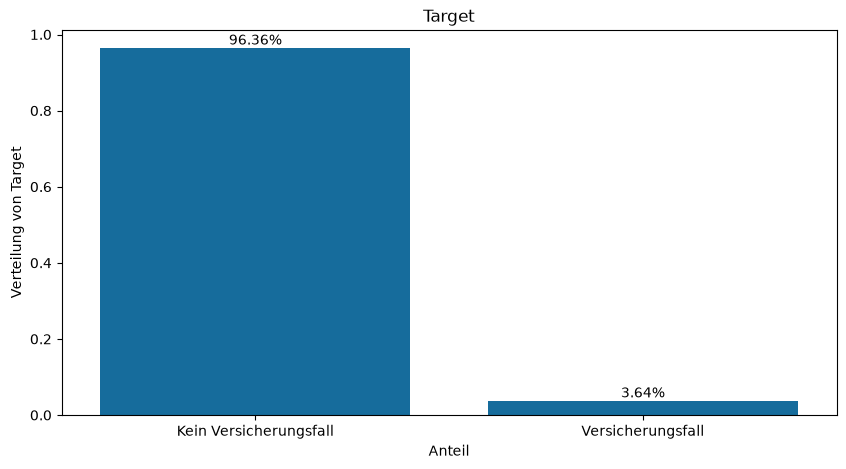

In [39]:
# Target

target_counts = df_raw["target"].value_counts(normalize=True).sort_index()
target_labels = {
    False : "Kein Versicherungsfall",
    True : "Versicherungsfall"
}
bar_labels = target_counts.index.map(target_labels)

fig, ax = plt.subplots(figsize = (10, 5))
sns.barplot(
    x=bar_labels,
    y=target_counts.values, 
    ax=ax
)
ax.set_title("Target")
ax.set_xlabel("Anteil")
ax.set_ylabel("Verteilung von Target")

for x, y in enumerate(target_counts.values):
    ax.text(x, y+0.01, f"{y:.2%}", ha="center")

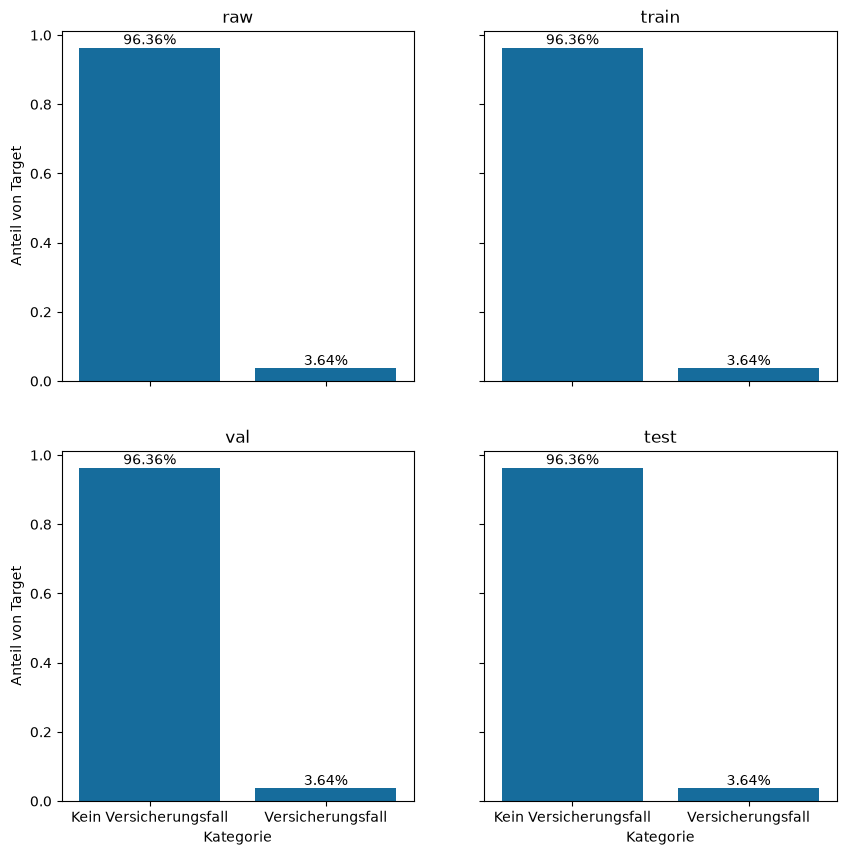

In [40]:
fig, axes = plt.subplots(2,2,figsize=(10,10), sharex=True, sharey=True)

for data_name, data, ax in zip(["raw", "train", "val", "test"], [df_raw, df_train, df_val, df_test], axes.flatten()):
    target_counts = data["target"].value_counts(normalize=True).sort_index()
    target_labels = {
        False : "Kein Versicherungsfall",
        True : "Versicherungsfall"
    }
    bar_labels = target_counts.index.map(target_labels)

    sns.barplot(
        x=bar_labels,
        y=target_counts.values, 
        ax=ax
    )
    ax.set_title(data_name)
    ax.set_xlabel("Kategorie")
    ax.set_ylabel("Anteil von Target")

    for x, y in enumerate(target_counts.values):
        ax.text(x, y+0.01, f"{y:.2%}", ha="center")

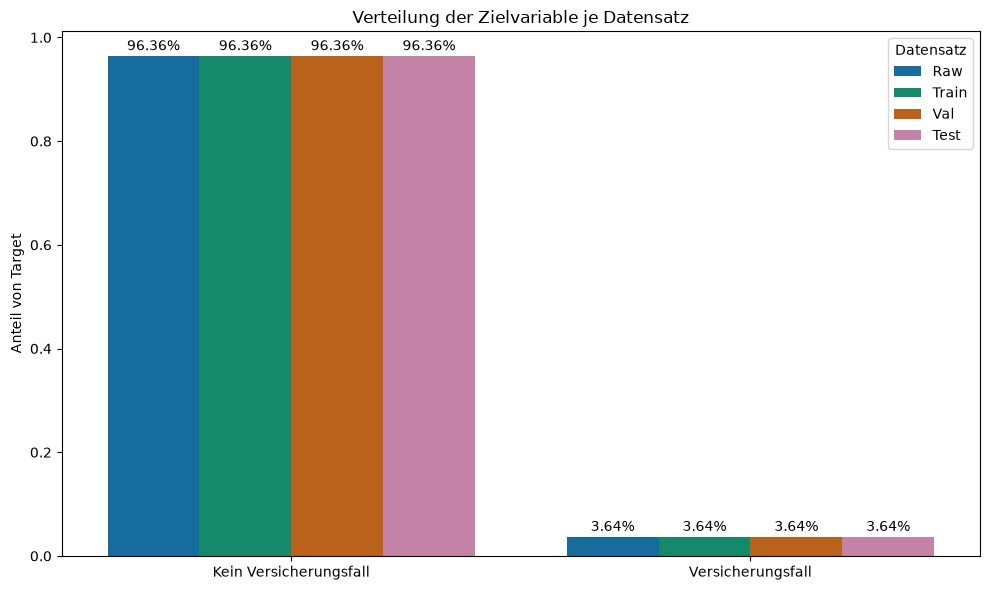

In [41]:
datasets = {
    "Raw": df_raw, 
    "Train": df_train, 
    "Val": df_val, 
    "Test": df_test
}
target_labels = {
    False : "Kein Versicherungsfall",
    True : "Versicherungsfall"
}

rows = []
for name, data in datasets.items():
    counts = data["target"].value_counts(normalize=True).sort_index()
    for value, share in counts.items():
        rows.append({"Datensatz": name, "Target": target_labels[value], "Anteil": share})

plot_df = pd.DataFrame(rows)
plot_df

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=plot_df, 
    x="Target", 
    y="Anteil", 
    hue="Datensatz", 
    ax=ax
)

ax.set_title("Verteilung der Zielvariable je Datensatz")
ax.set_xlabel("")
ax.set_ylabel("Anteil von Target")

for container in ax.containers:
    labels = [f"{v:.2%}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=2)

plt.tight_layout()

## Missing Values

In [42]:
# sanity check wegen kaggle

(df_raw[feat_cols] == -1).sum().sum()

0

(0.0, 0.7435793696195641)

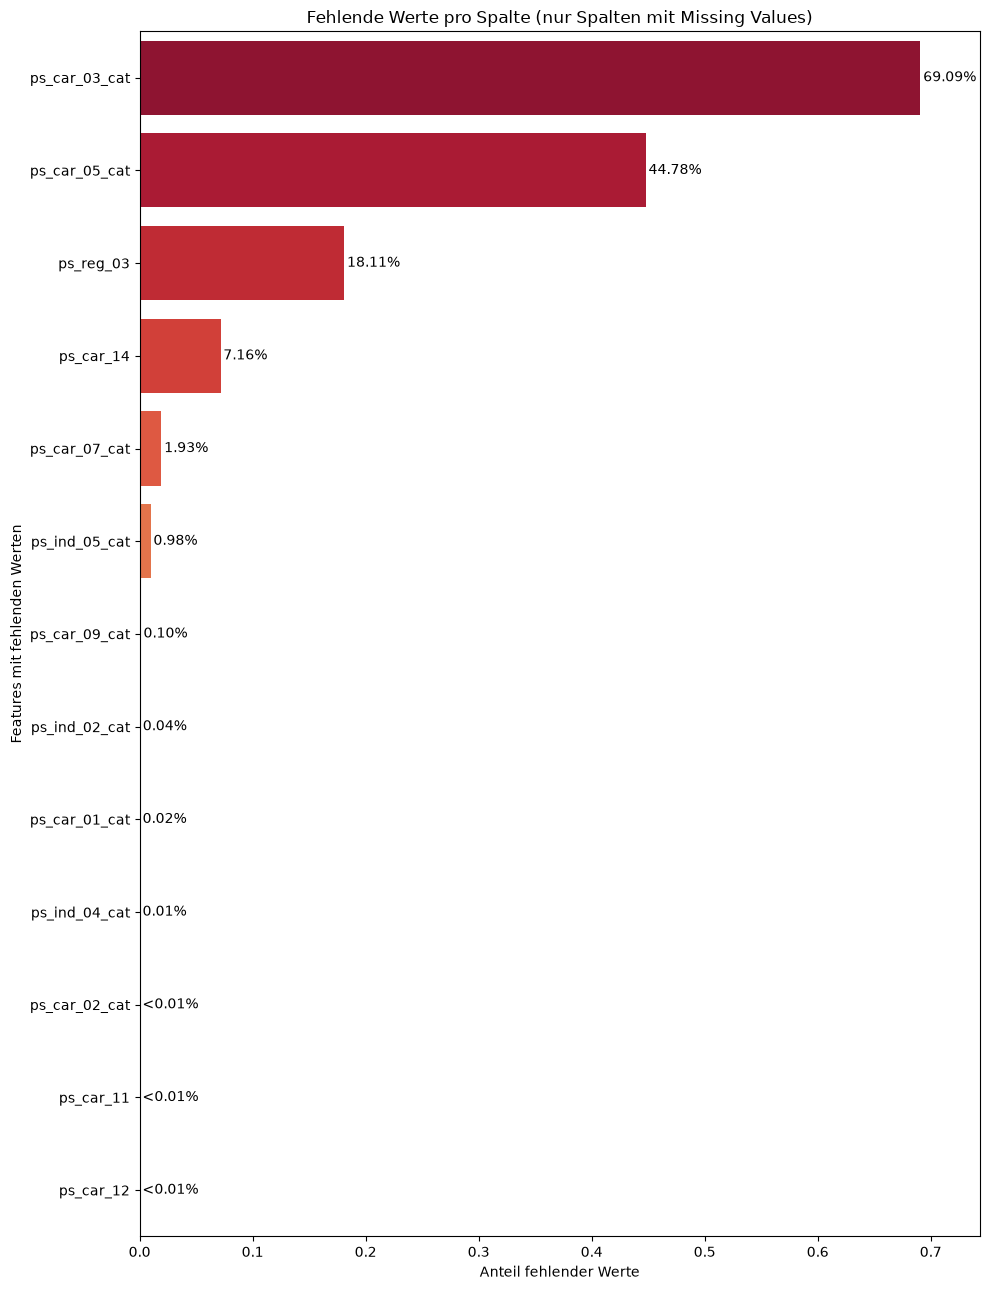

In [43]:
# MVs
miss_share = df_raw[feat_cols].isna().mean().sort_values(ascending=False)
miss_share = miss_share[miss_share > 0]
miss_count = df_raw[feat_cols].isna().sum()
miss_count = miss_count[miss_share.index]


fig, ax = plt.subplots(figsize=(10, max(3, len(miss_share))))
sns.barplot(
    x=miss_share.values, 
    y=miss_share.index, 
    ax=ax, 
    orient="h",
    palette="YlOrRd_r",
    hue=miss_share.index
)
ax.set_xlabel("Anteil fehlender Werte")
ax.set_ylabel("Features mit fehlenden Werten")
ax.set_title("Fehlende Werte pro Spalte (nur Spalten mit Missing Values)")

plt.tight_layout()

for container in ax.containers:
    labels = [f"<0.01%" if v < 0.00001 else f"{v:.2%}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=2)

x_left, x_right = ax.get_xlim()
ax.set_xlim(x_left, x_right*1.025)

(8.802864751061394e-07, 2.637232720129814)

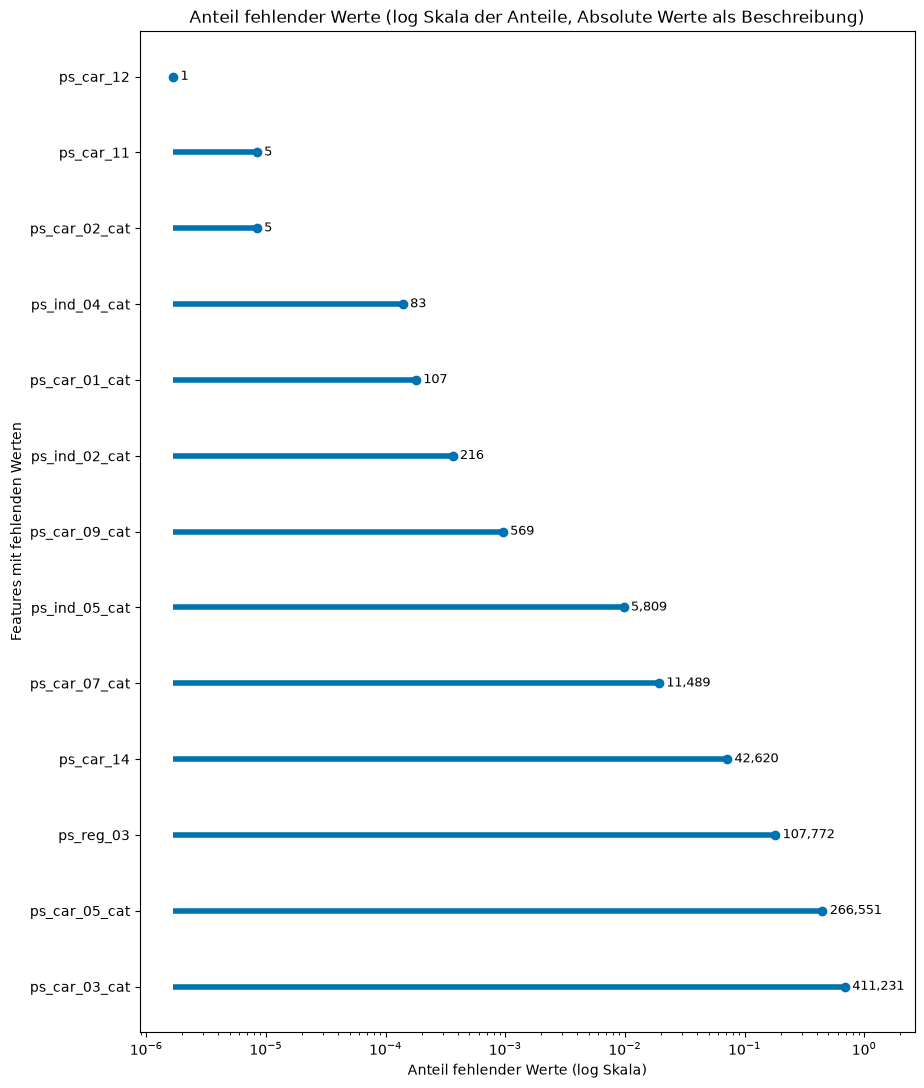

In [44]:
fig, ax = plt.subplots(figsize=(10, max(3, len(miss_share))))

ax.hlines(
    xmin=miss_share.values.min(),
    xmax=miss_share.values,
    y=miss_share.index,
    linewidth=4,
)
ax.plot(
    miss_share.values, 
    miss_share.index,
    "o"
)
ax.set_xscale("log")
ax.set_xlabel("Anteil fehlender Werte (log Skala)")
ax.set_ylabel("Features mit fehlenden Werten")
ax.set_title("Anteil fehlender Werte (log Skala der Anteile, Absolute Werte als Beschreibung)")

for share, count, label in zip(miss_share.values, miss_count.values, miss_share.index):
    ax.text(share * 1.15, label, f"{count:,}", va="center", fontsize=9)

x_left, x_right = ax.get_xlim()
ax.set_xlim(x_left, x_right*2)

In [45]:
top_miss_cols = miss_share.head(4).index

mv_target_rate_dict = {}
for cols in top_miss_cols:
    is_miss = df_raw[cols].isna()
    rate = df_raw.groupby(is_miss)["target"].mean()
    rate.index = ["vorhanden", "fehlende Werte"]
    mv_target_rate_dict[cols] = rate

mv_target_rate_df = pd.DataFrame(mv_target_rate_dict).T
mv_target_rate_df["diff"] = (mv_target_rate_df["fehlende Werte"] - mv_target_rate_df["vorhanden"]).abs()
mv_target_rate_df 

,vorhanden,fehlende Werte,diff
ps_car_03_cat,0.044809,0.032707,0.012102
ps_car_05_cat,0.040291,0.031709,0.008582
ps_reg_03,0.038228,0.028393,0.009835
ps_car_14,0.036141,0.040427,0.004286


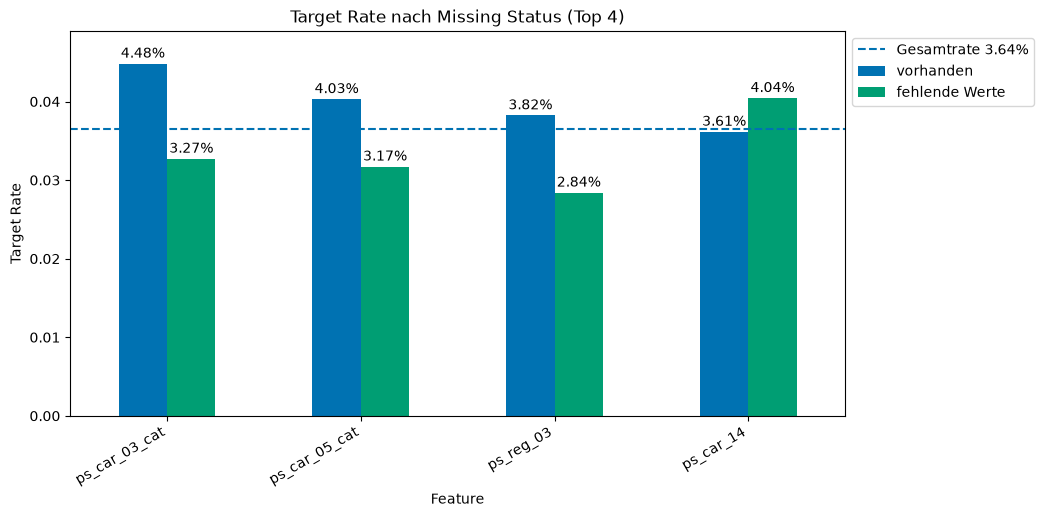

In [46]:
fig, ax = plt.subplots(figsize=(10,5))

mv_target_rate_df[["vorhanden", "fehlende Werte"]].plot(
    kind="bar",
    ax=ax
)

target_mean_rate = df_raw["target"].mean()

ax.axhline(
    target_mean_rate,
    linestyle="--",
    label=f"Gesamtrate {target_mean_rate:.2%}"
)

ax.set_title("Target Rate nach Missing Status (Top 4)")
ax.set_xlabel("Feature")
ax.set_ylabel("Target Rate")
ax.set_ylim(0, 0.049)
ax.legend(bbox_to_anchor=(1, 1))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

for container in ax.containers[:2]:
    labels = [f"{v:.2%}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=2)

In [47]:
miss_by_split = pd.DataFrame({
    "Train" : df_train[feat_cols].isna().mean(),
    "Val" : df_val[feat_cols].isna().mean(),
    "Test" : df_test[feat_cols].isna().mean()
})

miss_by_split = miss_by_split[miss_by_split.sum(axis=1) > 0]
miss_by_split["max abweichung"] = miss_by_split.max(axis=1) - miss_by_split.min(axis=1)
miss_by_split.sort_values("max abweichung", ascending=False)

,Train,Val,Test,max abweichung
ps_reg_03,0.181579,0.180135,0.177884,0.003695
ps_car_05_cat,0.447290,0.450136,0.449800,0.002846
ps_car_14,0.071410,0.073519,0.071251,0.002268
ps_car_03_cat,0.690928,0.689678,0.691879,0.002201
ps_car_07_cat,0.019304,0.019774,0.018817,0.000958
ps_ind_05_cat,0.009707,0.010265,0.009677,0.000588
ps_car_09_cat,0.000930,0.001126,0.000991,0.000195
ps_ind_04_cat,0.000128,0.000202,0.000168,0.000074
ps_ind_02_cat,0.000357,0.000403,0.000370,0.000046
ps_car_02_cat,0.000008,0.000000,0.000017,0.000017


## Category Features

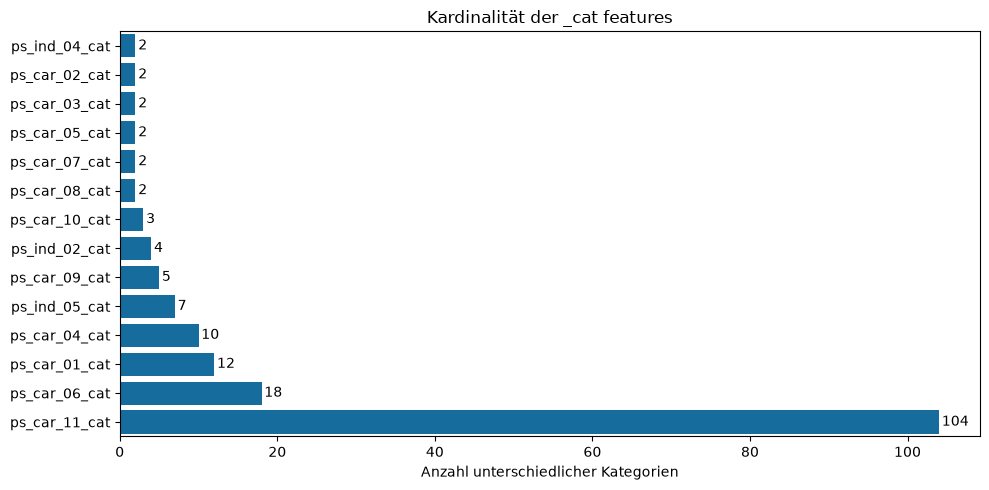

In [48]:
kardinal = df_raw[cat_cols].nunique().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x=kardinal.values,
    y=kardinal.index,
    ax=ax,
    orient="h"
)
ax.set_title("Kardinalität der _cat features")
ax.set_xlabel("Anzahl unterschiedlicher Kategorien")
ax.set_ylabel("")
plt.tight_layout()

for container in ax.containers:
    labels = [f"{v.astype(int)}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=2)

In [49]:
df_raw["ps_car_11_cat"].value_counts(ascending=False)

ps_car_11_cat
104    85083
103    24262
64     22278
87     17106
32     12578
       ...  
58      1464
81      1433
56      1272
18      1233
63      1103
Name: count, Length: 104, dtype: int64

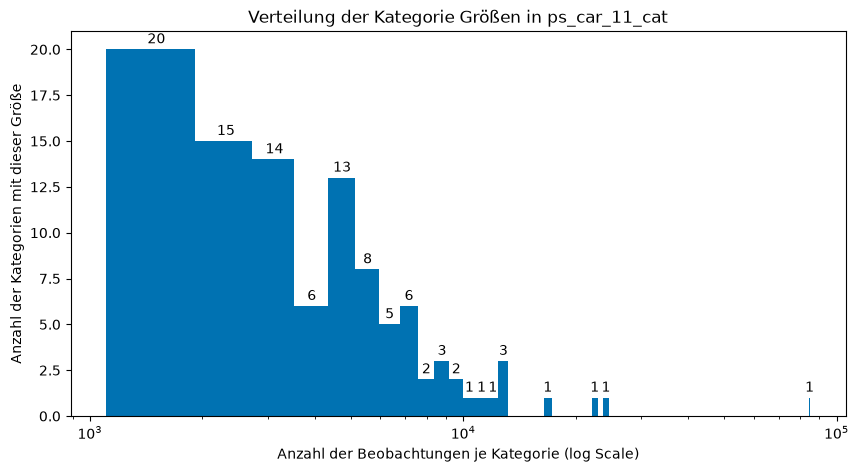

In [50]:
cat_sizes = df_raw["ps_car_11_cat"].value_counts()

fig, ax = plt.subplots(figsize=(10,5))

cat_sizes.plot(
    kind="hist",
    bins=104,
    ax=ax,
    logx=True
)
ax.set_title("Verteilung der Kategorie Größen in ps_car_11_cat")
ax.set_xlabel("Anzahl der Beobachtungen je Kategorie (log Scale)")
ax.set_ylabel("Anzahl der Kategorien mit dieser Größe")

for container in ax.containers:
    labels = ['' if v < 1 else f"{v.astype(int)}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=2)

Text(0, 0.5, '')

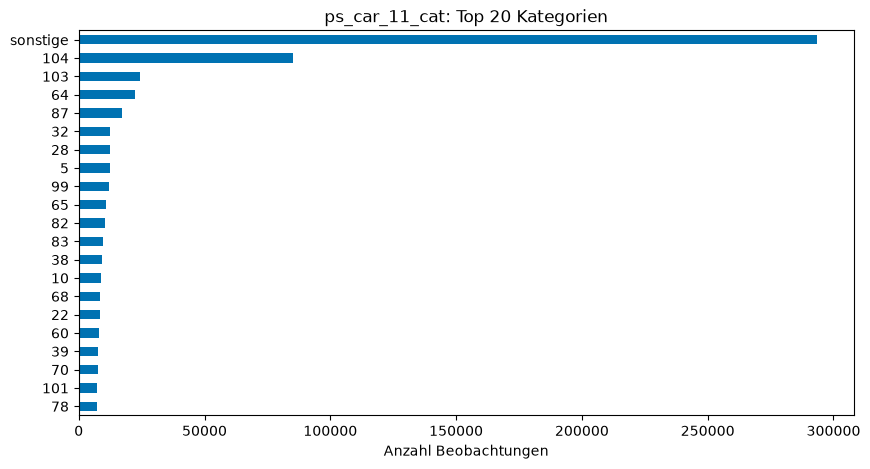

In [51]:
top_n = 20
counts_n = df_raw["ps_car_11_cat"].value_counts()
top = counts_n.head(top_n)
top["sonstige"] = counts_n.iloc[top_n:].sum()

fig, ax = plt.subplots(figsize=(10, 5))

top.sort_values().plot(
    kind="barh",
    ax=ax
)
ax.set_title(f"ps_car_11_cat: Top {top_n} Kategorien")
ax.set_xlabel("Anzahl Beobachtungen")
ax.set_ylabel("")

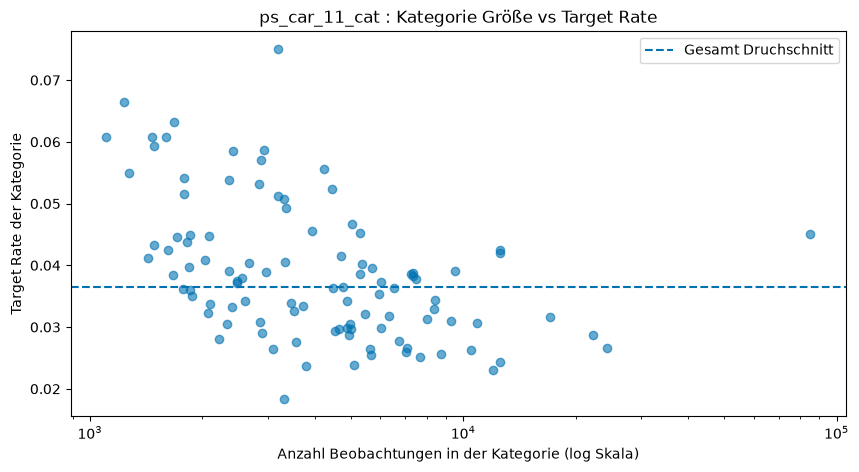

In [52]:
stats_kard = (
    df_raw.groupby("ps_car_11_cat", observed=True)["target"]
    .agg(["mean", "count"])
)

fig, ax = plt.subplots(figsize=(10,5))

ax.scatter(
    stats_kard["count"], 
    stats_kard["mean"],
      alpha=0.6
)
ax.set_xscale("log")
ax.axhline(
    df_raw["target"].mean(),
    linestyle="--",
    label="Gesamt Druchschnitt"
)
ax.set_title("ps_car_11_cat : Kategorie Größe vs Target Rate")
ax.set_xlabel("Anzahl Beobachtungen in der Kategorie (log Skala)")
ax.set_ylabel("Target Rate der Kategorie")
ax.legend()

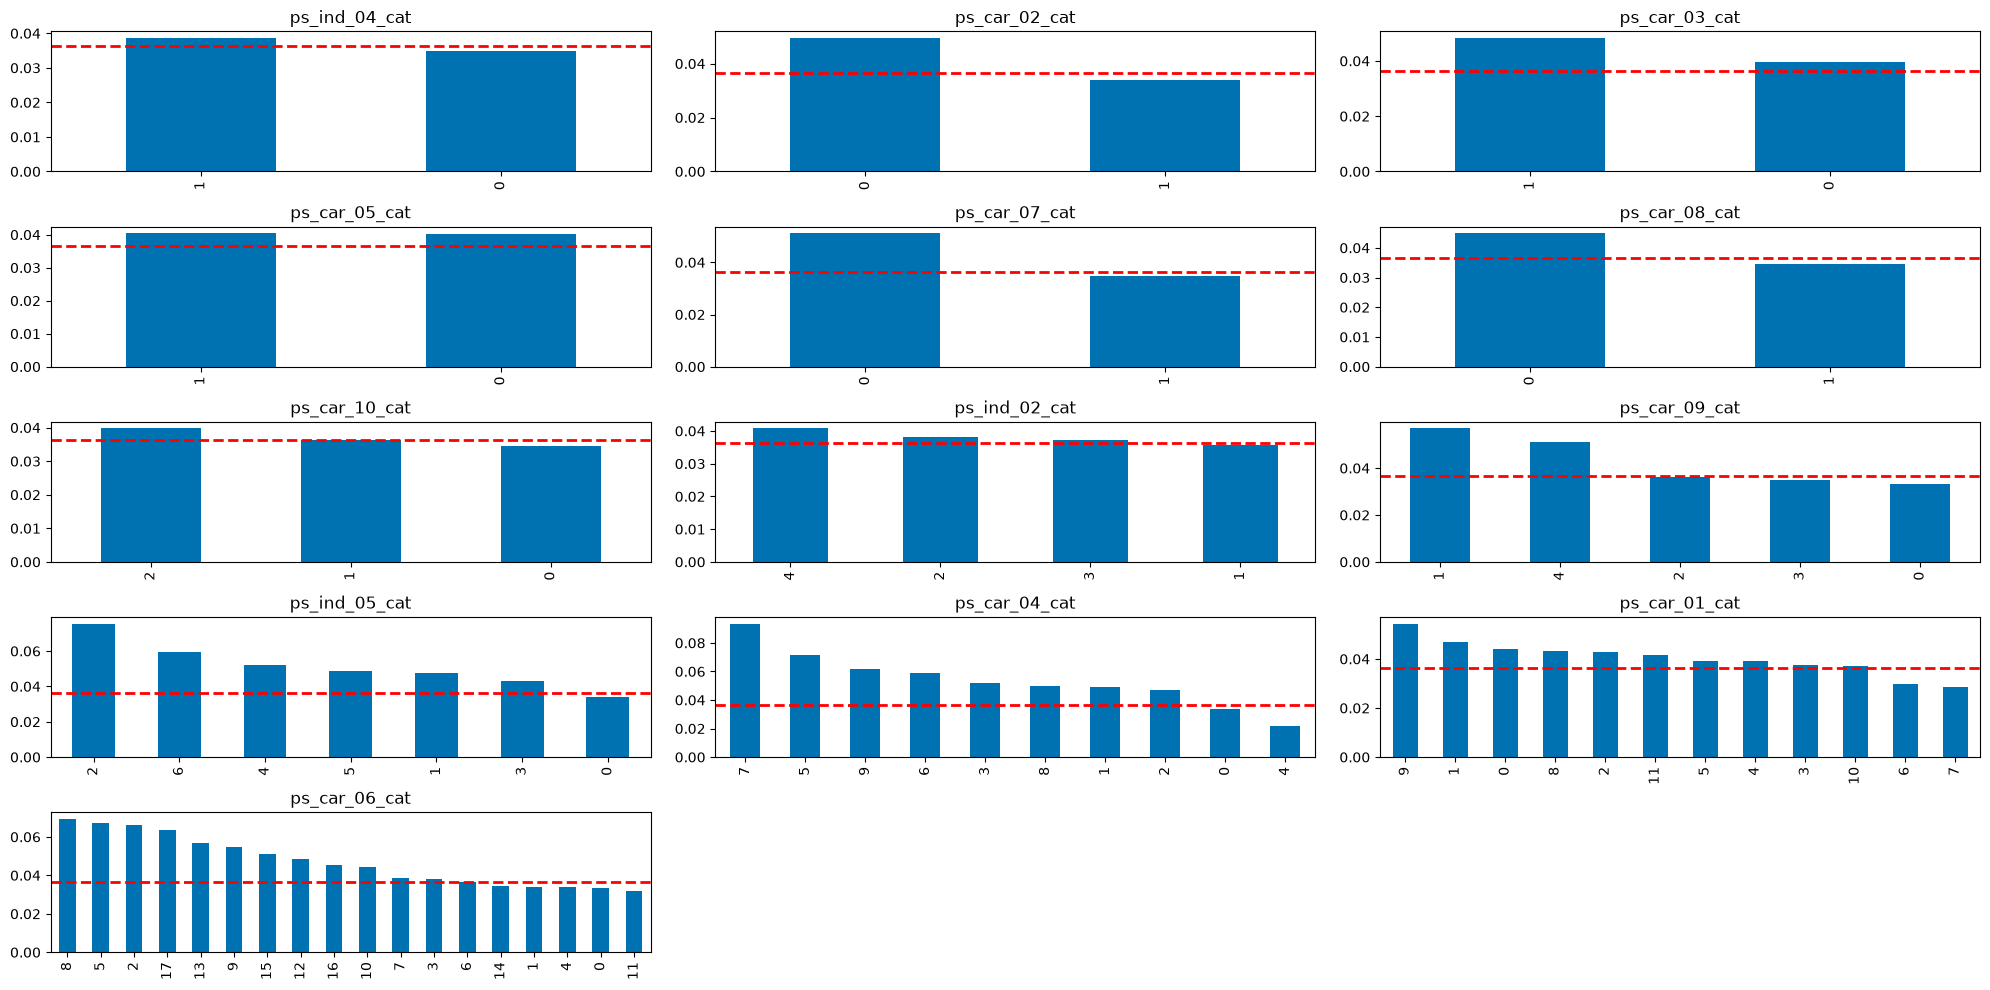

In [53]:
high_kard_thresh = 18
low_kard_cols = kardinal[kardinal <= high_kard_thresh].index
high_kard_cols = kardinal[kardinal > high_kard_thresh].index

kard_cols_grid = 3
kard_rows_grid = int(np.ceil(len(low_kard_cols) / kard_cols_grid))

fig, axes = plt.subplots(kard_rows_grid, kard_cols_grid, figsize=(20,10))

achsen = axes.flatten()
overall_rate = df_raw["target"].mean()

for idx, cols in enumerate(low_kard_cols):
    rates = (
        df_raw
        .groupby(cols, observed=True)["target"]
        .mean()
        .sort_values(ascending=False)
    )
    rates.plot(
        kind="bar",
        ax=achsen[idx]
    )
    achsen[idx].axhline(
        overall_rate,
        linestyle="--",
        linewidth=2,
        color="red"
    )
    achsen[idx].set_title(cols)
    achsen[idx].set_xlabel("")
    achsen[idx].set_ylabel("")
    achsen[idx].tick_params(axis="x")

for n in range(len(low_kard_cols), len(achsen)):
    achsen[n].axis("off")

plt.tight_layout()


## Binäre Features

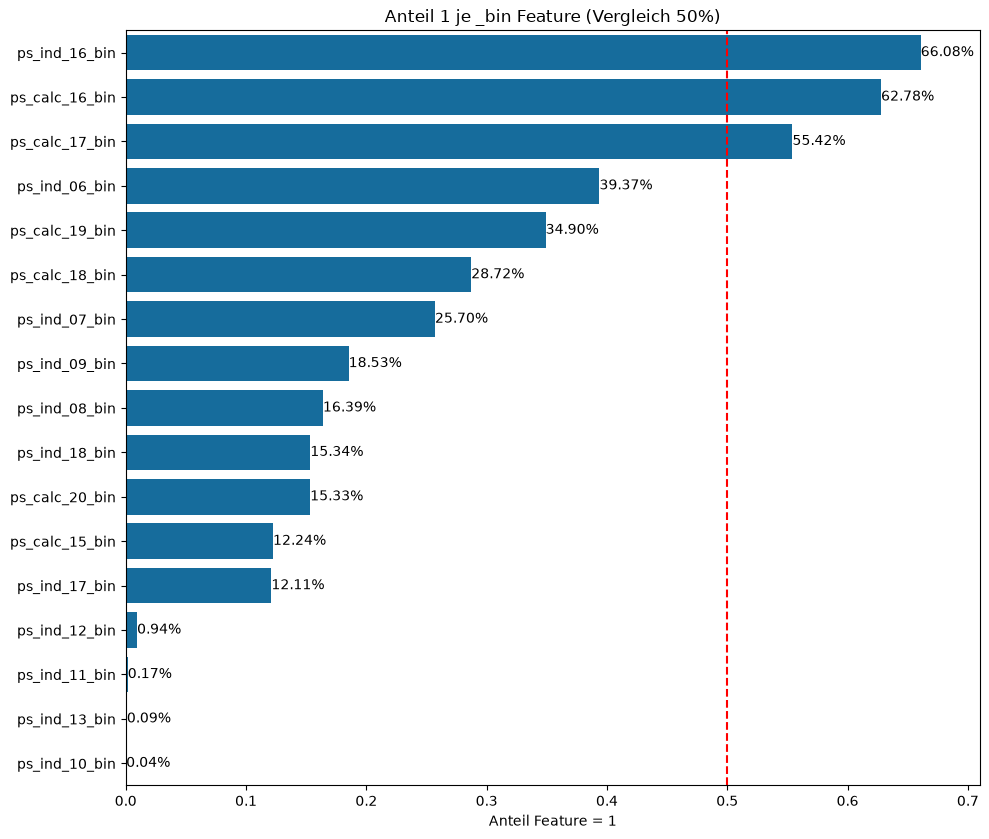

In [54]:
bin_one_share = df_raw[bin_cols].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(3, 0.5* len(bin_one_share))))

sns.barplot(
    x=bin_one_share.values,
    y=bin_one_share.index,
    ax=ax,
    orient="h",
)
ax.axvline(
    0.5, 
    color="red", 
    linestyle="--"
)
ax.set_title("Anteil 1 je _bin Feature (Vergleich 50%)")
ax.set_xlabel("Anteil Feature = 1")
ax.set_ylabel("")
ax.set_xlim(0, 0.71)

for container in ax.containers:
    labels = ["<0.01%" if v < 0.0001 else f"{v:.2%}" for v in container.datavalues]
    ax.bar_label(container, labels=labels)

plt.tight_layout()

In [55]:
bin_target_rate = pd.DataFrame({
    cols : df_raw.groupby(cols, observed=True)["target"].mean() for cols in bin_cols
}).T
bin_target_rate.columns = ["target_rate_bei_0", "target_rate_bei_1"]
bin_target_rate["diff"] = (
    bin_target_rate["target_rate_bei_1"] - bin_target_rate["target_rate_bei_0"]
).abs()

bin_target_rate.sort_values("diff", ascending=False)

,target_rate_bei_0,target_rate_bei_1,diff
ps_ind_17_bin,0.033870,0.055155,0.021285
ps_ind_10_bin,0.036441,0.054054,0.017613
ps_ind_12_bin,0.036305,0.051442,0.015137
ps_ind_13_bin,0.036433,0.051418,0.014985
ps_ind_07_bin,0.032676,0.047350,0.014674
ps_ind_06_bin,0.041585,0.028537,0.013048
ps_ind_16_bin,0.043714,0.032718,0.010996
ps_ind_11_bin,0.036432,0.045680,0.009248
ps_ind_08_bin,0.035357,0.042012,0.006655
ps_ind_09_bin,0.037184,0.033211,0.003973


In [56]:
def signi(row, p_all, n_tot):
    """Signifikanztest für Anteilswerte, in abhängigkeit von der Gruppenverteilung, ist die differenz durch zufall erklärbar?"""
    share_minor = min(row["anteil_1"], 1 -row["anteil_1"])
    n_minor = n_tot * share_minor
    ste = np.sqrt(p_all * (1 - p_all) / n_minor)
    return row["diff"] > 1.96 * ste

bin_target_rate["anteil_1"] = df_raw[bin_cols].mean()
bin_target_rate["sign"] = bin_target_rate.apply(
    lambda row : signi(row=row, p_all=df_raw["target"].mean(), n_tot=len(df_raw)), axis=1
)
bin_target_rate.sort_values("diff", ascending=False)

,target_rate_bei_0,target_rate_bei_1,diff,anteil_1,sign
ps_ind_17_bin,0.033870,0.055155,0.021285,0.121081,True
ps_ind_10_bin,0.036441,0.054054,0.017613,0.000373,False
ps_ind_12_bin,0.036305,0.051442,0.015137,0.009439,True
ps_ind_13_bin,0.036433,0.051418,0.014985,0.000948,False
ps_ind_07_bin,0.032676,0.047350,0.014674,0.257033,True
ps_ind_06_bin,0.041585,0.028537,0.013048,0.393742,True
ps_ind_16_bin,0.043714,0.032718,0.010996,0.660823,True
ps_ind_11_bin,0.036432,0.045680,0.009248,0.001692,False
ps_ind_08_bin,0.035357,0.042012,0.006655,0.163921,True
ps_ind_09_bin,0.037184,0.033211,0.003973,0.185304,True


Text(0.5, 1.0, 'Korrelation zwischen bin Features')

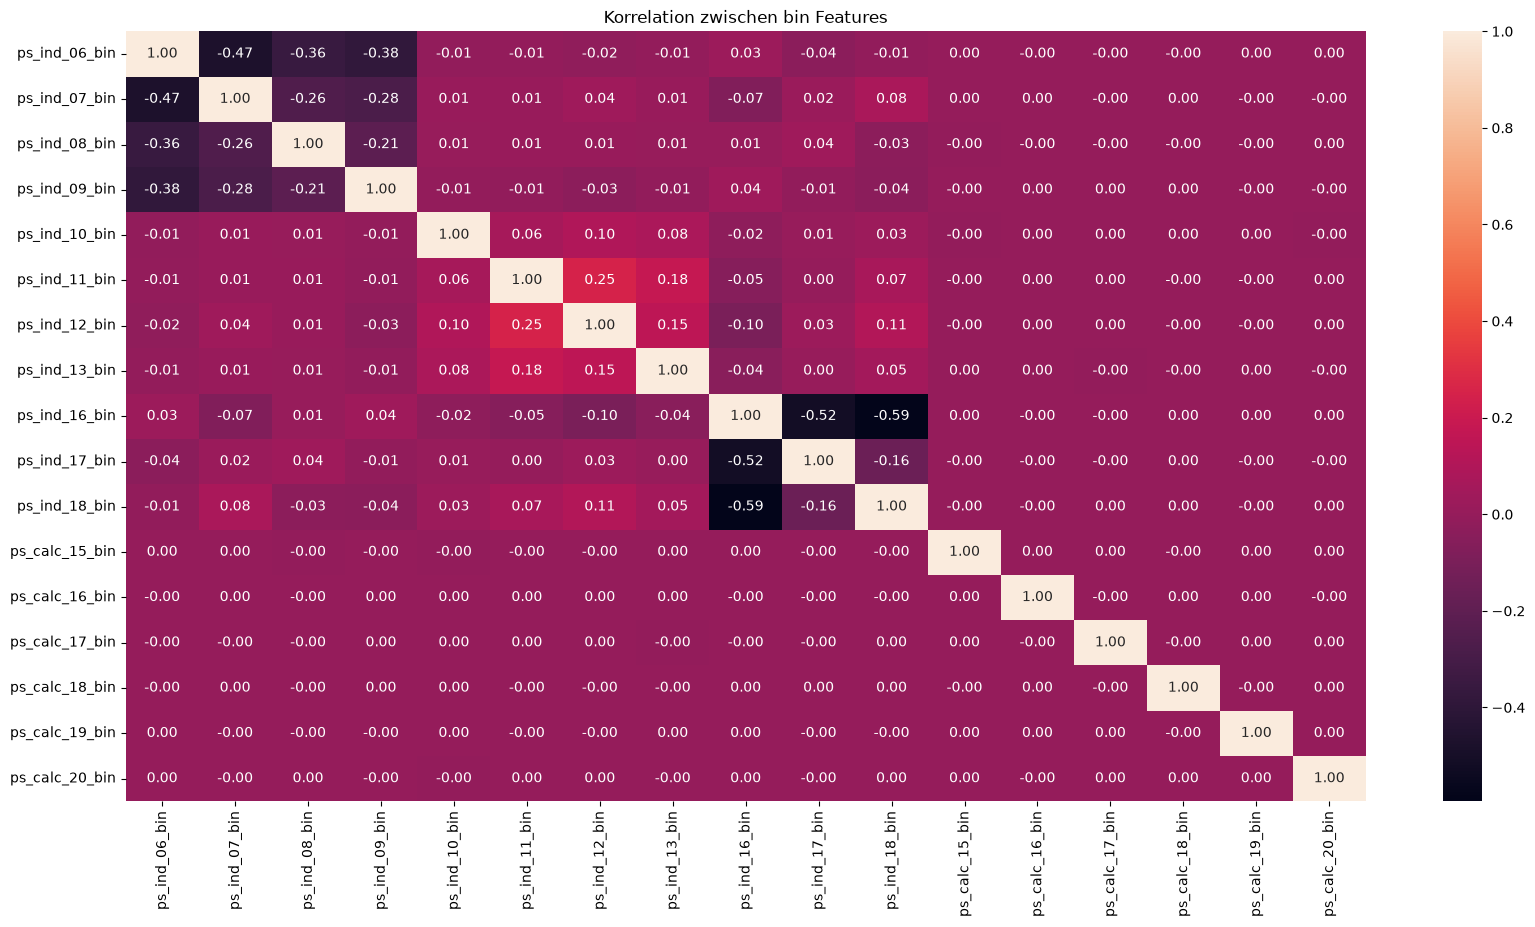

In [57]:
fig, ax = plt.subplots(figsize=(20,10))

sns.heatmap(
    df_raw[bin_cols].astype(float).corr(),
    ax=ax,
    annot=True,
    fmt=".2f"
)
ax.set_title("Korrelation zwischen bin Features")

## Continous Features

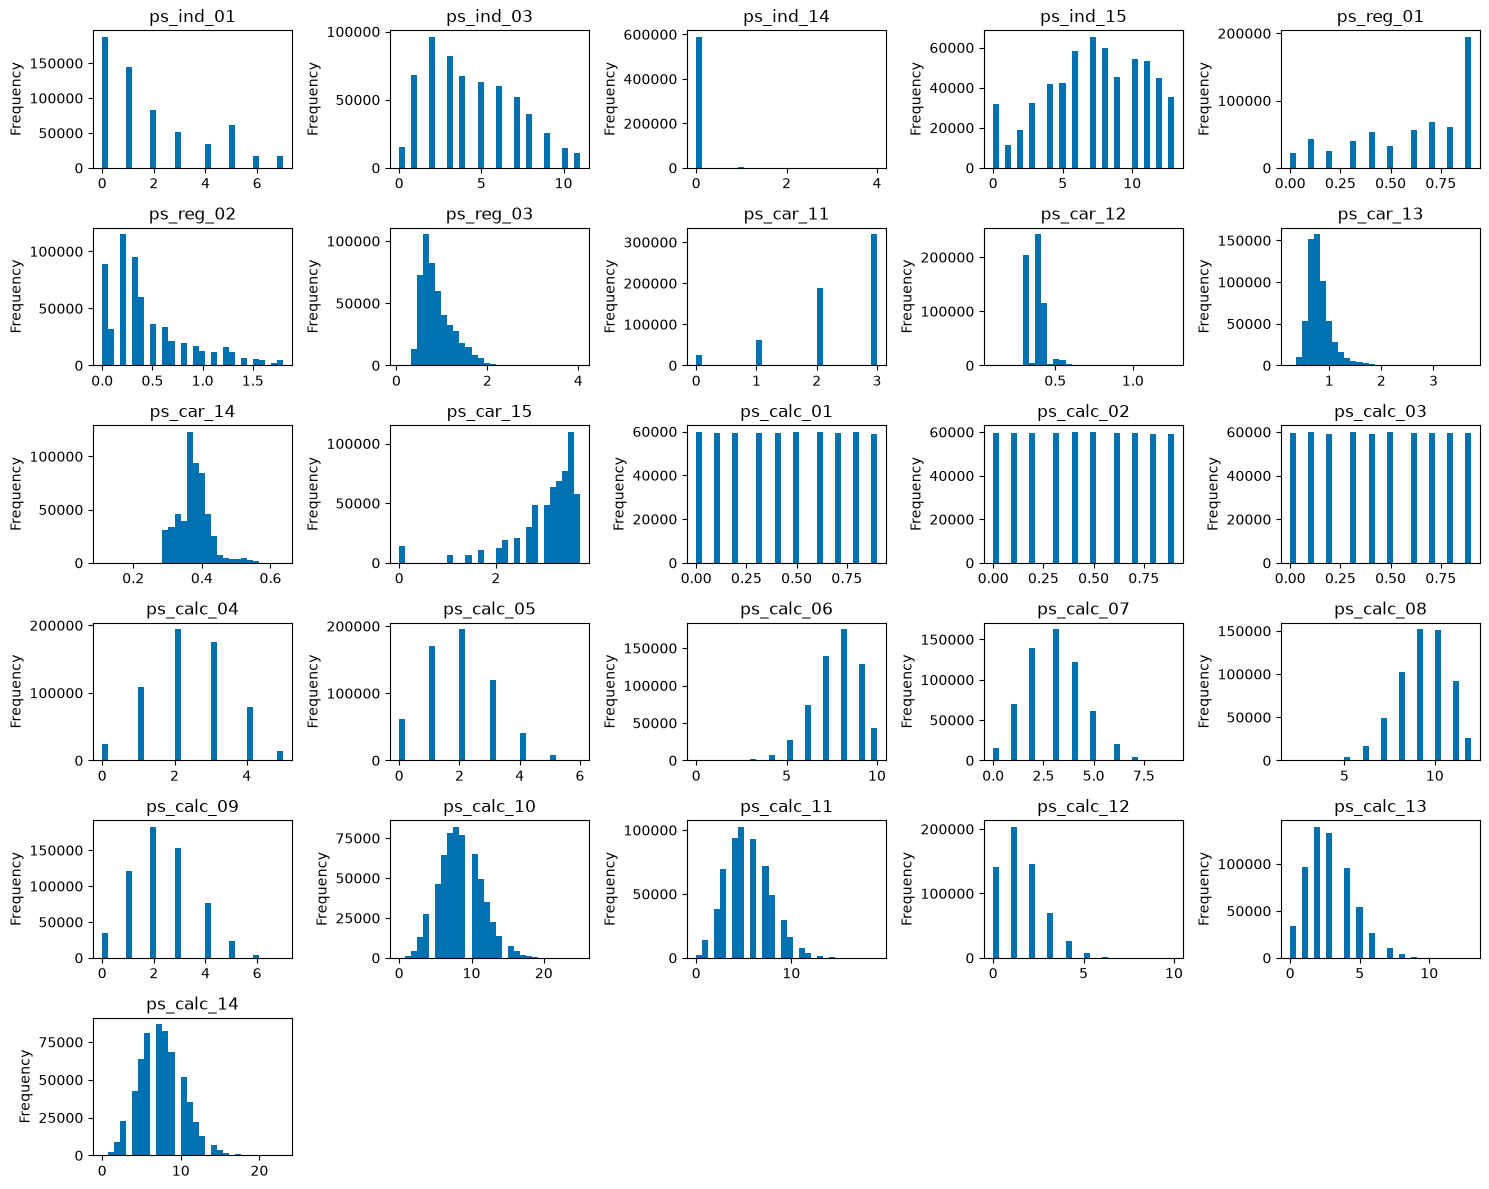

In [58]:
num_cols_grid = 5
num_rows_grid = int(np.ceil(len(num_cols) / num_cols_grid))

fig, axes = plt.subplots(num_rows_grid, num_cols_grid, figsize=(3*num_cols_grid, 2*num_rows_grid))

achsen = axes.flatten()

for idx, cols in enumerate(num_cols):
    df_raw[cols].dropna().plot(
        kind="hist",
        bins=30,
        ax=achsen[idx]
    )
    achsen[idx].set_title(cols)

for n in range(len(num_cols), len(achsen)):
    achsen[n].axis("off")

plt.tight_layout()


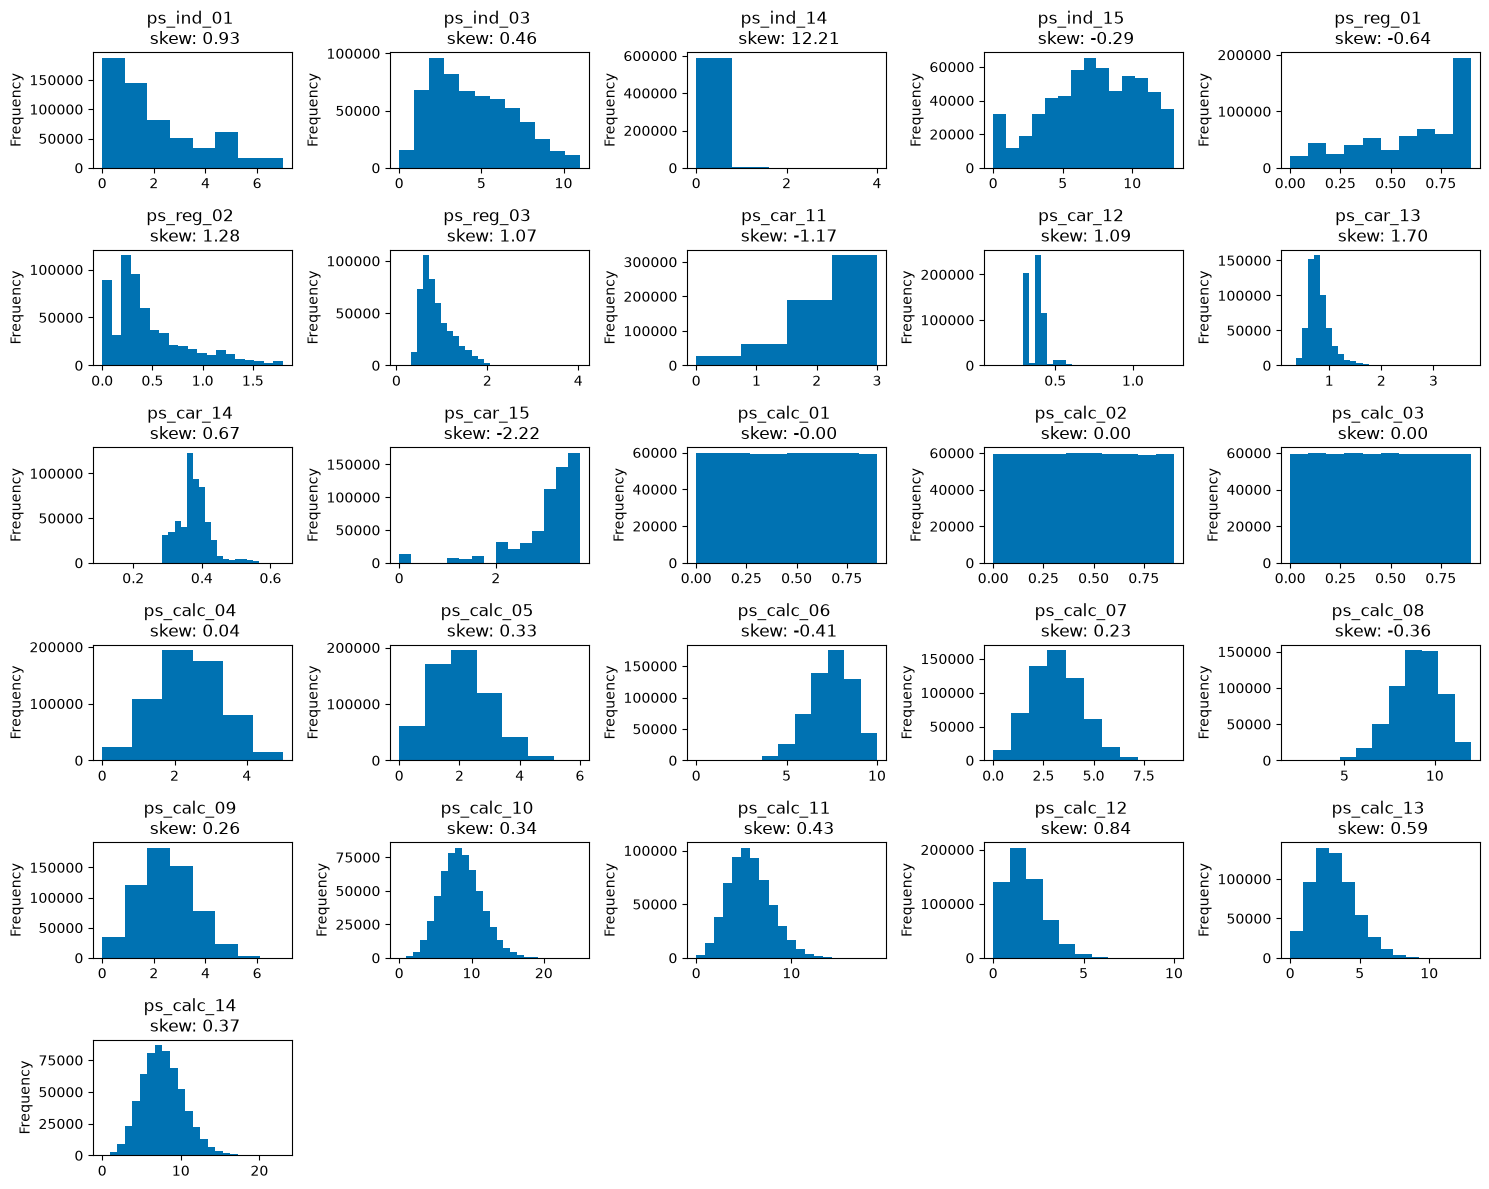

In [59]:
num_cols_grid = 5
num_rows_grid = int(np.ceil(len(num_cols) / num_cols_grid))

fig, axes = plt.subplots(num_rows_grid, num_cols_grid, figsize=(3*num_cols_grid, 2*num_rows_grid))

achsen = axes.flatten()

for idx, cols in enumerate(num_cols):
    data = df_raw[cols].dropna()
    data_unique = data.nunique()
    data_bins = data_unique if data_unique <= 30 else 30

    data.plot(
        kind="hist",
        bins=data_bins,
        ax=achsen[idx]
    )
    data_skew = data.skew()
    achsen[idx].set_title(f"{cols} \n skew: {data_skew:.2f}")
    achsen[idx].tick_params()

for n in range(len(num_cols), len(achsen)):
    achsen[n].axis("off")

plt.tight_layout()


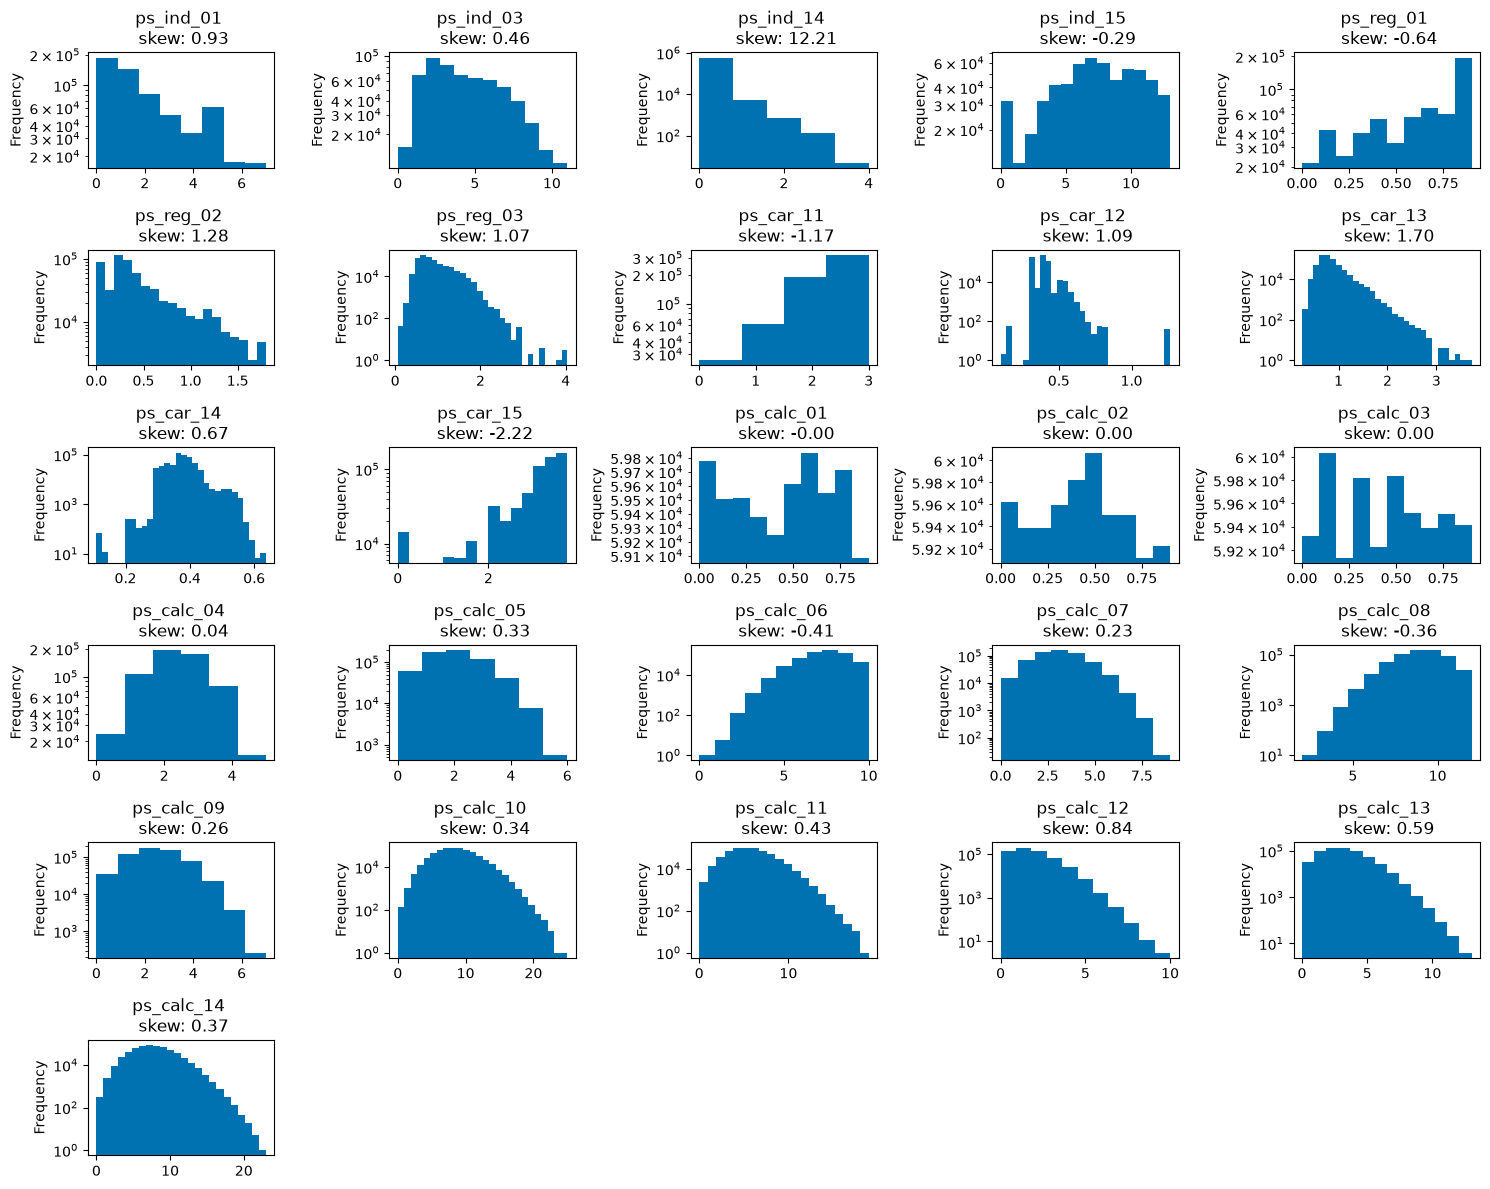

In [60]:
num_cols_grid = 5
num_rows_grid = int(np.ceil(len(num_cols) / num_cols_grid))

fig, axes = plt.subplots(num_rows_grid, num_cols_grid, figsize=(3*num_cols_grid, 2*num_rows_grid))

achsen = axes.flatten()

for idx, cols in enumerate(num_cols):
    data = df_raw[cols].dropna()
    data_unique = data.nunique()
    data_bins = data_unique if data_unique <= 30 else 30

    data.plot(
        kind="hist",
        bins=data_bins,
        ax=achsen[idx],
        log=True
    )
    data_skew = data.skew()
    achsen[idx].set_title(f"{cols} \n skew: {data_skew:.2f}")
    achsen[idx].tick_params()

for n in range(len(num_cols), len(achsen)):
    achsen[n].axis("off")

plt.tight_layout()


In [61]:
df_raw[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T.round(3)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ps_ind_01,595212.0,1.900,1.984,0.000,0.000,0.000,0.000,1.000,3.000,6.000,7.000,7.000
ps_ind_03,595212.0,4.423,2.700,0.000,0.000,1.000,2.000,4.000,6.000,9.000,11.000,11.000
ps_ind_14,595212.0,0.012,0.128,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,4.000
ps_ind_15,595212.0,7.300,3.546,0.000,0.000,0.000,5.000,7.000,10.000,13.000,13.000,13.000
ps_reg_01,595212.0,0.611,0.288,0.000,0.000,0.100,0.400,0.700,0.900,0.900,0.900,0.900
ps_reg_02,595212.0,0.439,0.404,0.000,0.000,0.000,0.200,0.300,0.600,1.300,1.700,1.800
ps_reg_03,487440.0,0.894,0.345,0.061,0.410,0.492,0.633,0.802,1.084,1.584,1.881,4.038
ps_car_11,595207.0,2.346,0.832,0.000,0.000,1.000,2.000,3.000,3.000,3.000,3.000,3.000
ps_car_12,595211.0,0.380,0.058,0.100,0.316,0.316,0.316,0.374,0.400,0.469,0.566,1.265
ps_car_13,595212.0,0.813,0.225,0.251,0.448,0.543,0.671,0.766,0.906,1.236,1.618,3.721


In [62]:
# nicht interpretierte outlier

def count_outlier(series):
    "außreißer count zurünk geben (außerhalb q1 und q3)"
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_thresh = q1 - 1.5 * iqr
    upper_thresh = q3 + 1.5 * iqr
    return ((series < lower_thresh) | (series > upper_thresh)).sum()

outlier_counts = df_raw[num_cols].apply(count_outlier)

outlier_summary = pd.DataFrame({
    "anzahl_ausreißer": outlier_counts,
    "anteil": outlier_counts / len(df_raw)
})

outlier_summary.sort_values("anzahl_ausreißer", ascending=False)

,anzahl_ausreißer,anteil
ps_calc_04,38105,0.064019
ps_reg_02,36793,0.061815
ps_calc_12,35259,0.059238
ps_car_15,27409,0.046049
ps_car_13,26913,0.045216
ps_car_11,25983,0.043653
ps_car_14,18770,0.031535
ps_calc_14,16086,0.027026
ps_car_12,15355,0.025798
ps_reg_03,10562,0.017745


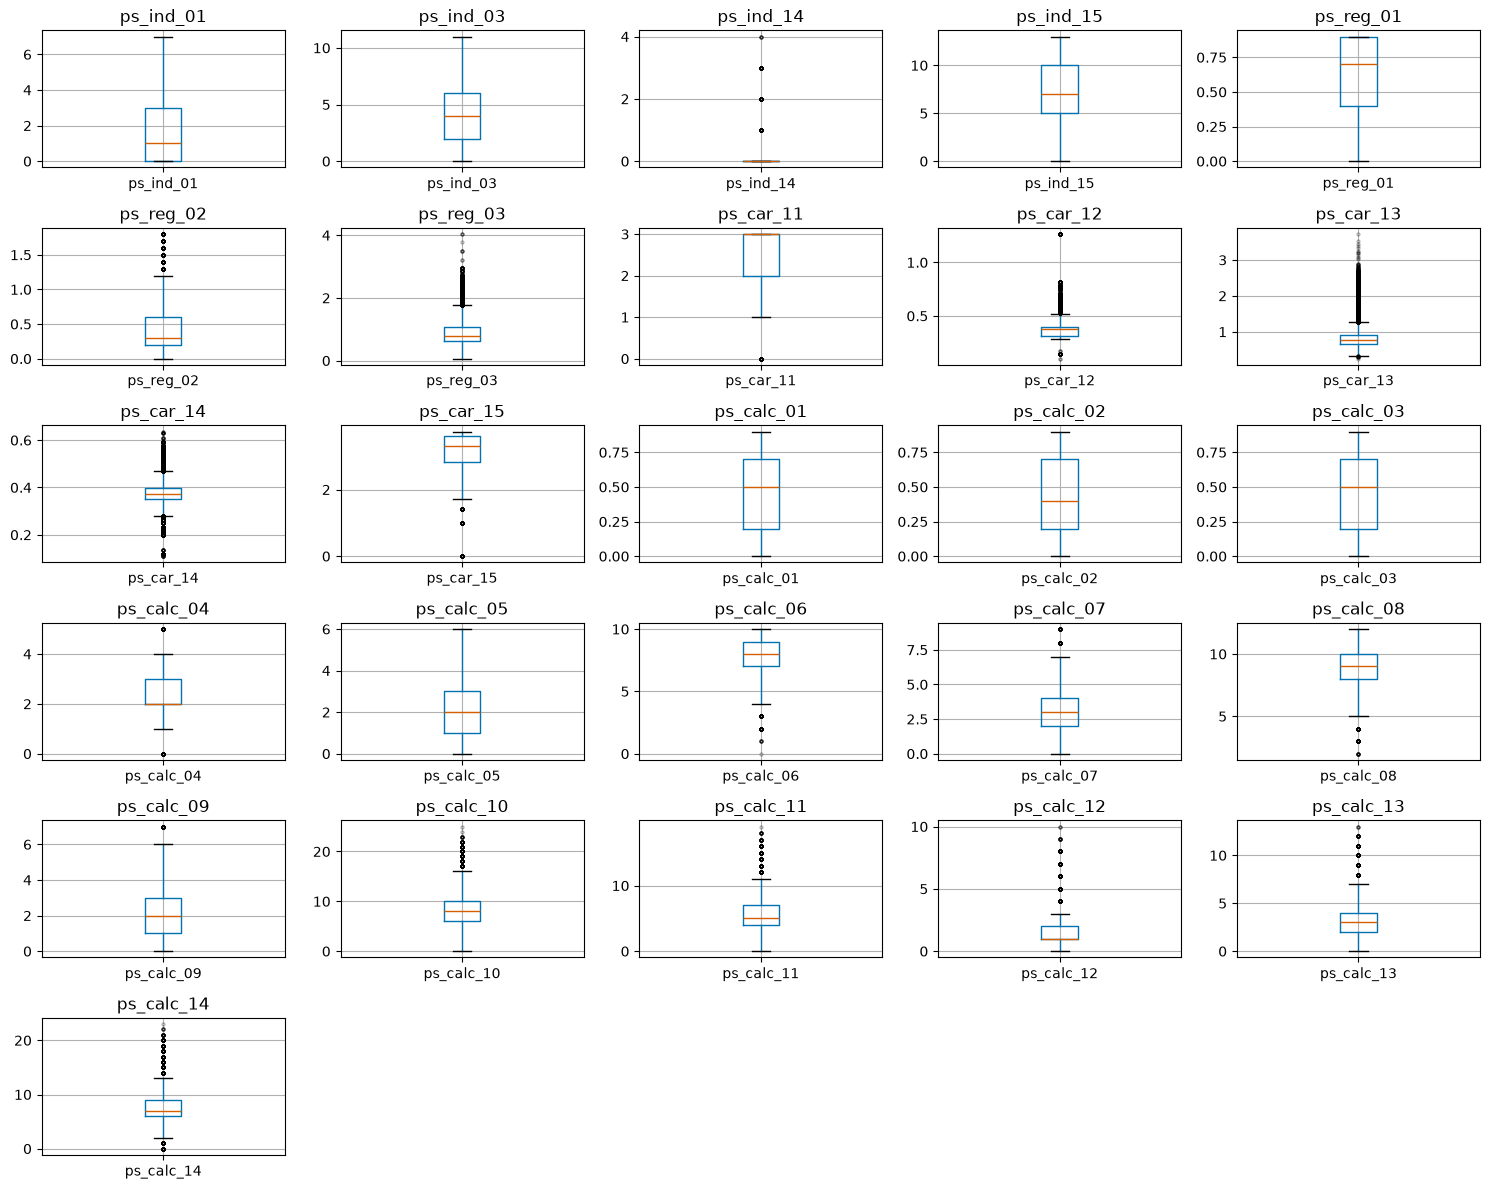

In [63]:
fig, axes = plt.subplots(num_rows_grid, num_cols_grid, figsize=(3*num_cols_grid, 2*num_rows_grid))

achsen = axes.flatten()

for idx, cols in enumerate(num_cols):
    df_raw.boxplot(
        column=cols,
        ax=achsen[idx],
        flierprops=dict(
            marker="o",
            markersize=2,
            alpha=0.3,
        )
    )
    achsen[idx].set_title(cols)
    achsen[idx].set_xlabel("")

for n in range(len(num_cols), len(achsen)):
    achsen[n].axis("off")

plt.tight_layout()

ps_car_13     0.053899
ps_car_12     0.038800
ps_reg_02     0.034800
ps_reg_03     0.033758
ps_car_15     0.027667
ps_reg_01     0.022888
ps_ind_15    -0.021506
ps_ind_01     0.018570
ps_car_14     0.011674
ps_ind_03     0.008360
ps_ind_14     0.007443
ps_calc_03    0.001907
ps_calc_01    0.001782
ps_calc_14    0.001362
ps_calc_02    0.001360
ps_car_11    -0.001220
ps_calc_12   -0.001133
ps_calc_10    0.001061
ps_calc_08   -0.001006
ps_calc_05    0.000771
ps_calc_09    0.000719
ps_calc_13   -0.000446
ps_calc_11    0.000371
ps_calc_07   -0.000103
ps_calc_06    0.000082
ps_calc_04    0.000033
Name: target, dtype: float64


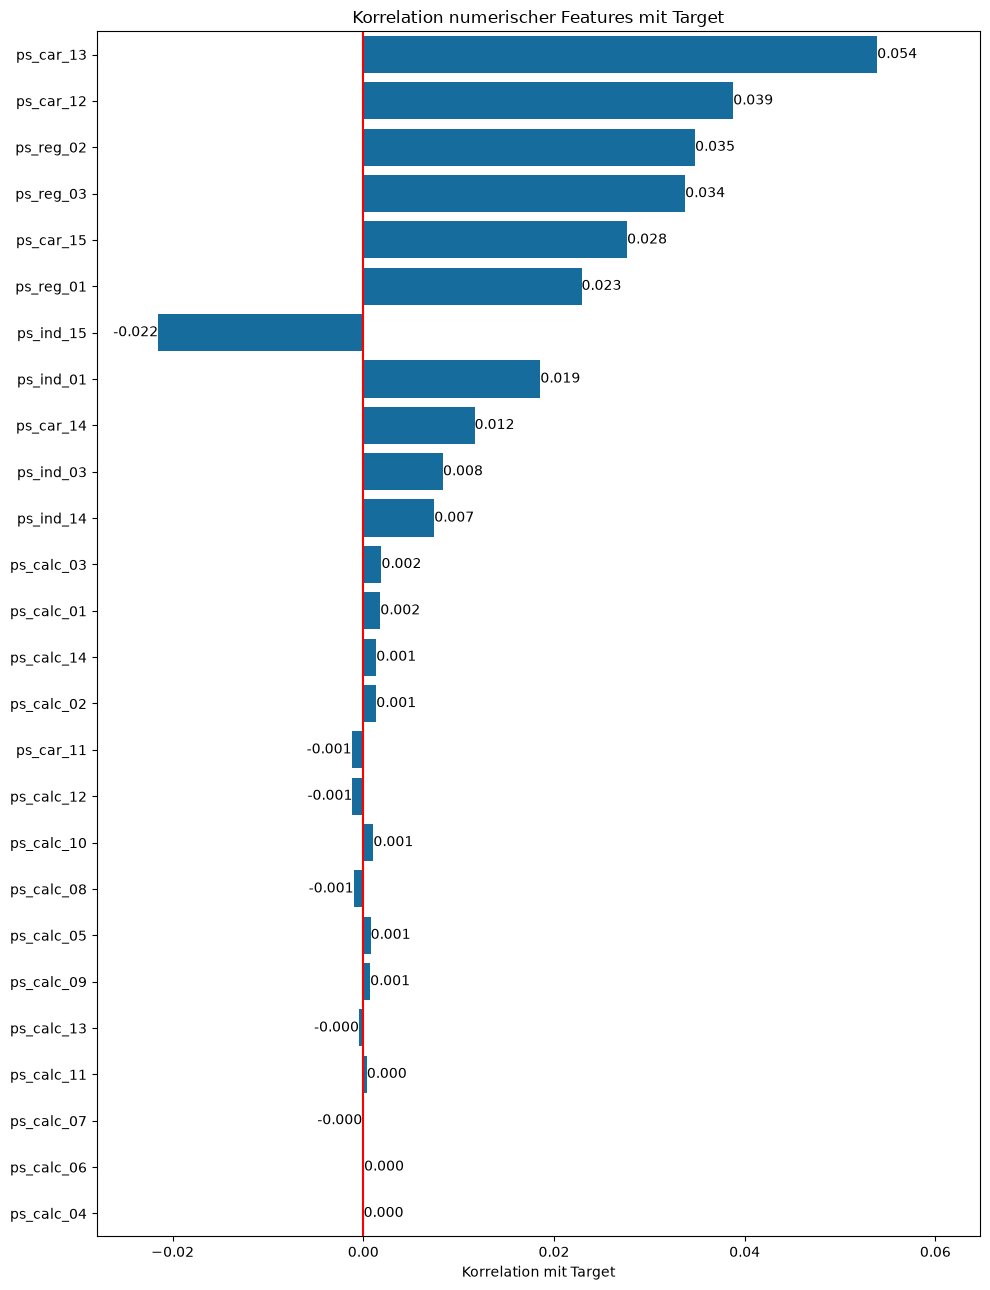

In [64]:
corr_num_target = (
    df_raw[num_cols]
    .assign(target=df_raw["target"].astype(float))
    .corr()["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, max(3, 0.5*len(corr_num_target))))

sns.barplot(
    x=corr_num_target.values,
    y=corr_num_target.index,
    ax=ax,
    orient="h"
)
ax.axvline(0, color="red")
ax.set_title("Korrelation numerischer Features mit Target")
ax.set_xlabel("Korrelation mit Target")
ax.set_ylabel("")
ax.set_xlim(min(corr_num_target)*1.3, max(corr_num_target)*1.2)

for container in ax.containers:
    labels = [f"{v:.3f}" for v in container.datavalues]
    ax.bar_label(container, labels=labels)

plt.tight_layout()

print(corr_num_target)

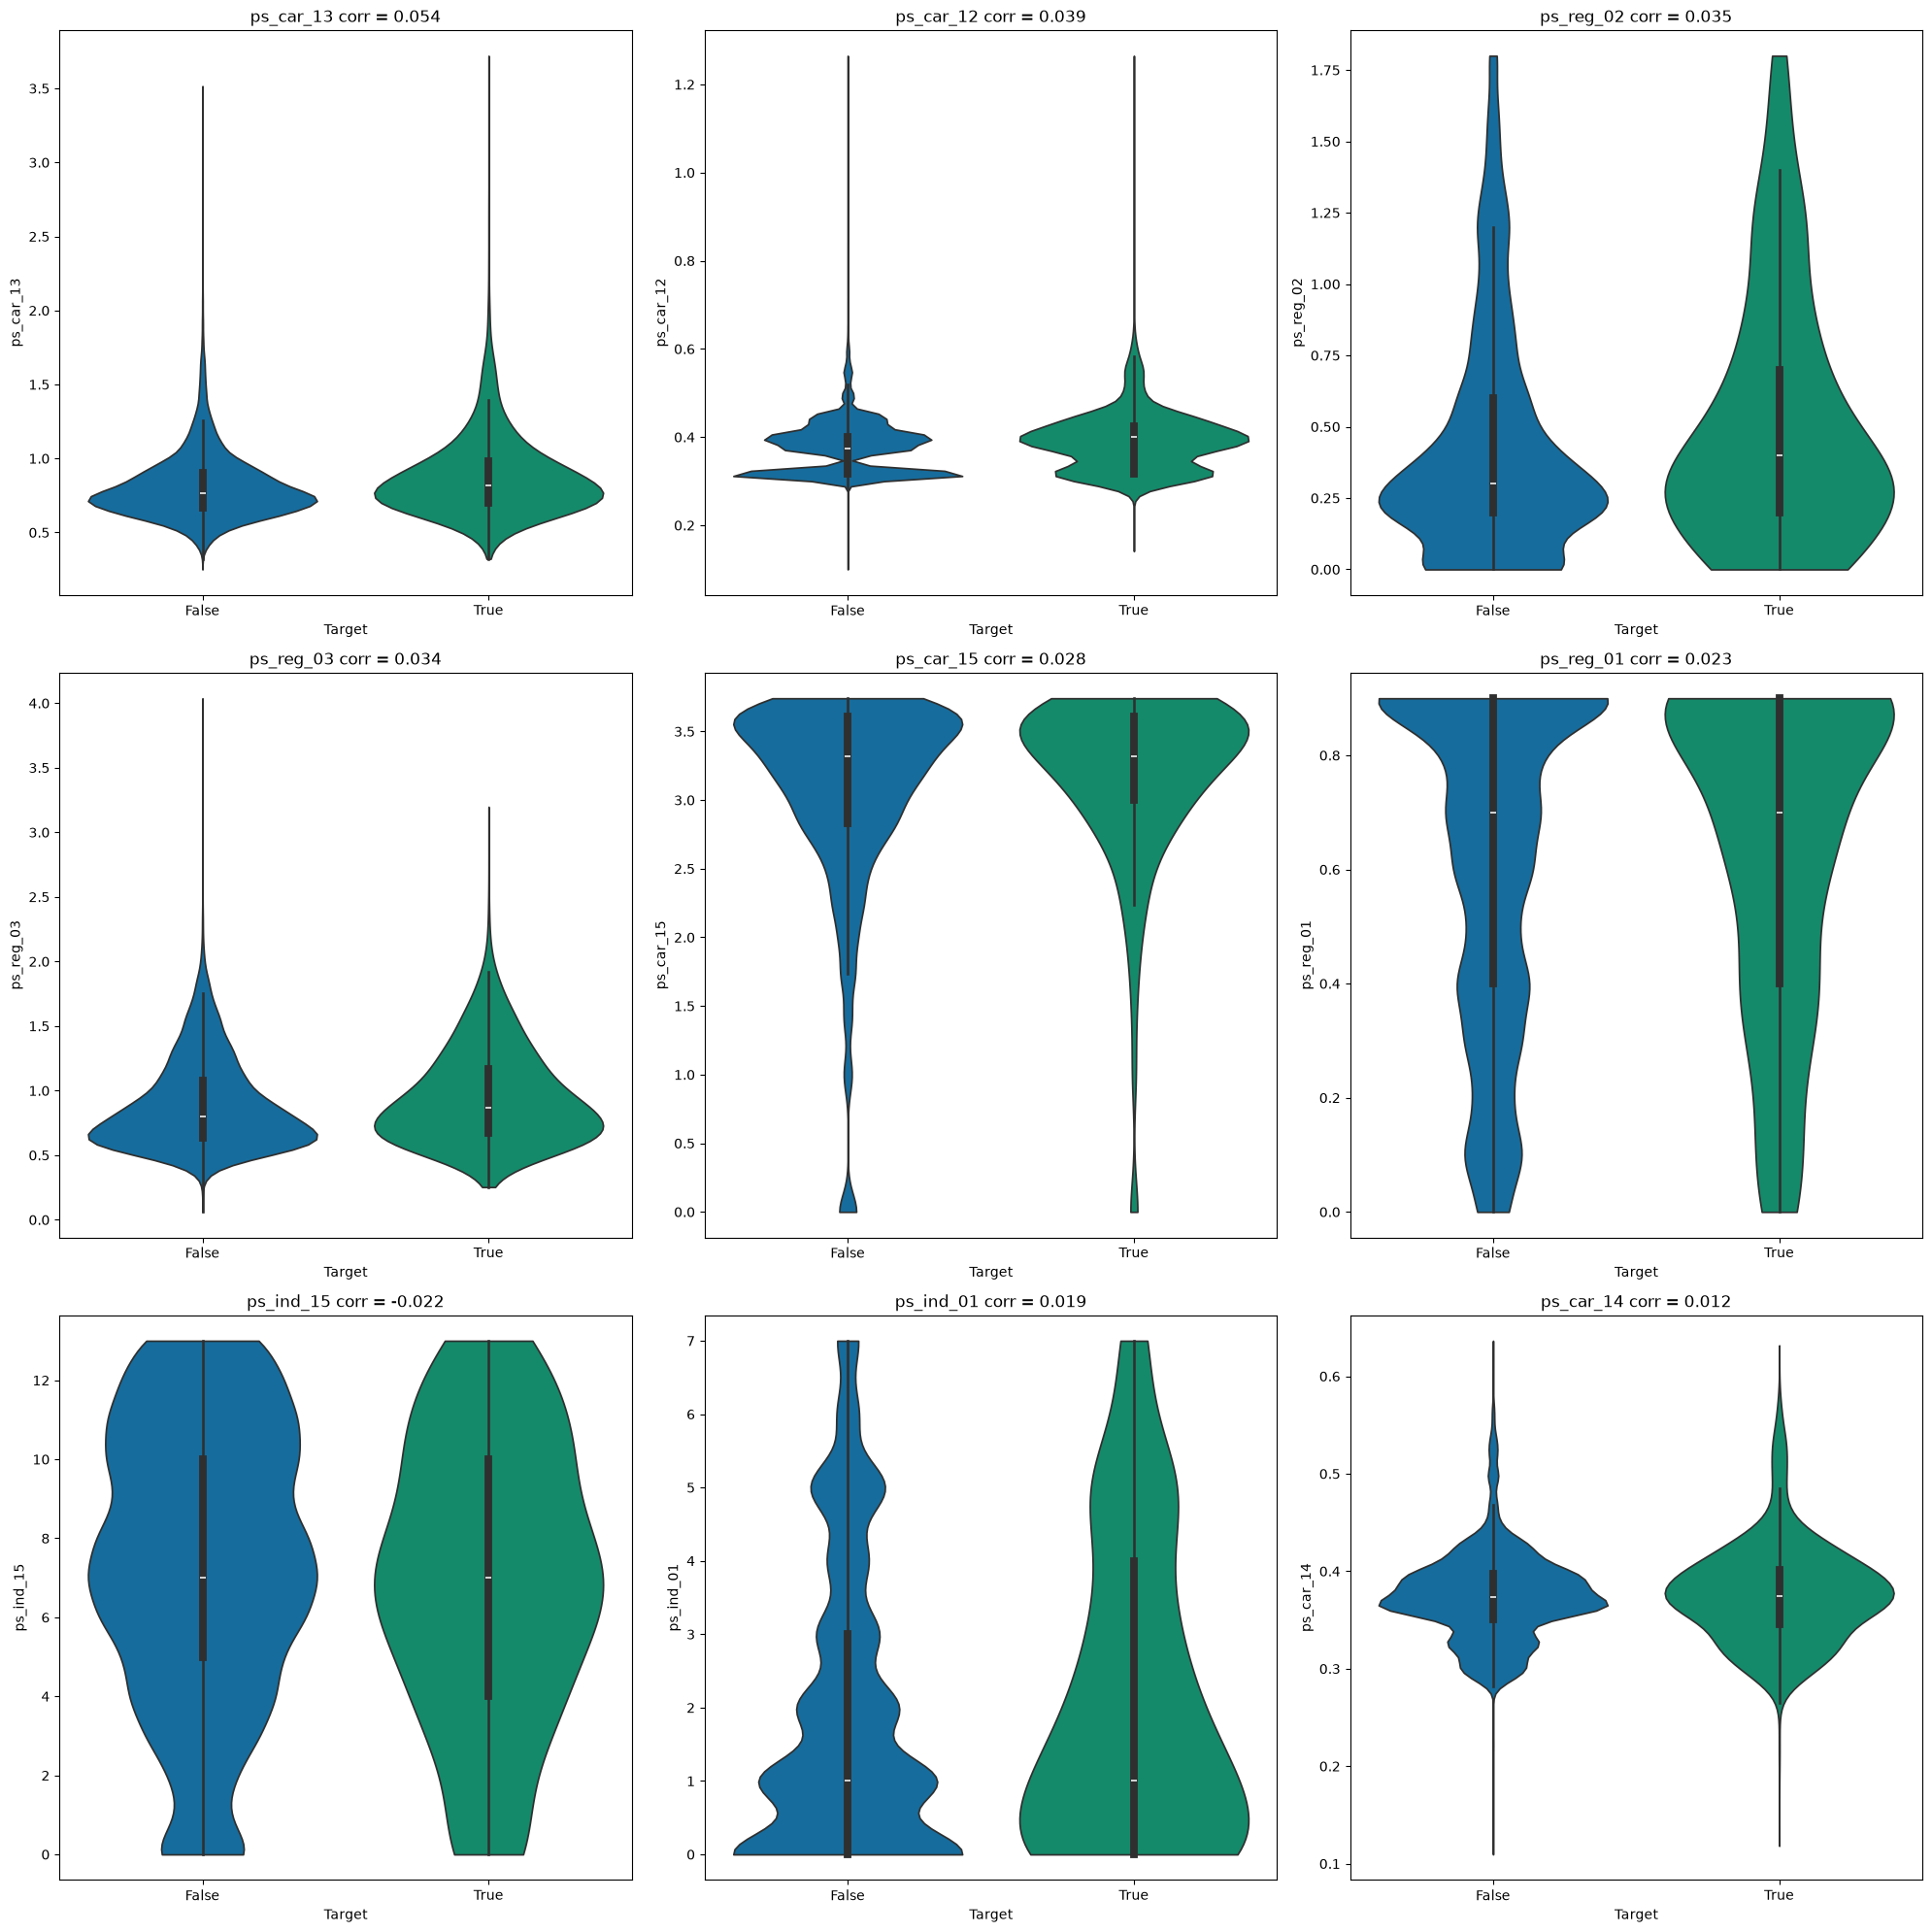

In [65]:
top_corr_feats = corr_num_target.abs().sort_values(ascending=False).head(9).index

fig, axes = plt.subplots(3, 3, figsize=(20, 20))

achsen = axes.flatten()

for idx, cols in enumerate(top_corr_feats):
    sns.violinplot(
        x="target",
        y=cols,
        data=df_raw,
        ax=achsen[idx],
        legend=False,
        common_norm=False,
        hue="target",
        bw_adjust=2.5,
        cut=0
    )
    achsen[idx].set_title(f"{cols} corr = {corr_num_target[cols]:.3f}")
    achsen[idx].set_xlabel("Target")

plt.tight_layout()

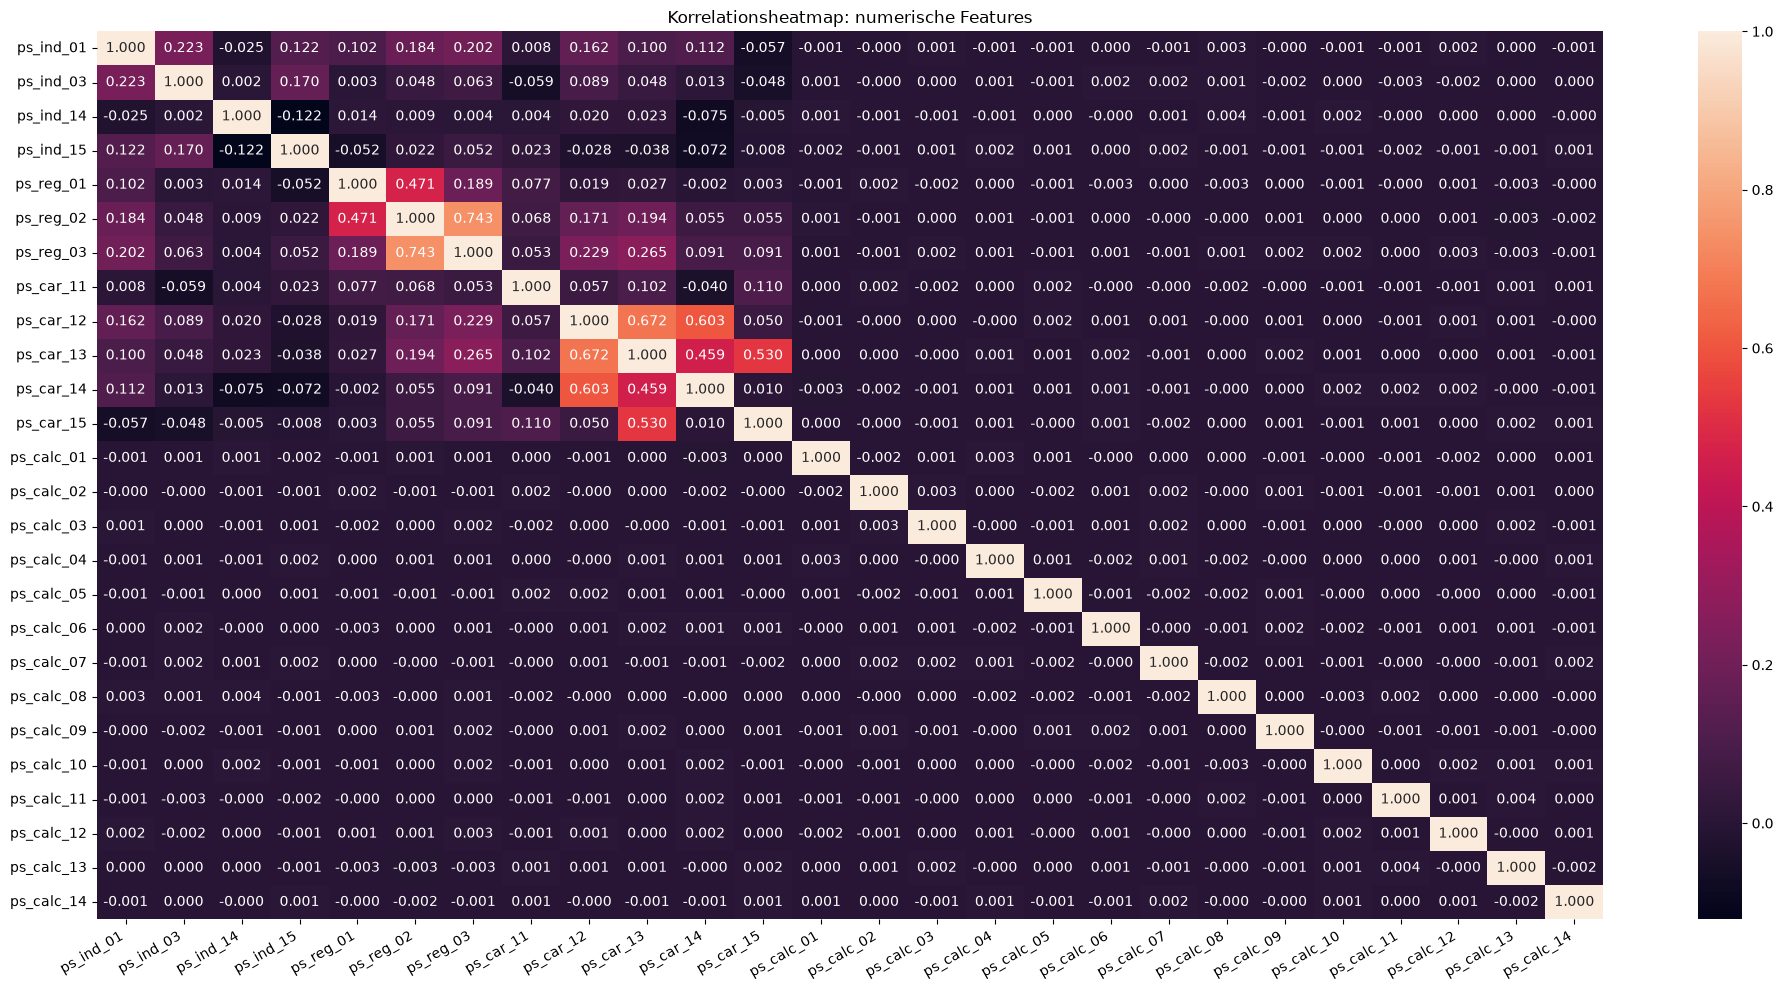

In [66]:
fig, ax = plt.subplots(figsize=(20,10))

sns.heatmap(
    df_raw[num_cols].corr(),
    ax=ax,
    xticklabels=True,
    yticklabels=True,
    annot=True,
    fmt=".3f"
)
ax.set_title("Korrelationsheatmap: numerische Features")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()

In [67]:
corr_num_matrix = df_raw[num_cols].corr()

corr_num_pairs = corr_num_matrix.where(
    np.triu(np.ones(corr_num_matrix.shape, dtype=bool), k=1)
).stack()

corr_num_pairs = corr_num_pairs[corr_num_pairs.abs() > 0.2].sort_values(key=abs, ascending=False)

corr_num_pairs_df = corr_num_pairs.reset_index()
corr_num_pairs_df.columns = ["feature_1", "feature_2", "corr"]
corr_num_pairs_df

,feature_1,feature_2,corr
0,ps_reg_02,ps_reg_03,0.742668
1,ps_car_12,ps_car_13,0.672014
2,ps_car_12,ps_car_14,0.603361
3,ps_car_13,ps_car_15,0.529519
4,ps_reg_01,ps_reg_02,0.471027
5,ps_car_13,ps_car_14,0.459047
6,ps_reg_03,ps_car_13,0.264800
7,ps_reg_03,ps_car_12,0.228926
8,ps_ind_01,ps_ind_03,0.223408
9,ps_ind_01,ps_reg_03,0.202096


In [68]:
corr_num_matrix = df_raw[num_cols].corr()

corr_num_pairs = corr_num_matrix.where(
    np.triu(np.ones(corr_num_matrix.shape, dtype=bool), k=1)
).stack()

corr_num_pairs = corr_num_pairs[corr_num_pairs.abs() > 0.5].sort_values(key=abs, ascending=False)

corr_num_pairs_df = corr_num_pairs.reset_index()
corr_num_pairs_df.columns = ["feature_1", "feature_2", "corr"]
corr_num_pairs_df

,feature_1,feature_2,corr
0,ps_reg_02,ps_reg_03,0.742668
1,ps_car_12,ps_car_13,0.672014
2,ps_car_12,ps_car_14,0.603361
3,ps_car_13,ps_car_15,0.529519


In [69]:
#calc scheint kaum korrs mit target aufzuweisen deshalb nochmal
calc_num_cols = [cols for cols in num_cols if cols.startswith("ps_calc_")]

calc_num_corr_target = corr_num_target[calc_num_cols].sort_values(key=abs, ascending=False)

print("Korrelation calc_ num features Target:")
print(calc_num_corr_target)


Korrelation calc_ num features Target:
ps_calc_03    0.001907
ps_calc_01    0.001782
ps_calc_14    0.001362
ps_calc_02    0.001360
ps_calc_12   -0.001133
ps_calc_10    0.001061
ps_calc_08   -0.001006
ps_calc_05    0.000771
ps_calc_09    0.000719
ps_calc_13   -0.000446
ps_calc_11    0.000371
ps_calc_07   -0.000103
ps_calc_06    0.000082
ps_calc_04    0.000033
Name: target, dtype: float64


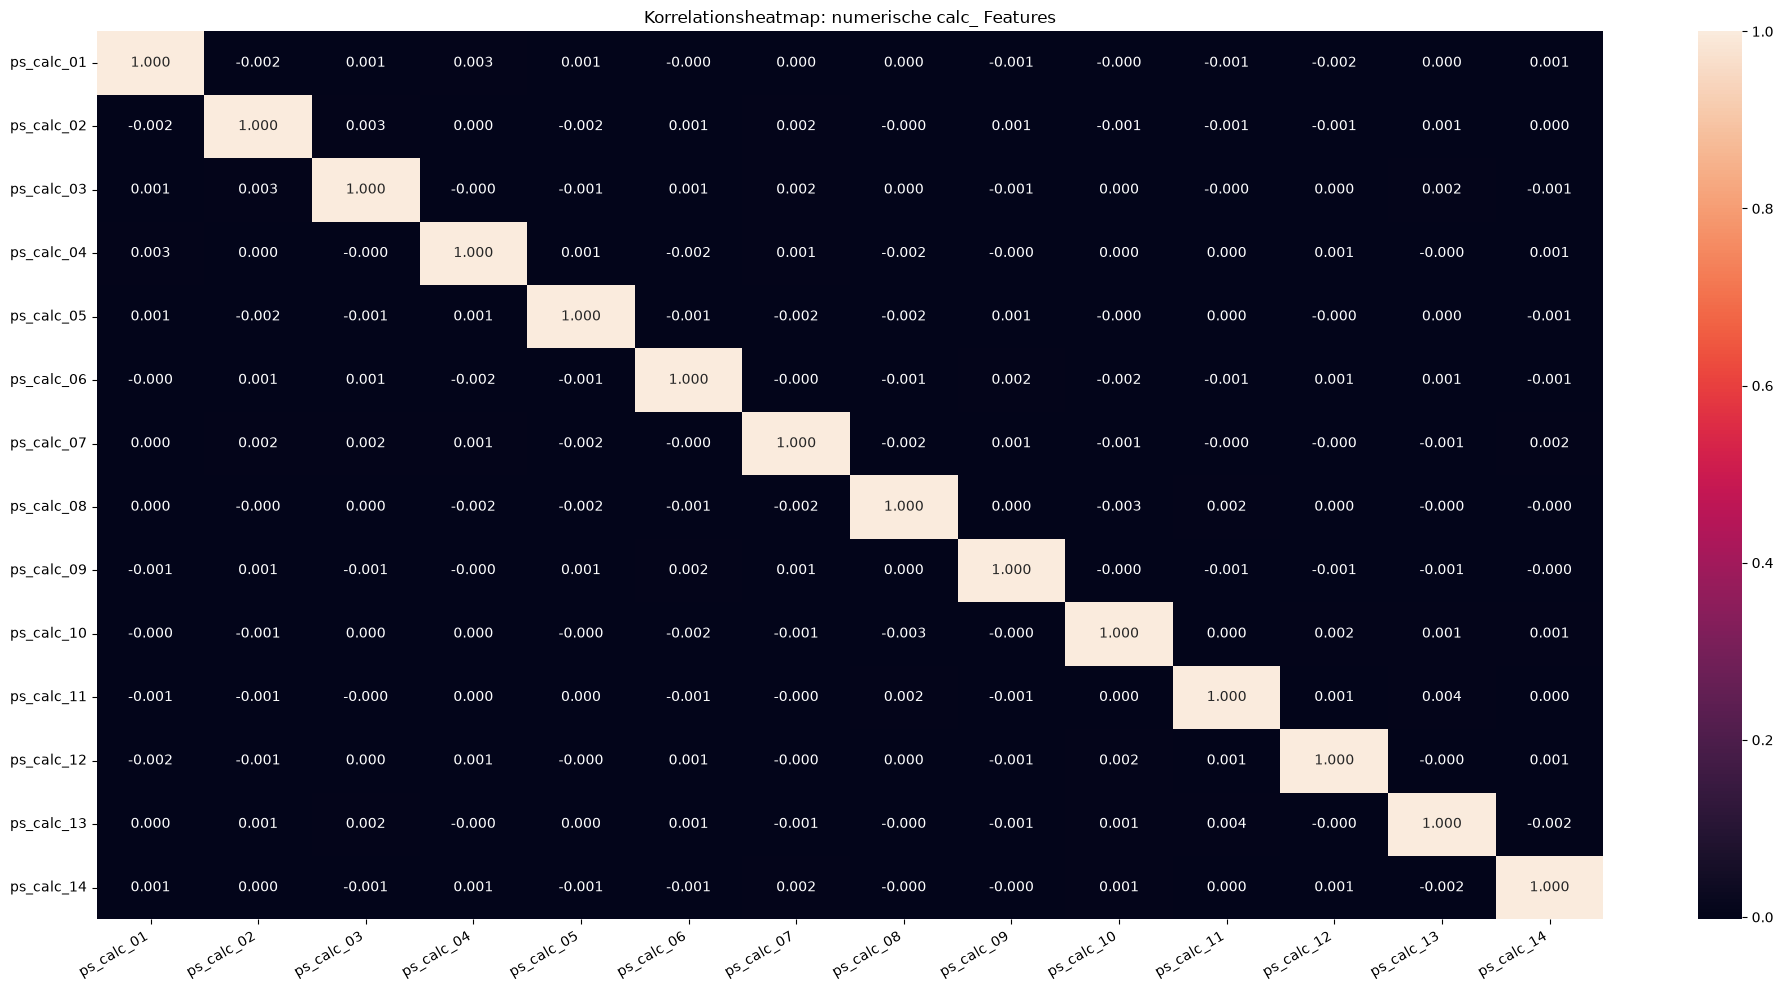

In [70]:
fig, ax = plt.subplots(figsize=(20,10))

sns.heatmap(
    df_raw[calc_num_cols].corr(),
    ax=ax,
    xticklabels=True,
    yticklabels=True,
    annot=True,
    fmt=".3f"
)
ax.set_title("Korrelationsheatmap: numerische calc_ Features")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()

## Duplikate

In [71]:
duplikat_n = df_raw.duplicated().sum()
print(f"Anzahl doppelter Zeilen: {duplikat_n}")

Anzahl doppelter Zeilen: 0


## gegebene Gruppen überprüfen

In [72]:
prefix_groups = {}
for prefix in {"ind", "reg", "car", "calc"}:
    prefix_groups[prefix] = [cols for cols in feat_cols if cols.startswith(f"ps_{prefix}_")]
    print(f"ps_{prefix}_: {len(prefix_groups[prefix])} Columns")

ps_calc_: 20 Columns
ps_ind_: 18 Columns
ps_car_: 16 Columns
ps_reg_: 3 Columns


In [73]:
for prefix, cols in prefix_groups.items():
    cols_num = [col for col in cols if col in num_cols]
    cols_bin = [col for col in cols if col in bin_cols]
    cols_cat = [col for col in cols if col in cat_cols]

    print(f"Für {prefix} :")
    print(f"num: {len(cols_num)}")
    print(f"bin: {len(cols_bin)}")
    print(f"cat: {len(cols_cat)}")

    compatible_cols = cols_num + cols_bin
    if len(compatible_cols) >= 2:
        korr = df_raw[compatible_cols].astype(float).corr()
        max_korr = korr.where(np.triu(np.ones(korr.shape, dtype=bool), k=1)).abs().max().max()
        print(f"max korr num/bin: {max_korr:.3f}" if pd.notna(max_korr) else "  nur 1 Feature")
    
    if len(cols_cat) >= 2:
        print(f"{len(cols_cat)} cat features: Cramers V prüfen")

Für calc :
num: 14
bin: 6
cat: 0
max korr num/bin: 0.004
Für ind :
num: 4
bin: 11
cat: 3
max korr num/bin: 0.890
3 cat features: Cramers V prüfen
Für car :
num: 5
bin: 0
cat: 11
max korr num/bin: 0.672
11 cat features: Cramers V prüfen
Für reg :
num: 3
bin: 0
cat: 0
max korr num/bin: 0.743


In [74]:
result_pairs = []

for prefix in ["reg", "ind", "car"]:
    cols = prefix_groups[prefix]
    compatible_cols = [col for col in cols if col in num_cols + bin_cols]
    korr = df_raw[compatible_cols].astype(float).corr()

    pairs = korr.where(np.triu(np.ones(korr.shape, dtype=bool), k=1)).stack()
    pairs = pairs[pairs.abs() > 0.5]

    for (col1, col2), v in pairs.items():
        result_pairs.append({
            "prefix": f"ps_{prefix}_", 
            "feature_1": col1,
            "feature_2": col2,
            "korr": v
        })

result_pairs_df = pd.DataFrame(result_pairs).sort_values("korr", key=abs, ascending=False)
result_pairs_df

,prefix,feature_1,feature_2,korr
2,ps_ind_,ps_ind_12_bin,ps_ind_14,0.890127
0,ps_reg_,ps_reg_02,ps_reg_03,0.742668
5,ps_car_,ps_car_12,ps_car_13,0.672014
6,ps_car_,ps_car_12,ps_car_14,0.603361
4,ps_ind_,ps_ind_16_bin,ps_ind_18_bin,-0.594265
1,ps_ind_,ps_ind_11_bin,ps_ind_14,0.564903
7,ps_car_,ps_car_13,ps_car_15,0.529519
3,ps_ind_,ps_ind_16_bin,ps_ind_17_bin,-0.518076


In [75]:
def cramers_v(x,y):
    """eigene cramer v über kreuztabelle und chi2"""
    conti = pd.crosstab(x,y)
    chi_2 = chi2_contingency(conti)[0]
    n = conti.sum().sum()
    r, k = conti.shape
    return np.sqrt(chi_2 / (n * (min(r,k) - 1)))

reslut_cramer = []

for prefix in ["ind", "car"]:
    cols_cat = [col for col in prefix_groups[prefix] if col in cat_cols]
    for col1, col2 in itertools.combinations(cols_cat, 2):
        v = cramers_v(df_raw[col1], df_raw[col2])
        reslut_cramer.append({
            "prefix": f"ps_{prefix}_", 
            "feature_1": col1,
            "feature_2": col2,
            "cramers_v": v
        })

cramers_df = pd.DataFrame(reslut_cramer).sort_values("cramers_v", ascending=False)
cramers_df

,prefix,feature_1,feature_2,cramers_v
47,ps_car_,ps_car_06_cat,ps_car_11_cat,0.722217
21,ps_car_,ps_car_02_cat,ps_car_11_cat,0.618692
16,ps_car_,ps_car_02_cat,ps_car_06_cat,0.540172
36,ps_car_,ps_car_04_cat,ps_car_11_cat,0.531340
54,ps_car_,ps_car_08_cat,ps_car_11_cat,0.474741
26,ps_car_,ps_car_03_cat,ps_car_08_cat,0.419515
10,ps_car_,ps_car_01_cat,ps_car_09_cat,0.379092
14,ps_car_,ps_car_02_cat,ps_car_04_cat,0.378184
31,ps_car_,ps_car_04_cat,ps_car_06_cat,0.331320
29,ps_car_,ps_car_03_cat,ps_car_11_cat,0.318508


# Notebook 05
Quelle: 05_pipeline_try.ipynb

Wichtiges aus der EDA:

|EDA Erkenntnis|Feature|Preproc Entscheidung|Begründung|
|---|---|---|---|
|Hohe Kardinalität|ps_car_11_cat|Target Encoding|bei 104 Klassen wäre one hot extremer bloat|
|Viele MVs, MV zeigt Signal für target|ps_car_03_cat, ps_car_05_cat, ps_reg_03|Missing feature binär neben imputieren, bei xgboost nan|Wenn imputiert/dropped, könnte signal verlieren|
|Mögliches eigene Gruppe|ps_ind_[16,17,18]_bin|erst übernehmen, bei feature engineering untersuchen||
|Redundanzen|ps_ind_12_bin, ps_ind_14|Erst beibehalten, drop test in modellvergleichen||
|Calc Gruppe kaum lineare korr mit target|ps_calc_*|Pipelines mit und ohne calc, modellvergleich später||
|Starke Klassenimbalance in target|target|Kein Resampling in preproc aber in modell training könnten wir oversampling oä versuchen, modelle nicht über acc sondern wie kaggle über gini bewerten||
|verschiedene Bereiche Verteilungen der continous features|ps_reg_*, ps_car_1[1-5], ps_calc_0[1-3]|Standard scaler für lineare modelle||

Weiteres:
- XGBoost verarbeitet nan nativ, also für xgboost keine imputation

In [76]:
x_train, y_train = df_train[feat_cols], df_train["target"]
x_val, y_val = df_val[feat_cols], df_val["target"]
x_test, y_test = df_test[feat_cols], df_test["target"]
x_full, y_full = df_raw[feat_cols], df_raw["target"]

idx_train_val = np.concatenate([idx_train, idx_val])
df_train_val = df_raw.iloc[idx_train_val]
x_train_val, y_train_val = df_train_val[feat_cols], df_train_val["target"]

pd.Series(
    {
        "train": [len(df_train), len(x_train), len(y_train)],
        "val": [len(df_val), len(x_val), len(y_val)],
        "test": [len(df_test), len(x_test), len(y_test)],
        "full": [len(df_raw), len(x_full), len(y_full)],
        "train_val": [len(df_train_val), len(x_train_val), len(y_train_val)]
    }
)

train        [476168, 476168, 476168]
val             [59522, 59522, 59522]
test            [59522, 59522, 59522]
full         [595212, 595212, 595212]
train_val    [535690, 535690, 535690]
dtype: object

In [77]:
# Hilfsvariablen

calc_cols = [c for c in feat_cols if c.startswith("ps_calc_")]

mv_cols = ["ps_car_03_cat", "ps_car_05_cat", "ps_reg_03", "ps_car_14"]

num_cols_no_calc = [c for c in num_cols if c not in calc_cols]
bin_cols_no_calc = [c for c in bin_cols if c not in calc_cols]
feat_cols_no_calc = [c for c in feat_cols if c not in calc_cols]

high_kard_cols = ["ps_car_11_cat"]
low_kard_cols = [c for c in cat_cols if c not in high_kard_cols]

bin_cols_one_drop = [c for c in bin_cols if c != "ps_ind_06_bin"]

## First pipelines

In [78]:
pd.Series({
    "feat_cols (df_raw)": len(feat_cols),
    "in Pipeline (Summe Hilfsvariablen)": len(num_cols) + len(low_kard_cols) + len(high_kard_cols) + len(bin_cols),
})

feat_cols (df_raw)                    57
in Pipeline (Summe Hilfsvariablen)    57
dtype: int64

## Modelle für die prepared werden soll
- logistische Regression
- XGBoost
- Random Forest(?)

Für jedes der Modelle sammle ich hier wichtige Punkte für die Preproc und erstelle zunächst eine Testpipeline zur Vorstellung

## Logistische Regression
- Nur numerische Daten: onehot und target encoder für cat cols
- Keine nan: SimpleImputer
- Skalierung: Standardscaler (Robustscaler?)
- Multikollinearität ausschließen: drop or regularisierung im training?

Plan: num_cols: impute&indicator-->scale; cat_low_kard-->onehot; cat_high_kard-->target; bin so lassen, rest droppen

Rssourcen (Aufrufdatum: 04.08.2026):
- https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
- https://www.geeksforgeeks.org/machine-learning/what-is-exactly-sklearnpipelinepipeline/
- https://scikit-learn.org/stable/modules/preprocessing.html
- https://scikit-learn.org/stable/modules/impute.html
- https://medium.com/analytics-vidhya/machine-learning-ii-logistic-regression-explained-data-pre-processing-hands-on-kaggle-728e6a9d4bbf
https://medium.com/my-data-camp-journey/preprocessing-data-for-logistic-regression-f311c937d765
- https://github.com/NaflanNadeer/Machine-Learning-with-Logistic-Regression-and-Data-Preprocessing


In [79]:
preproc_logreg = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler())
    ]), num_cols),
    ("cat_onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), low_kard_cols),
    ("cat_target", TargetEncoder(random_state=RANDOM_STATE), high_kard_cols),
    ("bin", "passthrough", bin_cols)
], remainder="drop")

In [80]:
preproc_logreg.fit(x_train, y_train)
x_train_logreg = preproc_logreg.transform(x_train)
x_train_logreg.shape

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


(476168, 127)

In [81]:
# version mit kfold für target encoder (bessere Reproduzierbarkeit)

cv_targetenc = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

preproc_logregMK2 = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler())
    ]), num_cols),
    ("cat_onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), low_kard_cols),
    ("cat_target", TargetEncoder(cv=cv_targetenc), high_kard_cols),
    ("bin", "passthrough", bin_cols)
], remainder="drop")

preproc_logregMK2.fit(x_train, y_train)
x_train_logregMK2 = preproc_logregMK2.transform(x_train)
x_train_logregMK2.shape

(476168, 127)

### Sanity Checks logreg preprocessing

In [82]:
type(x_train_logreg), type(x_train_logregMK2)

(numpy.ndarray, numpy.ndarray)

In [83]:
pd.Series({
    "nan MK1" : np.isnan(x_train_logreg).sum(),
    "nan MK2" : np.isnan(x_train_logregMK2).sum(),
    "Spalten MK1" : x_train_logreg.shape[1],
    "Spalten MK2" : x_train_logregMK2.shape[1],
    "Zeilen MK1" : x_train_logreg.shape[0],
    "Zeilen MK2" : x_train_logregMK2.shape[0]
})

nan MK1             0
nan MK2             0
Spalten MK1       127
Spalten MK2       127
Zeilen MK1     476168
Zeilen MK2     476168
dtype: int64

## XGBoost
- Kategorische Daten: nativ unterstützt, kein encoding
- nan: kein imputing nötig
- scaling: für bäume nicht nötig

möglich:
- encodings versuchen für besseren vergleich zu logreg als Modell?
- calc Gruppe droppen?

Plan: raw, also kein preprocess eig

Ressourcen (Aufrufdatum 05.08.2026):
- https://xgboost.readthedocs.io/en/stable/
    - https://xgboost.readthedocs.io/en/stable/tutorials/categorical.html
- https://developer.nvidia.com/blog/categorical-features-in-xgboost-without-manual-encoding/
- https://xgboosting.com/xgboosts-native-support-for-categorical-features/

# Notebook 06
Quelle: 06_L-lr-01_L-xgb-01_L-svm-01.ipynb

|Index|Modell|
|---|---|
|L-lr-01|Logistische Regression (simple)|
|L-xbg-01|XGBoost (simple)|
|L-svm-01|Support Vector Machine (simple)|

## L-lr-01

In [84]:
# Preprocessing mit calc 

preproc_logregMK2 = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler())
    ]), num_cols),
    ("cat_onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), low_kard_cols),
    ("cat_target", TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE), high_kard_cols),
    ("bin", "passthrough", bin_cols)
], remainder="drop").set_output(transform="pandas")

In [85]:
# Näher an VL

logreg_01 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols
        )
    ),
    LogisticRegression(
        max_iter=1000, 
        random_state=RANDOM_STATE
    )
)

## L-xgb-01

In [86]:
# Nativ Klassen und nan verarbeiten

xgb_01 = XGBClassifier(
    booster="gbtree",
    random_state=RANDOM_STATE,
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True
)

In [87]:
# mit encodings

xgb_01_enc = make_pipeline(
    make_column_transformer(
        ("passthrough", num_cols),
        (OneHotEncoder(handle_unknown="ignore", sparse_output=False), low_kard_cols),
        (TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE), high_kard_cols),
        ("passthrough", bin_cols)
    ),
    XGBClassifier(
        booster="gbtree",
        random_state=RANDOM_STATE,
        eval_metric="auc",
        tree_method="hist"
    )
)

## L-svm-01

In [88]:
svm_01 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols
        )
    ),
    LinearSVC(
        max_iter=1000, 
        random_state=RANDOM_STATE
    )
)

## Training

In [89]:
models = {
    "logreg_01": logreg_01,
    "xgb_01": xgb_01,
    "xgb_01_enc": xgb_01_enc,
    "svm_01": svm_01
}

In [90]:
train_times = {}

for name, model in models.items():
    start_time = time.time()
    model.fit(x_train, y_train)
    train_times[name] = time.time() - start_time
    print(f"Training time for {name}: {train_times[name]:.2f} seconds")

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Training time for logreg_01: 4.83 seconds
Training time for xgb_01: 5.52 seconds


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Training time for xgb_01_enc: 6.09 seconds


c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Training time for svm_01: 19.91 seconds


## Evaluation

In [91]:
# helper

def eval_model(name, model, x, y):
    scores = model.predict_proba(x)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(x)
    auc = roc_auc_score(y, scores)
    return {"modell": name, "auc": auc, "gini": 2 * auc - 1, "trainingszeit_s": train_times[name]}

results = []

In [92]:
# logreg01
res_logreg = eval_model("logreg_01", logreg_01, x_val, y_val)
results.append(res_logreg)
res_logreg

{'modell': 'logreg_01',
 'auc': 0.6168062891547132,
 'gini': 0.2336125783094265,
 'trainingszeit_s': 4.82947564125061}

In [93]:
# xgb01
res_xgb = eval_model("xgb_01", xgb_01, x_val, y_val)
results.append(res_xgb)
res_xgb

{'modell': 'xgb_01',
 'auc': 0.5999459986131522,
 'gini': 0.19989199722630446,
 'trainingszeit_s': 5.51651930809021}

In [94]:
#xgb01_enc
res_xgb_enc = eval_model("xgb_01_enc", xgb_01_enc, x_val, y_val)
results.append(res_xgb_enc)
res_xgb_enc

{'modell': 'xgb_01_enc',
 'auc': 0.6141728403064672,
 'gini': 0.22834568061293448,
 'trainingszeit_s': 6.087838411331177}

In [95]:
# svm01
res_svm = eval_model("svm_01", svm_01, x_val, y_val)
results.append(res_svm)
res_svm

{'modell': 'svm_01',
 'auc': 0.6174324213162528,
 'gini': 0.2348648426325055,
 'trainingszeit_s': 19.90646529197693}

In [96]:
df_results = pd.DataFrame(results).set_index("modell")
df_results

,auc,gini,trainingszeit_s
modell,,,
logreg_01,0.616806,0.233613,4.829476
xgb_01,0.599946,0.199892,5.516519
xgb_01_enc,0.614173,0.228346,6.087838
svm_01,0.617432,0.234865,19.906465


# Notebook 07
Quelle: 07_logistische_Regression.ipynb

In [97]:
train_times = {}
results = []

In [98]:
def eval_modell(mod_idx, model, x_train, y_train, x_val, y_val, train_time):
    """AUC auf Train und Val"""
    auc_train = roc_auc_score(y_train, model.predict_proba(x_train)[:, 1])
    auc_val = roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    return {
        "model_idx": mod_idx,
        "auc_train": auc_train,
        "auc_val": auc_val,
        "gini": 2 * auc_val - 1,
        "trainingszeit": train_time
    }

## L_lr_01

In [99]:
logreg_01 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols
        )
    ),
    LogisticRegression(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        verbose=1
    )
)

In [100]:
name = "L_lr_01"

start = time.time()
logreg_01.fit(x_train, y_train)
train_times[name] = time.time() - start

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [101]:
results.append(eval_modell(name, logreg_01, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,trainingszeit
model_idx,,,,
L_lr_01,0.633551,0.616806,0.233613,4.739974


In [102]:
setsizes = [0.1 ,0.25, 0.5, 0.75, 1.0]
sub_results = []
rng = np.random.default_rng(RANDOM_STATE)

for trainset in setsizes:
    n = int(len(x_train) * trainset)
    idx_sub = rng.permutation(len(x_train))[:n]
    x_sub, y_sub = x_train.iloc[idx_sub], y_train.iloc[idx_sub]

    model = clone(logreg_01)
    model.fit(x_sub, y_sub)

    sub_results.append({
        "train_size": n,
        "anteil": trainset,
        "auc_train": roc_auc_score(y_sub, model.predict_proba(x_sub)[:, 1]),
        "auc_val": roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    })

df_sub_results = pd.DataFrame(sub_results)
df_sub_results

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the

,train_size,anteil,auc_train,auc_val
0,47616,0.10,0.650671,0.601601
1,119042,0.25,0.637491,0.610619
2,238084,0.50,0.633127,0.615492
3,357126,0.75,0.632469,0.616342
4,476168,1.00,0.633550,0.616806


Text(0.5, 1.0, 'Learning Curve Logistic Regression')

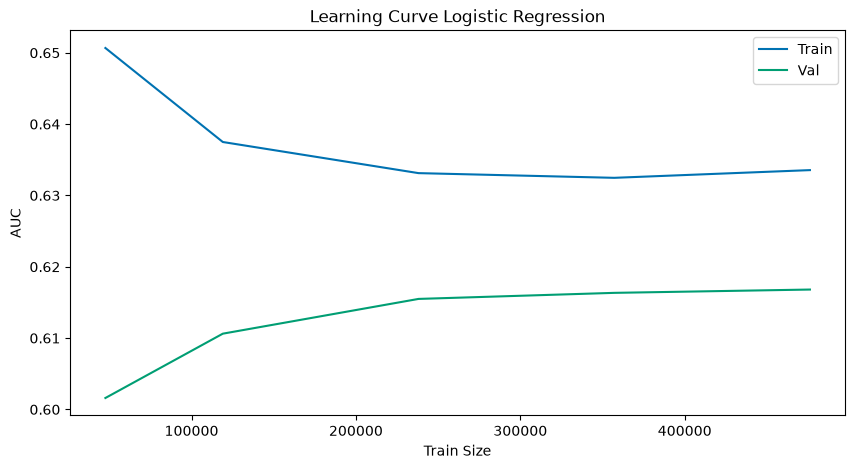

In [103]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["auc_train"], label="Train")
ax.plot(df_sub_results["train_size"], df_sub_results["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("Learning Curve Logistic Regression")

## L_lr_02

In [104]:
logreg_02 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols
        )
    ),
    LogisticRegression(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        class_weight="balanced",
        verbose=2
    )
)

In [105]:
name = "L_lr_02"

start = time.time()
logreg_02.fit(x_train, y_train)
train_times[name] = time.time() - start

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [106]:
results.append(eval_modell(name, logreg_02, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,trainingszeit
model_idx,,,,
L_lr_01,0.633551,0.616806,0.233613,4.739974
L_lr_02,0.634570,0.616929,0.233857,9.800627


In [107]:
setsizes = [0.1 ,0.25, 0.5, 0.75, 1.0]
sub_results = []
rng = np.random.default_rng(RANDOM_STATE)

for trainset in setsizes:
    n = int(len(x_train) * trainset)
    idx_sub = rng.permutation(len(x_train))[:n]
    x_sub, y_sub = x_train.iloc[idx_sub], y_train.iloc[idx_sub]

    model = clone(logreg_02)
    model.fit(x_sub, y_sub)

    sub_results.append({
        "train_size": n,
        "anteil": trainset,
        "auc_train": roc_auc_score(y_sub, model.predict_proba(x_sub)[:, 1]),
        "auc_val": roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    })

df_sub_results = pd.DataFrame(sub_results)
df_sub_results

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the

,train_size,anteil,auc_train,auc_val
0,47616,0.10,0.656575,0.601075
1,119042,0.25,0.639632,0.610251
2,238084,0.50,0.634815,0.613929
3,357126,0.75,0.633595,0.615899
4,476168,1.00,0.634569,0.617027


Text(0.5, 1.0, 'Learning Curve Logistic Regression')

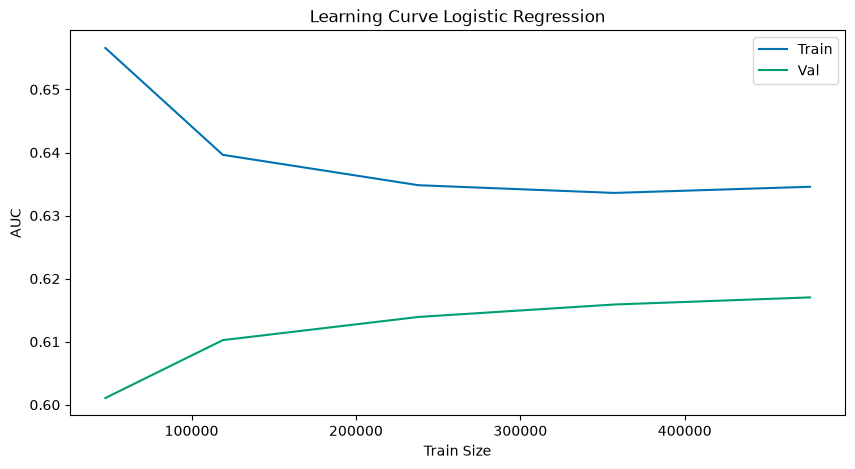

In [108]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["auc_train"], label="Train")
ax.plot(df_sub_results["train_size"], df_sub_results["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("Learning Curve Logistic Regression")

## L_lr_03

In [109]:
logreg_03 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols
        )
    ),
    LogisticRegression(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        class_weight="balanced",
        verbose=2
    )
)

In [110]:
name = "L_lr_03"

start = time.time()
logreg_03.fit(x_train, y_train)
train_times[name] = time.time() - start

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [111]:
results.append(eval_modell(name, logreg_03, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,trainingszeit
model_idx,,,,
L_lr_01,0.633551,0.616806,0.233613,4.739974
L_lr_02,0.634570,0.616929,0.233857,9.800627
L_lr_03,0.634573,0.617072,0.234144,9.240252


## L_lr_04

In [112]:
logreg_04 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            [c for c in bin_cols if c != "ps_ind_06_bin"]
        )
    ),
    LogisticRegression(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        class_weight="balanced",
        verbose=2
    )
)

In [113]:
name = "L_lr_04"

start = time.time()
logreg_04.fit(x_train, y_train)
train_times[name] = time.time() - start

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [114]:
results.append(eval_modell(name, logreg_04, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,trainingszeit
model_idx,,,,
L_lr_01,0.633551,0.616806,0.233613,4.739974
L_lr_02,0.634570,0.616929,0.233857,9.800627
L_lr_03,0.634573,0.617072,0.234144,9.240252
L_lr_04,0.634597,0.616891,0.233782,9.573685


## L_lr_05

In [115]:
num_cols_v5 = [c for c in num_cols if c not in ("ps_reg_03", "ps_ind_14")]
bin_cols_v5 = [c for c in bin_cols if c != "ps_ind_18_bin"]

logreg_05 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols_v5
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols_v5
        )
    ),
    LogisticRegression(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        class_weight="balanced",
        verbose=2
    )
)

In [116]:
name = "L_lr_05"

start = time.time()
logreg_05.fit(x_train, y_train)
train_times[name] = time.time() - start

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [117]:
results.append(eval_modell(name, logreg_05, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,trainingszeit
model_idx,,,,
L_lr_01,0.633551,0.616806,0.233613,4.739974
L_lr_02,0.634570,0.616929,0.233857,9.800627
L_lr_03,0.634573,0.617072,0.234144,9.240252
L_lr_04,0.634597,0.616891,0.233782,9.573685
L_lr_05,0.633909,0.615165,0.230331,8.863692


## L_lr_06

In [118]:
logreg_06 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols_no_calc
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols_no_calc
        )
    ),
    LogisticRegression(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        class_weight="balanced",
        verbose=2
    )
)

In [119]:
name = "L_lr_06"

start = time.time()
logreg_06.fit(x_train, y_train)
train_times[name] = time.time() - start

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [120]:
results.append(eval_modell(name, logreg_06, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,trainingszeit
model_idx,,,,
L_lr_01,0.633551,0.616806,0.233613,4.739974
L_lr_02,0.634570,0.616929,0.233857,9.800627
L_lr_03,0.634573,0.617072,0.234144,9.240252
L_lr_04,0.634597,0.616891,0.233782,9.573685
L_lr_05,0.633909,0.615165,0.230331,8.863692
L_lr_06,0.634388,0.617334,0.234668,7.183517


# Notebook 08
Quelle: 08_xgboost.ipynb

In [121]:
train_times = {}
results = []

In [122]:
def eval_modell(mod_idx, model, x_train, y_train, x_val, y_val, train_time, best_iter=None):
    """AUC auf Train und Val"""
    auc_train = roc_auc_score(y_train, model.predict_proba(x_train)[:, 1])
    auc_val = roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    return {
        "model_idx": mod_idx,
        "auc_train": auc_train,
        "auc_val": auc_val,
        "gini": 2 * auc_val - 1,
        "delta_auc": auc_train - auc_val,
        "best_iter": best_iter,
        "trainingszeit": train_time
    }

## L_xgb_01

In [123]:
xgb_01 = make_pipeline(
    make_column_transformer(
        ("passthrough", num_cols),
        (OneHotEncoder(handle_unknown="ignore", sparse_output=False), low_kard_cols),
        (TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE), high_kard_cols),
        ("passthrough", bin_cols)
    ),
    XGBClassifier(
        booster="gbtree",
        random_state=RANDOM_STATE,
        eval_metric="auc",
        tree_method="hist"
    )
)

In [124]:
name = "L_xgb_01"

start = time.time()
xgb_01.fit(x_train, y_train)
train_times[name] = time.time() - start

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [125]:
results.append(eval_modell(name, xgb_01, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
model_idx,,,,,,
L_xgb_01,0.790159,0.614173,0.228346,0.175986,None,5.597114


## L_xgb_02

In [126]:
xgb_02 = XGBClassifier(
    booster="gbtree",
    random_state=RANDOM_STATE,
    eval_metric="auc",
    tree_method="hist",
    n_estimators=1000,
    learning_rate=0.05,
    early_stopping_rounds=50
)

In [ ]:
#weil error für geamtdurchführung

# name = "L_xgb_02"

# start = time.time()
# xgb_02.fit(
#     x_train, y_train,
#     eval_set=[(x_train, y_train), (x_val, y_val)],
#     verbose=250
# )
# train_times[name] = time.time() - start

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:ps_ind_02_cat: category, ps_ind_04_cat: category, ps_ind_05_cat: category, ps_car_01_cat: category, ps_car_02_cat: category, ps_car_03_cat: category, ps_car_04_cat: category, ps_car_05_cat: category, ps_car_06_cat: category, ps_car_07_cat: category, ps_car_08_cat: category, ps_car_09_cat: category, ps_car_10_cat: category, ps_car_11_cat: category

In [ ]:
#weil error für geamtdurchführung

# results.append(
#     eval_modell(name, xgb_02, x_train, y_train, x_val, y_val,
#                 train_times[name], best_iter=xgb_02.best_iteration)
# )
# pd.DataFrame(results).set_index("model_idx")

KeyError: 'L_xgb_02'

In [ ]:
#weil error für geamtdurchführung

# hist = xgb_02.evals_result()

# fig, ax = plt.subplots(figsize=(10, 5))

# ax.plot(hist["validation_0"]["auc"], label="Train")
# ax.plot(hist["validation_1"]["auc"], label="Val")
# ax.axvline(xgb_02.best_iteration,color="red", linestyle="--",
#            label=f"best_iteration = {xgb_02.best_iteration}")
# ax.set_xlabel("Boosting-Runde")
# ax.set_ylabel("AUC")
# ax.set_title("Trainingsverlauf L_xgb_02")
# ax.legend()

XGBoostError: No evaluation result, `eval_set` is not used during training.

In [130]:
xgb_02MK2 = XGBClassifier(
    booster="gbtree",
    random_state=RANDOM_STATE,
    eval_metric="auc",
    tree_method="hist",
    n_estimators=5000,
    learning_rate=0.03,
    early_stopping_rounds=100
)

In [ ]:
#weil error für geamtdurchführung

# name = "L_xgb_02MK2"

# start = time.time()
# xgb_02MK2.fit(
#     x_train, y_train,
#     eval_set=[(x_train, y_train), (x_val, y_val)],
#     verbose=250
# )
# train_times[name] = time.time() - start

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:ps_ind_02_cat: category, ps_ind_04_cat: category, ps_ind_05_cat: category, ps_car_01_cat: category, ps_car_02_cat: category, ps_car_03_cat: category, ps_car_04_cat: category, ps_car_05_cat: category, ps_car_06_cat: category, ps_car_07_cat: category, ps_car_08_cat: category, ps_car_09_cat: category, ps_car_10_cat: category, ps_car_11_cat: category

In [ ]:
#weil error für geamtdurchführung

# results.append(
#     eval_modell(name, xgb_02MK2, x_train, y_train, x_val, y_val,
#                 train_times[name], best_iter=xgb_02MK2.best_iteration)
# )
# pd.DataFrame(results).set_index("model_idx")

KeyError: 'L_xgb_02MK2'

In [ ]:
#weil error für geamtdurchführung

# hist = xgb_02MK2.evals_result()

# fig, ax = plt.subplots(figsize=(10, 5))

# ax.plot(hist["validation_0"]["auc"], label="Train")
# ax.plot(hist["validation_1"]["auc"], label="Val")
# ax.axvline(xgb_02MK2.best_iteration,color="red", linestyle="--",
#            label=f"best_iteration = {xgb_02MK2.best_iteration}")
# ax.set_xlabel("Boosting-Runde")
# ax.set_ylabel("AUC")
# ax.set_title("Trainingsverlauf L_xgb_02")
# ax.legend()

XGBoostError: No evaluation result, `eval_set` is not used during training.

In [134]:
xgb_02MK3 = XGBClassifier(
    booster="gbtree",
    random_state=RANDOM_STATE,
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True,
    n_estimators=5000,
    learning_rate=0.03,
    early_stopping_rounds=100
)

In [135]:
name = "L_xgb_02MK3"

start = time.time()
xgb_02MK3.fit(
    x_train, y_train,
    eval_set=[(x_train, y_train), (x_val, y_val)],
    verbose=250
)
train_times[name] = time.time() - start

[0]	validation_0-auc:0.62710	validation_1-auc:0.59357
[236]	validation_0-auc:0.74701	validation_1-auc:0.62477


In [136]:
results.append(
    eval_modell(name, xgb_02MK3, x_train, y_train, x_val, y_val,
                train_times[name], best_iter=xgb_02MK3.best_iteration)
)
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
model_idx,,,,,,
L_xgb_01,0.790159,0.614173,0.228346,0.175986,NaN,5.597114
L_xgb_02MK3,0.715061,0.625933,0.251866,0.089128,136.0,28.835085


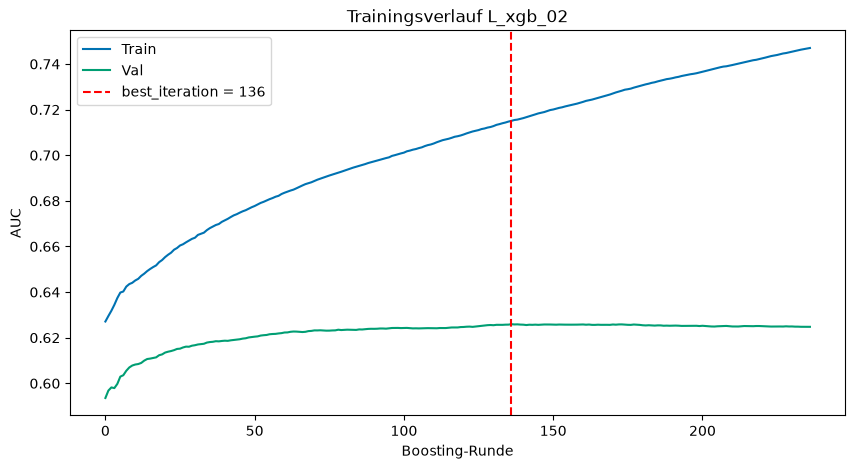

In [137]:
hist = xgb_02MK3.evals_result()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(hist["validation_0"]["auc"], label="Train")
ax.plot(hist["validation_1"]["auc"], label="Val")
ax.axvline(xgb_02MK3.best_iteration,color="red", linestyle="--",
           label=f"best_iteration = {xgb_02MK3.best_iteration}")
ax.set_xlabel("Boosting-Runde")
ax.set_ylabel("AUC")
ax.set_title("Trainingsverlauf L_xgb_02")
ax.legend()

## L_xgb_03

In [138]:
xgb_03 = XGBClassifier(
    booster="gbtree",
    random_state=RANDOM_STATE,
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True,
    n_estimators=5000,
    learning_rate=0.03,
    early_stopping_rounds=100
)

In [139]:
name = "L_xgb_03"

start = time.time()
xgb_03.fit(
    x_train, y_train,
    eval_set=[(x_train, y_train), (x_val, y_val)],
    verbose=250
)
train_times[name] = time.time() - start

[0]	validation_0-auc:0.62710	validation_1-auc:0.59357
[236]	validation_0-auc:0.74701	validation_1-auc:0.62477


In [140]:
results.append(
    eval_modell(name, xgb_03, x_train, y_train, x_val, y_val,
                train_times[name], best_iter=xgb_03.best_iteration)
)
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
model_idx,,,,,,
L_xgb_01,0.790159,0.614173,0.228346,0.175986,NaN,5.597114
L_xgb_02MK3,0.715061,0.625933,0.251866,0.089128,136.0,28.835085
L_xgb_03,0.715061,0.625933,0.251866,0.089128,136.0,28.850575


In [141]:
setsizes = [0.1 ,0.25, 0.5, 0.75, 1.0]
sub_results = []
rng = np.random.default_rng(RANDOM_STATE)

for trainset in setsizes:
    n = int(len(x_train) * trainset)
    idx_sub = rng.permutation(len(x_train))[:n]
    x_sub, y_sub = x_train.iloc[idx_sub], y_train.iloc[idx_sub]

    model = clone(xgb_03)
    model.fit(
        x_sub, y_sub,
        eval_set=[(x_val, y_val)],
        verbose=False
        )

    sub_results.append({
        "train_size": n,
        "anteil": trainset,
        "best_iter": model.best_iteration,
        "auc_train": roc_auc_score(y_sub, model.predict_proba(x_sub)[:, 1]),
        "auc_val": roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    })

df_sub_results = pd.DataFrame(sub_results)
df_sub_results

,train_size,anteil,best_iter,auc_train,auc_val
0,47616,0.10,31,0.783938,0.585420
1,119042,0.25,109,0.805022,0.609428
2,238084,0.50,100,0.740133,0.612255
3,357126,0.75,78,0.702194,0.621678
4,476168,1.00,171,0.726563,0.626843


Text(0.5, 1.0, 'XGBClassifier Learning Curve')

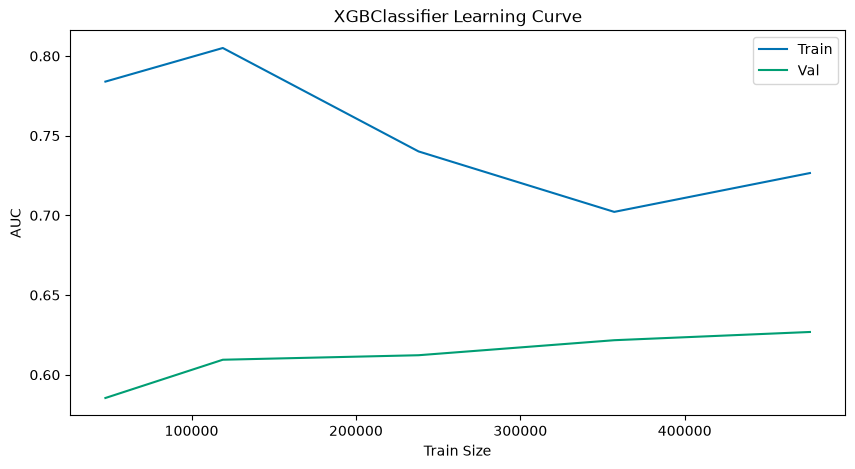

In [142]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["auc_train"], label="Train")
ax.plot(df_sub_results["train_size"], df_sub_results["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("XGBClassifier Learning Curve")

In [143]:
setsizes = [0.1 ,0.25, 0.5, 0.75, 1.0]
sub_results2 = []
rng = np.random.default_rng(RANDOM_STATE)

for trainset in setsizes:
    n = int(len(x_train) * trainset)
    idx_sub = rng.permutation(len(x_train))[:n]
    x_sub, y_sub = x_train[feat_cols_no_calc].iloc[idx_sub], y_train.iloc[idx_sub]

    model = clone(xgb_03)
    model.fit(
        x_sub[feat_cols_no_calc], y_sub,
        eval_set=[(x_val[feat_cols_no_calc], y_val)],
        verbose=False
    )

    sub_results2.append({
        "train_size": n,
        "anteil": trainset,
        "best_iter": model.best_iteration,
        "auc_train": roc_auc_score(y_sub, model.predict_proba(x_sub[feat_cols_no_calc])[:, 1]),
        "auc_val": roc_auc_score(y_val, model.predict_proba(x_val[feat_cols_no_calc])[:, 1])
    })

df_sub_results2 = pd.DataFrame(sub_results2)
df_sub_results2

,train_size,anteil,best_iter,auc_train,auc_val
0,47616,0.10,107,0.854246,0.590866
1,119042,0.25,91,0.777646,0.606999
2,238084,0.50,133,0.749387,0.614081
3,357126,0.75,134,0.723384,0.622104
4,476168,1.00,178,0.722944,0.627568


Text(0.5, 1.0, 'XGBClassifier Learning Curve without ps_calc features')

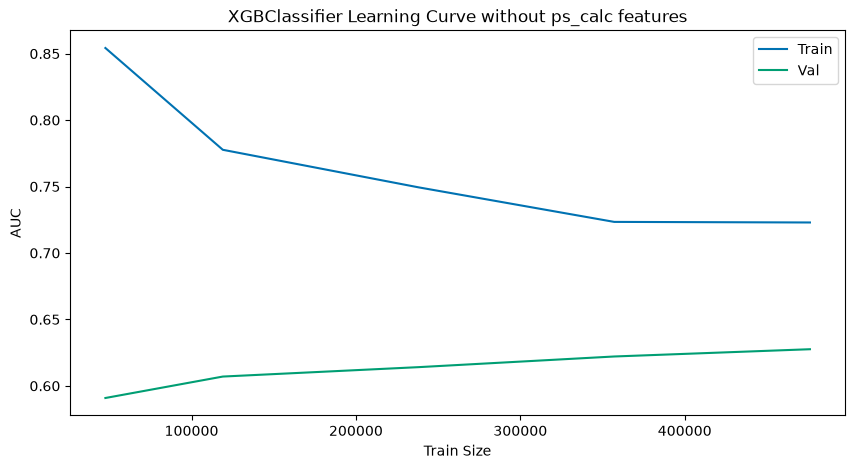

In [144]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results2["train_size"], df_sub_results2["auc_train"], label="Train")
ax.plot(df_sub_results2["train_size"], df_sub_results2["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("XGBClassifier Learning Curve without ps_calc features")

## L_xgb_04

In [145]:
imbalance = (y_train == 0).sum() / (y_train == 1).sum()

In [146]:
xgb_04 = XGBClassifier(
    booster="gbtree",
    random_state=RANDOM_STATE,
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True,
    n_estimators=5000,
    learning_rate=0.03,
    early_stopping_rounds=100,
    scale_pos_weight=imbalance
)

In [147]:
name = "L_xgb_04"

start = time.time()
xgb_04.fit(
    x_train, y_train,
    eval_set=[(x_train, y_train), (x_val, y_val)],
    verbose=250
)
train_times[name] = time.time() - start

[0]	validation_0-auc:0.62850	validation_1-auc:0.59172
[237]	validation_0-auc:0.76067	validation_1-auc:0.61786


In [148]:
results.append(
    eval_modell(name, xgb_04, x_train, y_train, x_val, y_val,
                train_times[name], best_iter=xgb_04.best_iteration)
)
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
model_idx,,,,,,
L_xgb_01,0.790159,0.614173,0.228346,0.175986,NaN,5.597114
L_xgb_02MK3,0.715061,0.625933,0.251866,0.089128,136.0,28.835085
L_xgb_03,0.715061,0.625933,0.251866,0.089128,136.0,28.850575
L_xgb_04,0.722182,0.621516,0.243033,0.100665,137.0,29.063162


## L_xgb_05

In [149]:
xgb_05 = XGBClassifier(
    booster="gbtree",
    random_state=RANDOM_STATE,
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True,
    n_estimators=5000,
    learning_rate=0.03,
    early_stopping_rounds=100
)

In [150]:
name = "L_xgb_05"

start = time.time()
xgb_05.fit(
    x_train[feat_cols_no_calc], y_train,
    eval_set=[(x_train[feat_cols_no_calc], y_train), (x_val[feat_cols_no_calc], y_val)],
    verbose=250
)
train_times[name] = time.time() - start

[0]	validation_0-auc:0.62710	validation_1-auc:0.59359
[250]	validation_0-auc:0.73850	validation_1-auc:0.62484
[279]	validation_0-auc:0.74399	validation_1-auc:0.62397


In [151]:
results.append(
    eval_modell(name, xgb_05, x_train[feat_cols_no_calc], y_train, x_val[feat_cols_no_calc], y_val,
                train_times[name], best_iter=xgb_05.best_iteration)
)
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
model_idx,,,,,,
L_xgb_01,0.790159,0.614173,0.228346,0.175986,NaN,5.597114
L_xgb_02MK3,0.715061,0.625933,0.251866,0.089128,136.0,28.835085
L_xgb_03,0.715061,0.625933,0.251866,0.089128,136.0,28.850575
L_xgb_04,0.722182,0.621516,0.243033,0.100665,137.0,29.063162
L_xgb_05,0.722850,0.626677,0.253353,0.096173,179.0,44.591629


## Versuch für feature importance
Über get_booster

In [152]:
booster = xgb_03.get_booster()

importance = pd.DataFrame({
    "gain": pd.Series(booster.get_score(importance_type="gain")),
    "total_gain": pd.Series(booster.get_score(importance_type="total_gain")),
    "weight": pd.Series(booster.get_score(importance_type="weight")),
})

importance = importance.reindex(feat_cols).fillna(0) #nicht benutzte

importance["gruppe"] = np.select(
    [importance.index.str.startswith("ps_calc_"),
     importance.index.str.startswith("ps_car_"),
     importance.index.str.startswith("ps_ind_"),
     importance.index.str.startswith("ps_reg_")],
    ["calc", "car", "ind", "reg"], default="andere"
)
importance["rang"] = importance["gain"].rank(ascending=False).astype(int)

importance.sort_values("gain", ascending=False).head(15)

,gain,total_gain,weight,gruppe,rang
ps_ind_06_bin,52.468121,4144.981445,79.0,ind,1
ps_ind_17_bin,39.203430,7291.837891,186.0,ind,2
ps_car_13,39.182076,17200.931641,439.0,car,3
ps_ind_05_cat,29.166807,15341.740234,526.0,ind,4
ps_ind_16_bin,26.401131,1953.683716,74.0,ind,5
ps_ind_07_bin,25.885414,1967.291504,76.0,ind,6
ps_car_03_cat,22.196455,1953.287964,88.0,car,7
ps_car_11_cat,18.746685,74967.992188,3999.0,car,8
ps_car_07_cat,17.821169,2405.857910,135.0,car,9
ps_ind_09_bin,17.261753,1260.107910,73.0,ind,10


In [153]:
importance.groupby("gruppe").agg(
    n_features=("gain", "size"),
    n_ungenutzt=("total_gain", lambda a: (a == 0).sum()),
    gain_anteil=("total_gain", lambda a: a.sum() / importance["total_gain"].sum()),
    median_rang=("rang", "median"),
).sort_values("gain_anteil", ascending=False)

,n_features,n_ungenutzt,gain_anteil,median_rang
gruppe,,,,
car,16,0,0.557099,22.0
ind,18,2,0.244434,17.5
calc,20,0,0.101429,40.0
reg,3,0,0.097038,12.0


Text(0.5, 1.0, 'feature importance über total_gain, L_xgb_03')

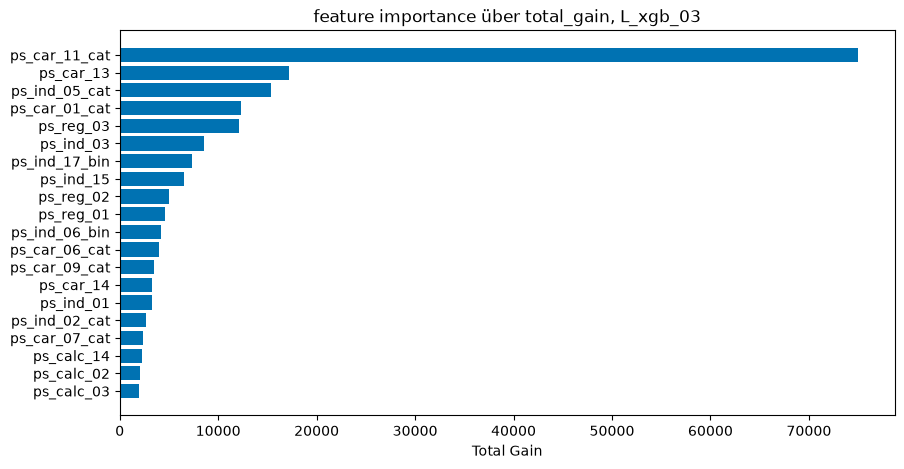

In [154]:
top = importance.sort_values("total_gain").tail(20)

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(top.index, top["total_gain"])
ax.set_xlabel("Total Gain")
ax.set_title("feature importance über total_gain, L_xgb_03")

## L_xgb_06

In [155]:
# nur target ecoding
targ_enc = TargetEncoder(cv=5, random_state=RANDOM_STATE)

x_train_06 = x_train.copy()
x_val_06 = x_val.copy()

x_train_06["ps_car_11_cat"] = targ_enc.fit_transform(
    x_train[high_kard_cols], y_train
).astype("float32")
x_val_06["ps_car_11_cat"] = targ_enc.transform(
    x_val[high_kard_cols]
).astype("float32")

x_train_06["ps_car_11_cat"].describe()

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


count    476168.000000
mean          0.036446
std           0.009676
min           0.016329
25%           0.028362
50%           0.034718
75%           0.044178
max           0.078113
Name: ps_car_11_cat, dtype: float64

In [156]:
xgb_06 = XGBClassifier(
    booster="gbtree",
    random_state=RANDOM_STATE,
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True,
    n_estimators=5000,
    learning_rate=0.03,
    early_stopping_rounds=100
)

In [157]:
name = "L_xgb_06"

start = time.time()
xgb_06.fit(
    x_train_06, y_train,
    eval_set=[(x_train_06, y_train), (x_val_06, y_val)],
    verbose=250
)
train_times[name] = time.time() - start

[0]	validation_0-auc:0.62116	validation_1-auc:0.60301
[250]	validation_0-auc:0.71833	validation_1-auc:0.63259
[283]	validation_0-auc:0.72393	validation_1-auc:0.63249


In [158]:
results.append(
    eval_modell(name, xgb_06, x_train_06, y_train, x_val_06, y_val,
                train_times[name], best_iter=xgb_06.best_iteration)
)
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
model_idx,,,,,,
L_xgb_01,0.790159,0.614173,0.228346,0.175986,NaN,5.597114
L_xgb_02MK3,0.715061,0.625933,0.251866,0.089128,136.0,28.835085
L_xgb_03,0.715061,0.625933,0.251866,0.089128,136.0,28.850575
L_xgb_04,0.722182,0.621516,0.243033,0.100665,137.0,29.063162
L_xgb_05,0.722850,0.626677,0.253353,0.096173,179.0,44.591629
L_xgb_06,0.703628,0.633323,0.266646,0.070305,183.0,32.661080


## L_xgb_07

In [159]:
# nur target ecoding
targ_enc_no_calc = TargetEncoder(cv=5, random_state=RANDOM_STATE)

x_train_06_no_calc = x_train[feat_cols_no_calc].copy()
x_val_06_no_calc = x_val[feat_cols_no_calc].copy()

x_train_06_no_calc["ps_car_11_cat"] = targ_enc_no_calc.fit_transform(
    x_train[high_kard_cols], y_train
).astype("float32")
x_val_06_no_calc["ps_car_11_cat"] = targ_enc_no_calc.transform(
    x_val[high_kard_cols]
).astype("float32")

x_train_06_no_calc["ps_car_11_cat"].describe()

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


count    476168.000000
mean          0.036446
std           0.009676
min           0.016329
25%           0.028362
50%           0.034718
75%           0.044178
max           0.078113
Name: ps_car_11_cat, dtype: float64

In [160]:
xgb_07 = XGBClassifier(
    booster="gbtree",
    random_state=RANDOM_STATE,
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True,
    n_estimators=5000,
    learning_rate=0.03,
    early_stopping_rounds=100
)

In [161]:
name = "L_xgb_07"

start = time.time()
xgb_07.fit(
    x_train_06_no_calc, y_train,
    eval_set=[(x_train_06_no_calc, y_train), (x_val_06_no_calc, y_val)],
    verbose=250
)
train_times[name] = time.time() - start

[0]	validation_0-auc:0.62127	validation_1-auc:0.60249
[250]	validation_0-auc:0.70827	validation_1-auc:0.63397
[342]	validation_0-auc:0.72065	validation_1-auc:0.63334


In [162]:
results.append(
    eval_modell(name, xgb_07, x_train_06_no_calc, y_train, x_val_06_no_calc, y_val,
                train_times[name], best_iter=xgb_07.best_iteration)
)
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
model_idx,,,,,,
L_xgb_01,0.790159,0.614173,0.228346,0.175986,NaN,5.597114
L_xgb_02MK3,0.715061,0.625933,0.251866,0.089128,136.0,28.835085
L_xgb_03,0.715061,0.625933,0.251866,0.089128,136.0,28.850575
L_xgb_04,0.722182,0.621516,0.243033,0.100665,137.0,29.063162
L_xgb_05,0.722850,0.626677,0.253353,0.096173,179.0,44.591629
L_xgb_06,0.703628,0.633323,0.266646,0.070305,183.0,32.661080
L_xgb_07,0.707142,0.634122,0.268245,0.073020,242.0,33.536283


# Notebook 09
Quelle: 09_Support_Vector_Machine.ipynb

In [163]:
train_times = {}
results = []

In [164]:
def eval_modell(mod_idx, model, x_train, y_train, x_val, y_val, train_time):
    """AUC auf Train und Val"""
    auc_train = roc_auc_score(y_train, model.decision_function(x_train))
    auc_val = roc_auc_score(y_val, model.decision_function(x_val))
    return {
        "model_idx": mod_idx,
        "auc_train": auc_train,
        "auc_val": auc_val,
        "gini": 2 * auc_val - 1,
        "delta_auc": auc_train - auc_val,
        "trainingszeit": train_time
    }

## L_svm_01

In [165]:
svm_01 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols
        )
    ),
    LinearSVC(
        max_iter=1000, 
        random_state=RANDOM_STATE
    )
)

In [166]:
name = "L_svm_01"

start_time = time.time()
svm_01.fit(x_train, y_train)
train_times[name] = time.time() - start_time

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [167]:
results.append(eval_modell(name, svm_01, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,trainingszeit
model_idx,,,,,
L_svm_01,0.634215,0.617432,0.234865,0.016782,19.046716


## L_svm_02

In [168]:
svm_02 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols
        )
    ),
    LinearSVC(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        C=1.0,
        dual=False,
    )
)

In [169]:
name = "L_svm_02"

start_time = time.time()
svm_02.fit(x_train, y_train)
train_times[name] = time.time() - start_time

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [170]:
results.append(eval_modell(name, svm_02, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,trainingszeit
model_idx,,,,,
L_svm_01,0.634215,0.617432,0.234865,0.016782,19.046716
L_svm_02,0.634215,0.617432,0.234865,0.016782,18.706465


In [171]:
setsizes = [0.1 ,0.25, 0.5, 0.75, 1.0]
sub_results = []
rng = np.random.default_rng(RANDOM_STATE)

for trainset in setsizes:
    n = int(len(x_train) * trainset)
    idx_sub = rng.permutation(len(x_train))[:n]
    x_sub, y_sub = x_train.iloc[idx_sub], y_train.iloc[idx_sub]

    model = clone(svm_02)
    model.fit(x_sub, y_sub)

    sub_results.append({
        "train_size": n,
        "anteil": trainset,
        "auc_train": roc_auc_score(y_sub, model.decision_function(x_sub)),
        "auc_val": roc_auc_score(y_val, model.decision_function(x_val))
    })

df_sub_results = pd.DataFrame(sub_results)
df_sub_results

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the

,train_size,anteil,auc_train,auc_val
0,47616,0.10,0.653417,0.602545
1,119042,0.25,0.638548,0.611342
2,238084,0.50,0.634742,0.615180
3,357126,0.75,0.632774,0.616171
4,476168,1.00,0.634245,0.617436


Text(0.5, 1.0, 'Linear SVC Learning Curve')

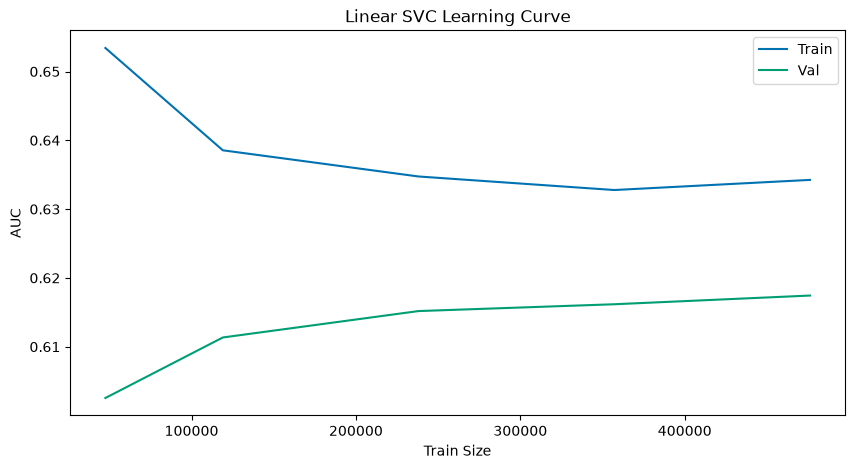

In [172]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["auc_train"], label="Train")
ax.plot(df_sub_results["train_size"], df_sub_results["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("Linear SVC Learning Curve")

## L_svm_03

In [173]:
svm_03 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols
        )
    ),
    LinearSVC(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        C=1.0,
        dual=False,
        class_weight="balanced"
    )
)

In [174]:
name = "L_svm_03"

start_time = time.time()
svm_03.fit(x_train, y_train)
train_times[name] = time.time() - start_time

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [175]:
results.append(eval_modell(name, svm_03, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,trainingszeit
model_idx,,,,,
L_svm_01,0.634215,0.617432,0.234865,0.016782,19.046716
L_svm_02,0.634215,0.617432,0.234865,0.016782,18.706465
L_svm_03,0.635508,0.617228,0.234456,0.018280,46.174002


## L_svm_04

In [176]:
svm_04 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols
        )
    ),
    LinearSVC(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        C=1.0,
        dual=False,
    )
)

In [177]:
name = "L_svm_04"

start_time = time.time()
svm_04.fit(x_train, y_train)
train_times[name] = time.time() - start_time

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [178]:
results.append(eval_modell(name, svm_04, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,trainingszeit
model_idx,,,,,
L_svm_01,0.634215,0.617432,0.234865,0.016782,19.046716
L_svm_02,0.634215,0.617432,0.234865,0.016782,18.706465
L_svm_03,0.635508,0.617228,0.234456,0.018280,46.174002
L_svm_04,0.634308,0.617421,0.234841,0.016888,21.699320


In [179]:
svm_04MK2 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols_one_drop
        )
    ),
    LinearSVC(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        C=1.0,
        dual=False,
    )
)

In [180]:
name = "L_svm_04MK2"

start_time = time.time()
svm_04MK2.fit(x_train, y_train)
train_times[name] = time.time() - start_time

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [181]:
results.append(eval_modell(name, svm_04MK2, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,trainingszeit
model_idx,,,,,
L_svm_01,0.634215,0.617432,0.234865,0.016782,19.046716
L_svm_02,0.634215,0.617432,0.234865,0.016782,18.706465
L_svm_03,0.635508,0.617228,0.234456,0.018280,46.174002
L_svm_04,0.634308,0.617421,0.234841,0.016888,21.699320
L_svm_04MK2,0.634295,0.617426,0.234852,0.016869,26.762124


## L_svm_05

In [182]:
transformer_05 = make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols
        )
    )

In [183]:
svm_05 = make_pipeline(
    transformer_05,
    StandardScaler(),
    LinearSVC(
            max_iter=1000, 
            random_state=RANDOM_STATE,
            C=1.0,
            dual=False
    )
)

In [184]:
name = "L_svm_05"

start_time = time.time()
svm_05.fit(x_train, y_train)
train_times[name] = time.time() - start_time

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [185]:
results.append(eval_modell(name, svm_05, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,trainingszeit
model_idx,,,,,
L_svm_01,0.634215,0.617432,0.234865,0.016782,19.046716
L_svm_02,0.634215,0.617432,0.234865,0.016782,18.706465
L_svm_03,0.635508,0.617228,0.234456,0.018280,46.174002
L_svm_04,0.634308,0.617421,0.234841,0.016888,21.699320
L_svm_04MK2,0.634295,0.617426,0.234852,0.016869,26.762124
L_svm_05,0.634318,0.617418,0.234835,0.016900,8.808955


## L_svm_06

In [186]:
svm_06 = make_pipeline(
    make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ),
            num_cols_no_calc
        ),
        (
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            low_kard_cols
        ),
        (
            TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
            high_kard_cols
        ),
        (
            "passthrough",
            bin_cols_no_calc
        )
    ),
    LinearSVC(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        C=1.0,
        dual=False,
    )
)

In [187]:
name = "L_svm_06"

start_time = time.time()
svm_06.fit(x_train, y_train)
train_times[name] = time.time() - start_time

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [188]:
results.append(eval_modell(name, svm_06, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,trainingszeit
model_idx,,,,,
L_svm_01,0.634215,0.617432,0.234865,0.016782,19.046716
L_svm_02,0.634215,0.617432,0.234865,0.016782,18.706465
L_svm_03,0.635508,0.617228,0.234456,0.018280,46.174002
L_svm_04,0.634308,0.617421,0.234841,0.016888,21.699320
L_svm_04MK2,0.634295,0.617426,0.234852,0.016869,26.762124
L_svm_05,0.634318,0.617418,0.234835,0.016900,8.808955
L_svm_06,0.634153,0.617918,0.235836,0.016236,16.113906


# Notebook 10
Quelle: 10_log_reg_opti_1.ipynb

## Grid Search

### L_lr_07

In [189]:
pipe_07 = make_pipeline(
    make_column_transformer(
            (
                make_pipeline(
                    SimpleImputer(strategy="median", add_indicator=True),
                    StandardScaler()
                ),
                num_cols_no_calc
            ),
            (
                OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
                low_kard_cols
            ),
            (
                TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
                high_kard_cols
            ),
            (
                "passthrough",
                bin_cols_no_calc
            )
        ),
    LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    )
)

In [190]:
param_grid_07_outdated = {
    "logisticregression__C": [0.01, 0.1, 1, 10, 100],
    "logisticregression__penalty": ["l1", "l2", "elasticnet", None],
    "logisticregression__tol": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    "logisticregression__solver": ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"],
    "logisticregression__class_weight": [None, "balanced"],
    "logisticregression__fit_intercept": [True, False]
}

In [191]:
param_grid_07 = [
    # lbfgs, newton-cg, newton-cholesky, sag nur l2 oder ohne penalty
    {
        "logisticregression__solver": ["lbfgs", "newton-cg", "newton-cholesky", "sag"],
        "logisticregression__penalty": ["l2", None],
        "logisticregression__C": [0.01, 0.1, 1, 10, 100],
        "logisticregression__tol": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        "logisticregression__class_weight": [None, "balanced"],
        "logisticregression__fit_intercept": [True, False],
    },
    # liblinear: l1 oder l2 kein penalty=None
    {
        "logisticregression__solver": ["liblinear"],
        "logisticregression__penalty": ["l1", "l2"],
        "logisticregression__C": [0.01, 0.1, 1, 10, 100],
        "logisticregression__tol": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        "logisticregression__class_weight": [None, "balanced"],
        "logisticregression__fit_intercept": [True, False],
    },
    # saga: elasticnet braucht l1_ratio, sonst alles
    {
        "logisticregression__solver": ["saga"],
        "logisticregression__penalty": ["l1", "l2", "elasticnet", None],
        "logisticregression__l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0],
        "logisticregression__C": [0.01, 0.1, 1, 10, 100],
        "logisticregression__tol": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        "logisticregression__class_weight": [None, "balanced"],
        "logisticregression__fit_intercept": [True, False],
    },
]

In [192]:
grid_search_07 = GridSearchCV(
    estimator=pipe_07,
    param_grid=param_grid_07,
    cv=[(idx_train, idx_val)],
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [193]:
# grid_search_07.fit(x_full, y_full)

In [194]:
# best_model_07 = grid_search_07.best_estimator_
# y_test_proba_07 = best_model_07.predict_proba(x_test)[:, 1]
# model_test_score = roc_auc_score(y_test, y_test_proba_07)

In [195]:
# grid_search_07.best_params_

In [196]:
# pd.Series({
#     "Best score(roc-auc)": grid_search_07.best_score_,
#     "Best parameters": grid_search_07.best_params_,
#     "Modell test-score(roc_auc)": model_test_score
# })

# Notebook 11
Quelle: 11_CatBoost_tryout.ipynb

In [197]:
train_times = {}
results = []

In [198]:
def eval_modell(mod_idx, model, x_train, y_train, x_val, y_val, train_time, best_iter=None):
    """AUC auf Train und Val"""
    auc_train = roc_auc_score(y_train, model.predict_proba(x_train)[:, 1])
    auc_val = roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    return {
        "model_idx": mod_idx,
        "auc_train": auc_train,
        "auc_val": auc_val,
        "gini": 2 * auc_val - 1,
        "delta_auc": auc_train - auc_val,
        "best_iter": best_iter,
        "trainingszeit": train_time
    }

In [199]:
def mv_for_cb(df, fill_var="missing"):
    """df copy mit ersetzten nans"""
    outs = df.copy()
    for col in outs.columns:
        if outs[col].dtype.name == "category":
            if fill_var not in outs[col].cat.categories:
                outs[col] = outs[col].cat.add_categories([fill_var])
            outs[col] = outs[col].fillna(fill_var)
    return outs

In [200]:
x_train_cb = mv_for_cb(x_train)
x_val_cb = mv_for_cb(x_val)
x_test_cb = mv_for_cb(x_test)
x_full_cb = mv_for_cb(x_full)

pd.Series(
    {
        "train": len(x_train_cb),
        "val": len(x_val_cb),
        "test": len(x_val_cb),
        "full": len(x_full_cb)
    }
)

train    476168
val       59522
test      59522
full     595212
dtype: int64

## L_cb_01

In [201]:
L_cb_01 = CatBoostClassifier(
    random_seed=RANDOM_STATE,
    eval_metric="AUC",
    cat_features=cat_cols,
    verbose=250
)

In [ ]:
# wegen error (siehe logbuch)

# name = "L_cb_01"

# start = time.time()
# L_cb_01.fit(
#     x_train, y_train,
#     eval_set=(x_val, y_val)
# )
# train_times[name] = time.time() - start

CatBoostError: Invalid type for cat_feature[object_idx=189,feature_idx=1]=NaN : cat_features must be integer or string, real number values and NaN values should be converted to string.

In [ ]:
# wegen error

# results.append(
#     eval_modell(name, L_cb_01, x_train, y_train, x_val, y_val, train_times[name], best_iter=L_cb_01.get_best_iteration())
# )
# pd.DataFrame(results)

KeyError: 'L_cb_01'

## L_cb_02

In [204]:
prep_mv_for_cb = FunctionTransformer(mv_for_cb)

In [205]:
L_cb_02 = make_pipeline(
    make_column_transformer(
        (prep_mv_for_cb, low_kard_cols + high_kard_cols),
        ("passthrough", num_cols),
        ("passthrough", bin_cols)
    ).set_output(transform="pandas"),
    CatBoostClassifier(
        random_seed=RANDOM_STATE,
        eval_metric="AUC",
        cat_features=cat_cols,
        verbose=250
    )
)

In [ ]:
# wegen error siehe logbuch

# name = "L_cb_02"

# start = time.time()
# L_cb_02.fit(
#     x_train, y_train,
#     eval_set=(x_val, y_val)
# )
# train_times[name] = time.time() - start

ValueError: Pipeline.fit does not accept the eval_set parameter. You can pass parameters to specific steps of your pipeline using the stepname__parameter format, e.g. `Pipeline.fit(X, y, logisticregression__sample_weight=sample_weight)`.

In [ ]:
# wegen error

# results.append(
#     eval_modell(name, L_cb_02, x_train, y_train, x_val, y_val, train_times[name], best_iter=L_cb_02.get_best_iteration())
# )
# pd.DataFrame(results)

KeyError: 'L_cb_02'

## L_cb_03

In [208]:
L_cb_03 = CatBoostClassifier(
    random_seed=RANDOM_STATE,
    eval_metric="AUC",
    cat_features=cat_cols,
    verbose=250
)

In [209]:
name = "L_cb_03"

start = time.time()
L_cb_03.fit(
    x_train_cb, y_train,
    eval_set=(x_val_cb, y_val)
)
train_times[name] = time.time() - start

Learning rate set to 0.145317
0:	test: 0.5431933	best: 0.5431933 (0)	total: 512ms	remaining: 8m 31s
250:	test: 0.6287398	best: 0.6293726 (191)	total: 1m 10s	remaining: 3m 29s
500:	test: 0.6285437	best: 0.6293726 (191)	total: 2m 19s	remaining: 2m 19s
750:	test: 0.6293256	best: 0.6294542 (622)	total: 3m 28s	remaining: 1m 9s
999:	test: 0.6279261	best: 0.6294542 (622)	total: 4m 37s	remaining: 0us

bestTest = 0.629454207
bestIteration = 622

Shrink model to first 623 iterations.


In [210]:
results.append(
    eval_modell(name, L_cb_03, x_train_cb, y_train, x_val_cb, y_val, train_times[name], best_iter=L_cb_03.get_best_iteration())
)
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_cb_03,0.707501,0.629454,0.258908,0.078047,622,278.702926


## L_cb_04

In [211]:
x_train_obj = x_train_cb.copy()
x_train_obj[cat_cols] = x_train_obj[cat_cols].astype("object")

x_val_obj = x_val_cb.copy()
x_val_obj[cat_cols] = x_val_obj[cat_cols].astype("object")

In [212]:
L_cb_04 = CatBoostClassifier(
    random_seed=RANDOM_STATE,
    eval_metric="AUC",
    cat_features=cat_cols,
    verbose=250
)

In [213]:
name = "L_cb_04"

start = time.time()
L_cb_04.fit(
    x_train_obj, y_train,
    eval_set=(x_val_obj, y_val)
)
train_times[name] = time.time() - start

Learning rate set to 0.145317
0:	test: 0.5431933	best: 0.5431933 (0)	total: 311ms	remaining: 5m 10s
250:	test: 0.6287398	best: 0.6293726 (191)	total: 1m 11s	remaining: 3m 33s
500:	test: 0.6285437	best: 0.6293726 (191)	total: 2m 23s	remaining: 2m 22s
750:	test: 0.6293256	best: 0.6294542 (622)	total: 3m 33s	remaining: 1m 10s
999:	test: 0.6279261	best: 0.6294542 (622)	total: 4m 44s	remaining: 0us

bestTest = 0.629454207
bestIteration = 622

Shrink model to first 623 iterations.


In [214]:
results.append(
    eval_modell(name, L_cb_04, x_train_obj, y_train, x_val_obj, y_val, train_times[name], best_iter=L_cb_04.get_best_iteration())
)
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_cb_03,0.707501,0.629454,0.258908,0.078047,622,278.702926
1,L_cb_04,0.707501,0.629454,0.258908,0.078047,622,286.992747


## L_cb_05

In [215]:
L_cb_05 = CatBoostClassifier(
    random_seed=RANDOM_STATE,
    task_type="CPU",
    eval_metric="AUC",
    thread_count=-1,
    allow_writing_files=False,
    cat_features=cat_cols,
    use_best_model=True,
    early_stopping_rounds=100,
    loss_function="Logloss",
    verbose=250,
    iterations=5000
)

In [216]:
name = "L_cb_05"

start = time.time()
L_cb_05.fit(
    x_train_cb, y_train,
    eval_set=(x_val_cb, y_val)
)
train_times[name] = time.time() - start

Learning rate set to 0.072155
0:	test: 0.5431933	best: 0.5431933 (0)	total: 308ms	remaining: 25m 41s
250:	test: 0.6295040	best: 0.6295609 (246)	total: 1m 8s	remaining: 21m 28s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6306126038
bestIteration = 360

Shrink model to first 361 iterations.


In [217]:
results.append(
    eval_modell(name, L_cb_05, x_train_cb, y_train, x_val_cb, y_val, train_times[name], best_iter=L_cb_05.get_best_iteration())
)
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_cb_03,0.707501,0.629454,0.258908,0.078047,622,278.702926
1,L_cb_04,0.707501,0.629454,0.258908,0.078047,622,286.992747
2,L_cb_05,0.662884,0.630613,0.261225,0.032271,360,127.477940


## L_cb_06

In [218]:
L_cb_06 = CatBoostClassifier(
    random_seed=RANDOM_STATE,
    task_type="CPU",
    eval_metric="AUC",
    thread_count=-1,
    allow_writing_files=False,
    cat_features=cat_cols,
    use_best_model=True,
    early_stopping_rounds=100,
    loss_function="Logloss",
    verbose=250,
    iterations=5000,
    boosting_type="Plain"
)

In [219]:
name = "L_cb_06"

start = time.time()
L_cb_06.fit(
    x_train_cb, y_train,
    eval_set=(x_val_cb, y_val)
)
train_times[name] = time.time() - start

Learning rate set to 0.072155
0:	test: 0.5431933	best: 0.5431933 (0)	total: 312ms	remaining: 25m 57s
250:	test: 0.6295040	best: 0.6295609 (246)	total: 1m 8s	remaining: 21m 44s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6306126038
bestIteration = 360

Shrink model to first 361 iterations.


In [220]:
results.append(
    eval_modell(name, L_cb_06, x_train_cb, y_train, x_val_cb, y_val, train_times[name], best_iter=L_cb_06.get_best_iteration())
)
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_cb_03,0.707501,0.629454,0.258908,0.078047,622,278.702926
1,L_cb_04,0.707501,0.629454,0.258908,0.078047,622,286.992747
2,L_cb_05,0.662884,0.630613,0.261225,0.032271,360,127.477940
3,L_cb_06,0.662884,0.630613,0.261225,0.032271,360,129.785524


## L_cb_07

In [221]:
L_cb_07 = CatBoostClassifier(
    random_seed=RANDOM_STATE,
    task_type="CPU",
    eval_metric="AUC",
    thread_count=-1,
    allow_writing_files=False,
    cat_features=cat_cols,
    use_best_model=True,
    early_stopping_rounds=100,
    loss_function="Logloss",
    verbose=250,
    iterations=5000,
    boosting_type="Ordered"
)

In [222]:
name = "L_cb_07"

start = time.time()
L_cb_07.fit(
    x_train_cb, y_train,
    eval_set=(x_val_cb, y_val)
)
train_times[name] = time.time() - start

Learning rate set to 0.072155
0:	test: 0.5431933	best: 0.5431933 (0)	total: 603ms	remaining: 50m 13s
250:	test: 0.6278569	best: 0.6279805 (244)	total: 2m 8s	remaining: 40m 37s
500:	test: 0.6302114	best: 0.6303062 (498)	total: 4m 41s	remaining: 42m 4s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6303061937
bestIteration = 498

Shrink model to first 499 iterations.


In [223]:
results.append(
    eval_modell(name, L_cb_07, x_train_cb, y_train, x_val_cb, y_val, train_times[name], best_iter=L_cb_07.get_best_iteration())
)
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_cb_03,0.707501,0.629454,0.258908,0.078047,622,278.702926
1,L_cb_04,0.707501,0.629454,0.258908,0.078047,622,286.992747
2,L_cb_05,0.662884,0.630613,0.261225,0.032271,360,127.477940
3,L_cb_06,0.662884,0.630613,0.261225,0.032271,360,129.785524
4,L_cb_07,0.670042,0.630306,0.260612,0.039736,498,342.507730


## L_cb_08

In [224]:
x_train_no_calc_cb = mv_for_cb(x_train[feat_cols_no_calc])
x_val_no_calc_cb = mv_for_cb(x_val[feat_cols_no_calc])

In [225]:
L_cb_08 = CatBoostClassifier(
    random_seed=RANDOM_STATE,
    task_type="CPU",
    eval_metric="AUC",
    thread_count=-1,
    allow_writing_files=False,
    cat_features=cat_cols,
    use_best_model=True,
    early_stopping_rounds=100,
    loss_function="Logloss",
    verbose=250,
    iterations=5000,
    boosting_type="Plain"
)

In [226]:
name = "L_cb_08"

start = time.time()
L_cb_08.fit(
    x_train_no_calc_cb, y_train,
    eval_set=(x_val_no_calc_cb, y_val)
)
train_times[name] = time.time() - start

Learning rate set to 0.072155
0:	test: 0.5706700	best: 0.5706700 (0)	total: 325ms	remaining: 27m 2s
250:	test: 0.6290511	best: 0.6291683 (244)	total: 1m 11s	remaining: 22m 29s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6295290792
bestIteration = 275

Shrink model to first 276 iterations.


In [227]:
results.append(
    eval_modell(name, L_cb_08, x_train_no_calc_cb, y_train, x_val_no_calc_cb, y_val, train_times[name], best_iter=L_cb_08.get_best_iteration())
)
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_cb_03,0.707501,0.629454,0.258908,0.078047,622,278.702926
1,L_cb_04,0.707501,0.629454,0.258908,0.078047,622,286.992747
2,L_cb_05,0.662884,0.630613,0.261225,0.032271,360,127.477940
3,L_cb_06,0.662884,0.630613,0.261225,0.032271,360,129.785524
4,L_cb_07,0.670042,0.630306,0.260612,0.039736,498,342.507730
5,L_cb_08,0.655493,0.629529,0.259058,0.025964,275,108.243218


# Learning Curves

## Plain, fixed with calc

In [228]:
setsizes = [0.1 ,0.25, 0.5, 0.75, 1.0]
sub_results = []
rng = np.random.default_rng(RANDOM_STATE)

for trainset in setsizes:
    n = int(len(x_train_cb) * trainset)
    idx_sub = rng.permutation(len(x_train_cb))[:n]
    x_sub, y_sub = x_train_cb.iloc[idx_sub], y_train.iloc[idx_sub]

    model = CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        eval_metric="AUC",
        thread_count=-1,
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        loss_function="Logloss",
        verbose=250,
        iterations=5000,
        boosting_type="Plain"
        )

    start = time.time()
    model.fit(
        x_sub, y_sub,
        eval_set=[(x_val_cb, y_val)],
        verbose=False
        )
    fit_time = time.time() - start

    sub_results.append({
        "train_size": n,
        "anteil": trainset,
        "best_iter": model.get_best_iteration(),
        "auc_train": roc_auc_score(y_sub, model.predict_proba(x_sub)[:, 1]),
        "auc_val": roc_auc_score(y_val, model.predict_proba(x_val_cb)[:, 1]),
        "fit_time": fit_time
    })

df_sub_results = pd.DataFrame(sub_results)
df_sub_results

,train_size,anteil,best_iter,auc_train,auc_val,fit_time
0,47616,0.10,388,0.740868,0.616425,43.208842
1,119042,0.25,311,0.681324,0.622267,46.517488
2,238084,0.50,699,0.694531,0.628131,134.067792
3,357126,0.75,340,0.665749,0.629136,96.415254
4,476168,1.00,643,0.677728,0.630150,229.428705


Text(0.5, 1.0, 'CatBoost Learning Curve (Plain, Calc)')

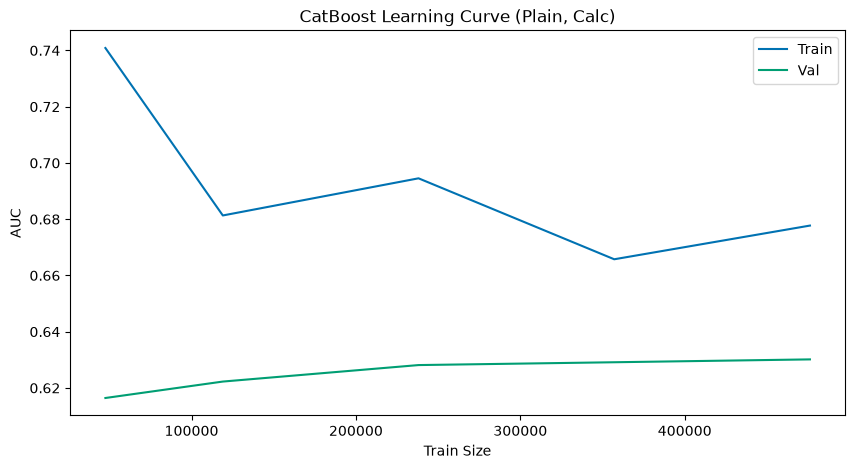

In [229]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["auc_train"], label="Train")
ax.plot(df_sub_results["train_size"], df_sub_results["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("CatBoost Learning Curve (Plain, Calc)")

Text(0.5, 1.0, 'Trainingszeit per Datenmenge (Plain, Calc)')

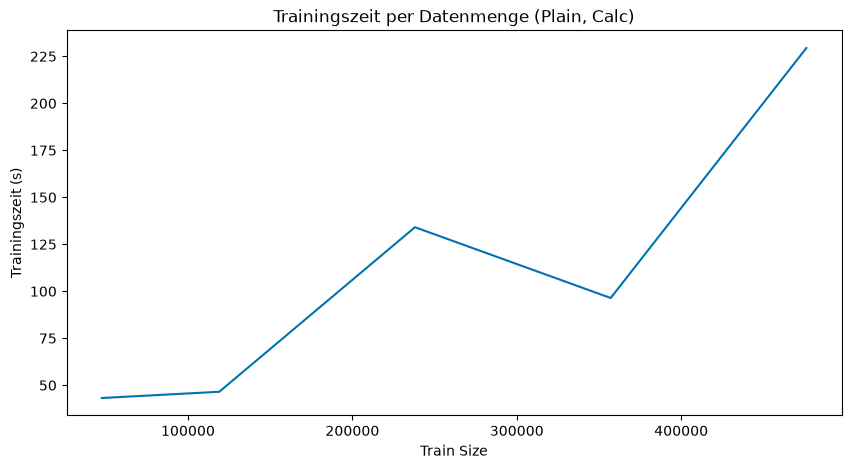

In [230]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["fit_time"])
ax.set_xlabel("Train Size")
ax.set_ylabel("Trainingszeit (s)")
ax.set_title("Trainingszeit per Datenmenge (Plain, Calc)")

## Ordered, fixed with calc

In [231]:
setsizes = [0.1 ,0.25, 0.5, 0.75, 1.0]
sub_results = []
rng = np.random.default_rng(RANDOM_STATE)

for trainset in setsizes:
    n = int(len(x_train_cb) * trainset)
    idx_sub = rng.permutation(len(x_train_cb))[:n]
    x_sub, y_sub = x_train_cb.iloc[idx_sub], y_train.iloc[idx_sub]

    model = CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        eval_metric="AUC",
        thread_count=-1,
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        loss_function="Logloss",
        verbose=250,
        iterations=5000,
        boosting_type="Ordered"
        )

    start = time.time()
    model.fit(
        x_sub, y_sub,
        eval_set=[(x_val_cb, y_val)],
        verbose=False
        )
    fit_time = time.time() - start

    sub_results.append({
        "train_size": n,
        "anteil": trainset,
        "best_iter": model.get_best_iteration(),
        "auc_train": roc_auc_score(y_sub, model.predict_proba(x_sub)[:, 1]),
        "auc_val": roc_auc_score(y_val, model.predict_proba(x_val_cb)[:, 1]),
        "fit_time": fit_time
    })

df_sub_results = pd.DataFrame(sub_results)
df_sub_results

,train_size,anteil,best_iter,auc_train,auc_val,fit_time
0,47616,0.10,357,0.701423,0.615425,48.720130
1,119042,0.25,551,0.707119,0.624742,136.880781
2,238084,0.50,423,0.673474,0.623764,154.081631
3,357126,0.75,334,0.660404,0.625658,143.613596
4,476168,1.00,474,0.668067,0.628323,304.495982


Text(0.5, 1.0, 'CatBoost Learning Curve (Ordered, Calc)')

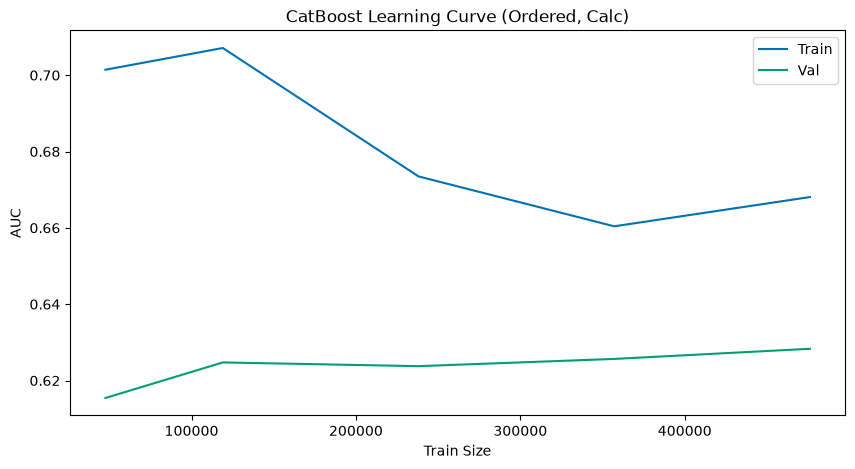

In [232]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["auc_train"], label="Train")
ax.plot(df_sub_results["train_size"], df_sub_results["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("CatBoost Learning Curve (Ordered, Calc)")

Text(0.5, 1.0, 'Trainingszeit per Datenmenge (Ordered, Calc)')

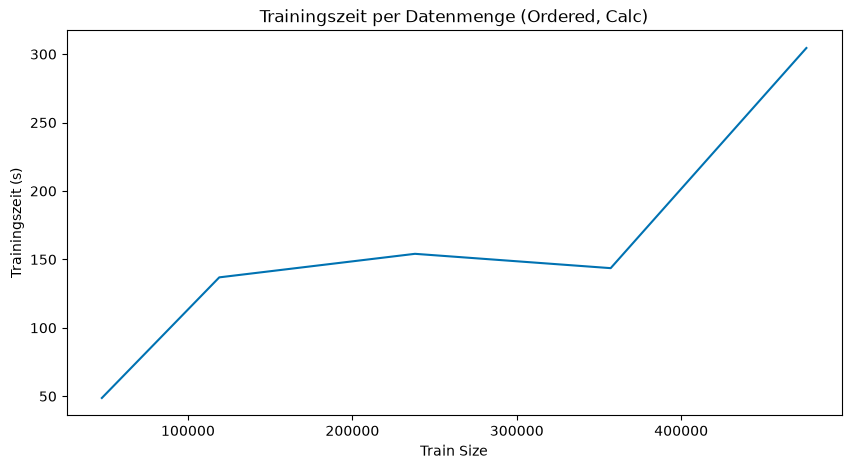

In [233]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["fit_time"])
ax.set_xlabel("Train Size")
ax.set_ylabel("Trainingszeit (s)")
ax.set_title("Trainingszeit per Datenmenge (Ordered, Calc)")

## Plain, fixed, without calc

In [234]:
setsizes = [0.1 ,0.25, 0.5, 0.75, 1.0]
sub_results = []
rng = np.random.default_rng(RANDOM_STATE)

for trainset in setsizes:
    n = int(len(x_train_no_calc_cb) * trainset)
    idx_sub = rng.permutation(len(x_train_no_calc_cb))[:n]
    x_sub, y_sub = x_train_no_calc_cb.iloc[idx_sub], y_train.iloc[idx_sub]

    model = CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        eval_metric="AUC",
        thread_count=-1,
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        loss_function="Logloss",
        verbose=250,
        iterations=5000,
        boosting_type="Plain"
        )

    start = time.time()
    model.fit(
        x_sub, y_sub,
        eval_set=[(x_val_no_calc_cb, y_val)],
        verbose=False
        )
    fit_time = time.time() - start

    sub_results.append({
        "train_size": n,
        "anteil": trainset,
        "best_iter": model.get_best_iteration(),
        "auc_train": roc_auc_score(y_sub, model.predict_proba(x_sub)[:, 1]),
        "auc_val": roc_auc_score(y_val, model.predict_proba(x_val_no_calc_cb)[:, 1]),
        "fit_time": fit_time
    })

df_sub_results = pd.DataFrame(sub_results)
df_sub_results

,train_size,anteil,best_iter,auc_train,auc_val,fit_time
0,47616,0.10,325,0.695519,0.616447,32.690189
1,119042,0.25,322,0.671144,0.624002,47.292840
2,238084,0.50,659,0.675458,0.627985,119.471966
3,357126,0.75,452,0.663582,0.628434,114.168244
4,476168,1.00,387,0.659716,0.630820,134.830453


Text(0.5, 1.0, 'CatBoost Learning Curve (Plain, No Calc)')

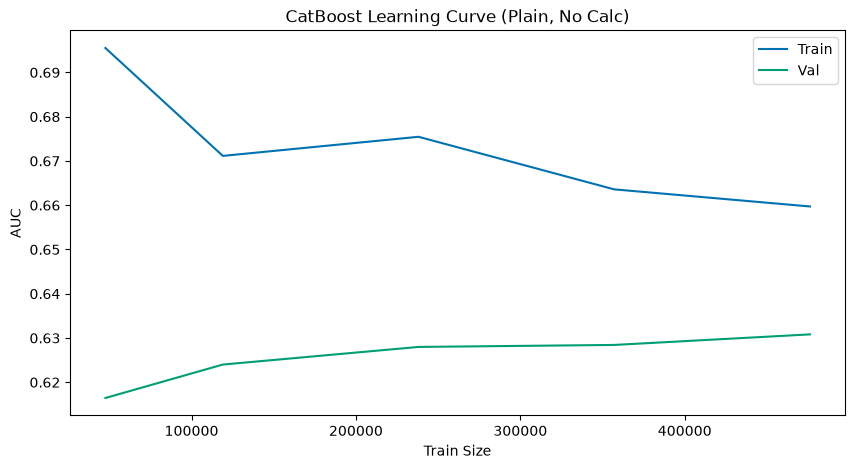

In [235]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["auc_train"], label="Train")
ax.plot(df_sub_results["train_size"], df_sub_results["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("CatBoost Learning Curve (Plain, No Calc)")

Text(0.5, 1.0, 'Trainingszeit per Datenmenge (Plain, No Calc)')

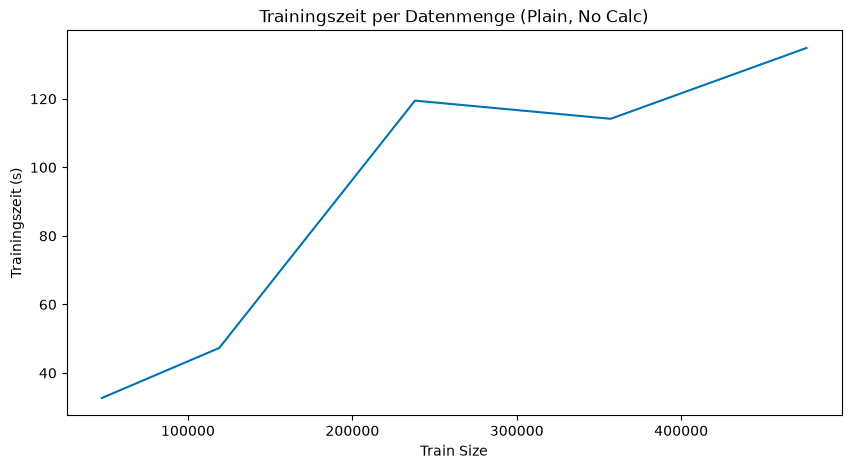

In [236]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["fit_time"])
ax.set_xlabel("Train Size")
ax.set_ylabel("Trainingszeit (s)")
ax.set_title("Trainingszeit per Datenmenge (Plain, No Calc)")

## Ordered, fixed, without calc

In [237]:
setsizes = [0.1 ,0.25, 0.5, 0.75, 1.0]
sub_results = []
rng = np.random.default_rng(RANDOM_STATE)

for trainset in setsizes:
    n = int(len(x_train_no_calc_cb) * trainset)
    idx_sub = rng.permutation(len(x_train_no_calc_cb))[:n]
    x_sub, y_sub = x_train_no_calc_cb.iloc[idx_sub], y_train.iloc[idx_sub]

    model = CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        eval_metric="AUC",
        thread_count=-1,
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        loss_function="Logloss",
        verbose=250,
        iterations=5000,
        boosting_type="Ordered"
        )

    start = time.time()
    model.fit(
        x_sub, y_sub,
        eval_set=[(x_val_no_calc_cb, y_val)],
        verbose=False
        )
    fit_time = time.time() - start

    sub_results.append({
        "train_size": n,
        "anteil": trainset,
        "best_iter": model.get_best_iteration(),
        "auc_train": roc_auc_score(y_sub, model.predict_proba(x_sub)[:, 1]),
        "auc_val": roc_auc_score(y_val, model.predict_proba(x_val_no_calc_cb)[:, 1]),
        "fit_time": fit_time
    })

df_sub_results = pd.DataFrame(sub_results)
df_sub_results

,train_size,anteil,best_iter,auc_train,auc_val,fit_time
0,47616,0.10,369,0.684705,0.619216,45.217365
1,119042,0.25,408,0.673125,0.624942,98.310907
2,238084,0.50,627,0.671372,0.626553,211.063225
3,357126,0.75,636,0.672482,0.629918,243.162719
4,476168,1.00,1017,0.669763,0.632087,617.837217


Text(0.5, 1.0, 'CatBoost Learning Curve (Ordered, No Calc)')

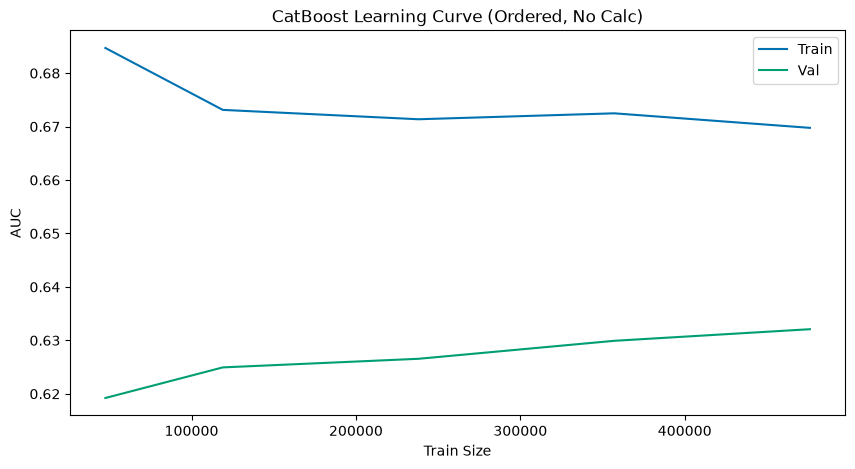

In [238]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["auc_train"], label="Train")
ax.plot(df_sub_results["train_size"], df_sub_results["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("CatBoost Learning Curve (Ordered, No Calc)")

Text(0.5, 1.0, 'Trainingszeit per Datenmenge (Ordered, No Calc)')

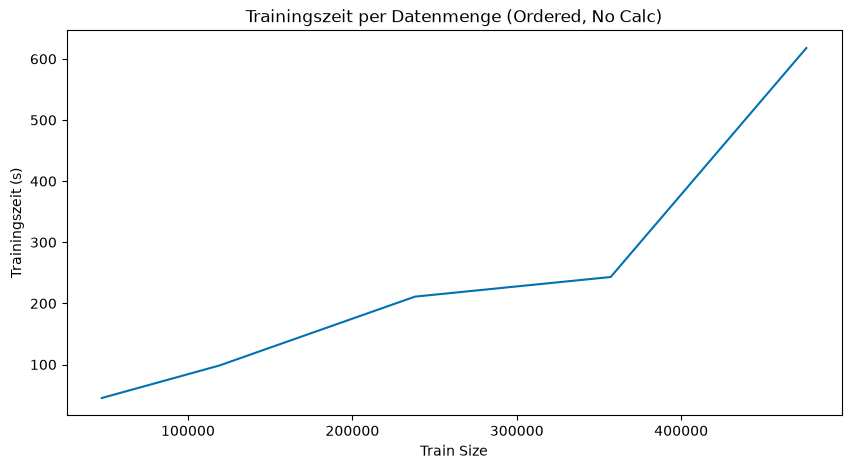

In [239]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["fit_time"])
ax.set_xlabel("Train Size")
ax.set_ylabel("Trainingszeit (s)")
ax.set_title("Trainingszeit per Datenmenge (Ordered, No Calc)")

# Notebook 12
Quelle: 12_CatBoost_Opti_1.ipynb

In [240]:
x_train_cb = mv_for_cb(x_train)
x_val_cb = mv_for_cb(x_val)
x_test_cb = mv_for_cb(x_test)
x_full_cb = mv_for_cb(x_full)
x_train_val_cb = mv_for_cb(x_train_val)

x_train_no_calc_cb = x_train_cb[feat_cols_no_calc]
x_val_no_calc_cb = x_val_cb[feat_cols_no_calc]
x_test_no_calc_cb = x_test_cb[feat_cols_no_calc]
x_full_no_calc_cb = x_full_cb[feat_cols_no_calc]
x_train_val_no_calc_cb = x_train_val_cb[feat_cols_no_calc]

pd.Series(
    {
        "train": [len(x_train_cb), len(x_train_no_calc_cb)],
        "val": [len(x_val_cb), len(x_val_no_calc_cb)],
        "test": [len(x_test_cb), len(x_test_no_calc_cb)],
        "full": [len(x_full_cb), len(x_full_no_calc_cb)],
        "train_val": [len(x_train_val_cb), len(x_train_val_no_calc_cb)]
    }
)

train        [476168, 476168]
val            [59522, 59522]
test           [59522, 59522]
full         [595212, 595212]
train_val    [535690, 535690]
dtype: object

In [241]:
def subsample(x_set, y_set, anteil, random_state=RANDOM_STATE):
    """Subsample erzeugen"""
    if anteil >= 1.0:
        return x_set, y_set
    rng = np.random.default_rng(random_state)
    n = int(len(x_set) * anteil)
    idx_sub = rng.permutation(len(x_set))[:n]
    return x_set.iloc[idx_sub], y_set.iloc[idx_sub]

In [242]:
x_sub_75, y_sub_75 = subsample(x_train_cb, y_train, 0.75)
x_sub_no_calc_75, y_sub_no_calc_75 = subsample(x_train_no_calc_cb, y_train, 0.75)

pd.Series(
    {
        "sub": len(x_sub_75),
        "sub no calc": len(x_sub_no_calc_75),
        "anteil target": y_sub_75.mean()
    }
)

sub              357126.0000
sub no calc      357126.0000
anteil target         0.0365
dtype: float64

## Optuna Hilfe

## Suchräume

|Paramerter|Bereich|
|---|---|
|learning rate|0.01-0.3|
|depth|4-10|
|l2_leaf_reg|1-30|
|random_strength|1e3-10|
|bootstrap_type|Bayesian / Bernoulli / MVS|
|bagging_temperature|0-5|
|one_hot_max_size|2-105|
|leaf_estimation_iterations|1-10|
|auto_class_weights|none / Balanced|

In [243]:
fixed_params_plain = {
    "random_seed": RANDOM_STATE,
    "task_type": "CPU",
    "eval_metric": "AUC",
    "thread_count": -1,
    "allow_writing_files": False,
    "cat_features": cat_cols,
    "use_best_model": True,
    "early_stopping_rounds": 100,
    "loss_function": "Logloss",
    "border_count": 254,
    "verbose": 0,
    "iterations": 5000,
    "boosting_type": "Plain"
}

In [244]:
fixed_params_ordered = {
    "random_seed": RANDOM_STATE,
    "task_type": "CPU",
    "eval_metric": "AUC",
    "thread_count": -1,
    "allow_writing_files": False,
    "cat_features": cat_cols,
    "use_best_model": True,
    "early_stopping_rounds": 100,
    "loss_function": "Logloss",
    "border_count": 254,
    "verbose": 0,
    "iterations": 5000,
    "boosting_type": "Ordered"
}

In [245]:
def suchraum_params(trial):
    """Suchraum definition"""
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 30.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        "one_hot_max_size": trial.suggest_categorical("one_hot_max_size", [2, 10, 18, 105]),
        "leaf_estimation_iterations": trial.suggest_int("leaf_estimation_iterations", 1, 10),
        "auto_class_weights": trial.suggest_categorical("auto_class_weights", [None, "Balanced"]),
        "bootstrap_type": trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli", "MVS"])
    }

    if params["bootstrap_type"] == "Bayesian":
        params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0.0, 5.0)
    else:
        params["subsample"] = trial.suggest_float("subsample", 0.5, 1.0)

    return params

## Plain mit Calc

In [246]:
def objective_plain_calc(trial):
    modell = CatBoostClassifier(
        **fixed_params_plain,
        **suchraum_params(trial)
    )
    pruning_callback = CatBoostPruningCallback(trial, "AUC")

    modell.fit(x_sub_75, y_sub_75, eval_set=[(x_val_cb, y_val)], callbacks=[pruning_callback])
    pruning_callback.check_pruned()

    return roc_auc_score(y_val, modell.predict_proba(x_val_cb)[:, 1])

In [247]:
# study_plain_with_calc = optuna.create_study(
#     study_name = "CatBoost_Plain_with_calc",
#     storage = "sqlite:///catboost_opti.db",
#     load_if_exists = True,
#     direction = "maximize",
#     sampler = TPESampler(seed=RANDOM_STATE),
#     pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=200)
# )

In [248]:
# study_plain_with_calc.optimize(
#     objective_plain_calc,
#     n_trials = 50,
#     timeout = 3*60*60,
#     catch = (Exception, )
# )

In [249]:
study_plain_with_calc = optuna.load_study(
    study_name = "CatBoost_Plain_with_calc",
    storage = "sqlite:///catboost_opti.db"
)

In [250]:
pd.DataFrame({
    "best auc_val": study_plain_with_calc.best_value,
    "best gini": 2 * study_plain_with_calc.best_value - 1,
    "trials": len(study_plain_with_calc.trials),
    "pruned": len([t for t in study_plain_with_calc.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_plain_with_calc.trials if t.state.name == "FAIL"]),
    "best params": study_plain_with_calc.best_params
})

,best auc_val,best gini,trials,pruned,fail,best params
learning_rate,0.634441,0.268881,50,14,0,0.047611
depth,0.634441,0.268881,50,14,0,7
l2_leaf_reg,0.634441,0.268881,50,14,0,8.593733
random_strength,0.634441,0.268881,50,14,0,0.011423
one_hot_max_size,0.634441,0.268881,50,14,0,105
leaf_estimation_iterations,0.634441,0.268881,50,14,0,2
auto_class_weights,0.634441,0.268881,50,14,0,Balanced
bootstrap_type,0.634441,0.268881,50,14,0,Bernoulli
subsample,0.634441,0.268881,50,14,0,0.917857


## Plain ohne Calc

In [251]:
def objective_plain_no_calc(trial):
    modell = CatBoostClassifier(
        **fixed_params_plain,
        **suchraum_params(trial)
    )
    pruning_callback = CatBoostPruningCallback(trial, "AUC")

    modell.fit(x_sub_no_calc_75, y_sub_75, eval_set=[(x_val_no_calc_cb, y_val)], callbacks=[pruning_callback])
    pruning_callback.check_pruned()

    return roc_auc_score(y_val, modell.predict_proba(x_val_no_calc_cb)[:, 1])

In [252]:
# study_plain_without_calc = optuna.create_study(
#     study_name = "CatBoost_Plain_without_calc",
#     storage = "sqlite:///catboost_opti.db",
#     load_if_exists = True,
#     direction = "maximize",
#     sampler = TPESampler(seed=RANDOM_STATE),
#     pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=200)
# )

In [253]:
# study_plain_without_calc.optimize(
#     objective_plain_no_calc,
#     n_trials = 50,
#     timeout = 3*60*60,
#     catch = (Exception, )
# )

In [254]:
study_plain_without_calc = optuna.load_study(
    study_name = "CatBoost_Plain_without_calc",
    storage = "sqlite:///catboost_opti.db"
)

In [255]:
pd.Series({
    "best auc_val": study_plain_without_calc.best_value,
    "best gini": 2 * study_plain_without_calc.best_value - 1,
    "trials": len(study_plain_without_calc.trials),
    "pruned": len([t for t in study_plain_without_calc.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_plain_without_calc.trials if t.state.name == "FAIL"]),
    "best params": study_plain_without_calc.best_params
})

best auc_val                                             0.634627
best gini                                                0.269254
trials                                                         67
pruned                                                         29
fail                                                            0
best params     {'learning_rate': 0.17595817710624895, 'depth'...
dtype: object

In [256]:
study_plain_without_calc.best_params

{'learning_rate': 0.17595817710624895,
 'depth': 4,
 'l2_leaf_reg': 3.9143184149527266,
 'random_strength': 0.5015455446392323,
 'one_hot_max_size': 10,
 'leaf_estimation_iterations': 2,
 'auto_class_weights': None,
 'bootstrap_type': 'Bernoulli',
 'subsample': 0.7854715288197278}

## Ordered ohne Calc

In [257]:
def objective_ordered_no_calc(trial):
    modell = CatBoostClassifier(
        **fixed_params_ordered,
        **suchraum_params(trial)
    )
    pruning_callback = CatBoostPruningCallback(trial, "AUC")

    modell.fit(x_sub_no_calc_75, y_sub_75, eval_set=[(x_val_no_calc_cb, y_val)], callbacks=[pruning_callback])
    pruning_callback.check_pruned()

    return roc_auc_score(y_val, modell.predict_proba(x_val_no_calc_cb)[:, 1])

In [258]:
# study_ordered_without_calc = optuna.create_study(
#     study_name = "CatBoost_Ordered_without_calc",
#     storage = "sqlite:///catboost_opti.db",
#     load_if_exists = True,
#     direction = "maximize",
#     sampler = TPESampler(seed=RANDOM_STATE),
#     pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=200)
# )

In [259]:
# study_ordered_without_calc.optimize(
#     objective_ordered_no_calc,
#     n_trials = 50,
#     timeout = 3*60*60,
#     catch = (Exception, )
# )

In [260]:
study_ordered_without_calc = optuna.load_study(
    study_name = "CatBoost_Ordered_without_calc",
    storage = "sqlite:///catboost_opti.db"
)

In [261]:
pd.Series({
    "best auc_val": study_ordered_without_calc.best_value,
    "best gini": 2 * study_ordered_without_calc.best_value - 1,
    "trials": len(study_ordered_without_calc.trials),
    "pruned": len([t for t in study_ordered_without_calc.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_ordered_without_calc.trials if t.state.name == "FAIL"]),
    "best params": study_ordered_without_calc.best_params
})

best auc_val                                             0.633448
best gini                                                0.266896
trials                                                         50
pruned                                                         19
fail                                                            0
best params     {'learning_rate': 0.07522925545685702, 'depth'...
dtype: object

In [262]:
study_ordered_without_calc.best_params

{'learning_rate': 0.07522925545685702,
 'depth': 9,
 'l2_leaf_reg': 21.727358099820517,
 'random_strength': 1.7703555608560753,
 'one_hot_max_size': 10,
 'leaf_estimation_iterations': 3,
 'auto_class_weights': None,
 'bootstrap_type': 'Bayesian',
 'bagging_temperature': 0.0044302304989518315}

## Load Study

In [263]:
study_plain_with_calc_loaded = optuna.load_study(
    study_name = "CatBoost_Plain_with_calc",
    storage = "sqlite:///catboost_opti.db"
)


In [264]:
study_plain_without_calc_loaded = optuna.load_study(
    study_name = "CatBoost_Plain_without_calc",
    storage = "sqlite:///catboost_opti.db"
)

In [265]:
study_ordered_without_calc_loaded = optuna.load_study(
    study_name = "CatBoost_Ordered_without_calc",
    storage = "sqlite:///catboost_opti.db"
)

## Best Params again

In [266]:
study_plain_with_calc_loaded.best_params

{'learning_rate': 0.047611121022996535,
 'depth': 7,
 'l2_leaf_reg': 8.593733349151965,
 'random_strength': 0.011423191447041188,
 'one_hot_max_size': 105,
 'leaf_estimation_iterations': 2,
 'auto_class_weights': 'Balanced',
 'bootstrap_type': 'Bernoulli',
 'subsample': 0.9178574821162729}

In [267]:
study_plain_without_calc_loaded.best_params

{'learning_rate': 0.17595817710624895,
 'depth': 4,
 'l2_leaf_reg': 3.9143184149527266,
 'random_strength': 0.5015455446392323,
 'one_hot_max_size': 10,
 'leaf_estimation_iterations': 2,
 'auto_class_weights': None,
 'bootstrap_type': 'Bernoulli',
 'subsample': 0.7854715288197278}

In [268]:
study_ordered_without_calc_loaded.best_params

{'learning_rate': 0.07522925545685702,
 'depth': 9,
 'l2_leaf_reg': 21.727358099820517,
 'random_strength': 1.7703555608560753,
 'one_hot_max_size': 10,
 'leaf_estimation_iterations': 3,
 'auto_class_weights': None,
 'bootstrap_type': 'Bayesian',
 'bagging_temperature': 0.0044302304989518315}

## 100% Train

In [269]:
results = []
train_times = {}

In [270]:
name = "L_cb_opt_01"

L_cb_opt_01 = CatBoostClassifier(
    **fixed_params_plain,
    **study_plain_with_calc_loaded.best_params
)

start = time.time()
L_cb_opt_01.fit(
    x_train_cb, y_train, 
    eval_set=(x_val_cb, y_val), 
    verbose=250
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_cb_opt_01, x_train_cb, y_train, x_val_cb, y_val, train_times[name], best_iter=L_cb_opt_01.get_best_iteration())
)

0:	test: 0.6037890	best: 0.6037890 (0)	total: 46.2ms	remaining: 3m 50s
250:	test: 0.6320888	best: 0.6323677 (245)	total: 9.24s	remaining: 2m 54s
500:	test: 0.6332904	best: 0.6336649 (478)	total: 17.8s	remaining: 2m 39s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6336873958
bestIteration = 549

Shrink model to first 550 iterations.


In [271]:
name = "L_cb_opt_02"

L_cb_opt_02 = CatBoostClassifier(
    **fixed_params_plain,
    **study_plain_without_calc_loaded.best_params
)

start = time.time()
L_cb_opt_02.fit(
    x_train_no_calc_cb, y_train, 
    eval_set=(x_val_no_calc_cb, y_val), 
    verbose=250
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_cb_opt_02, x_train_no_calc_cb, y_train, x_val_no_calc_cb, y_val, train_times[name], best_iter=L_cb_opt_02.get_best_iteration())
)

0:	test: 0.5382770	best: 0.5382770 (0)	total: 90.6ms	remaining: 7m 32s
250:	test: 0.6316706	best: 0.6316958 (244)	total: 20.8s	remaining: 6m 33s
500:	test: 0.6333197	best: 0.6335711 (459)	total: 41.5s	remaining: 6m 12s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6336871949
bestIteration = 518

Shrink model to first 519 iterations.


In [272]:
name = "L_cb_opt_03"

L_cb_opt_03 = CatBoostClassifier(
    **fixed_params_ordered,
    **study_ordered_without_calc_loaded.best_params
)

start = time.time()
L_cb_opt_03.fit(
    x_train_no_calc_cb, y_train, 
    eval_set=(x_val_no_calc_cb, y_val), 
    verbose=250
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_cb_opt_03, x_train_no_calc_cb, y_train, x_val_no_calc_cb, y_val, train_times[name], best_iter=L_cb_opt_03.get_best_iteration())
)

0:	test: 0.5613484	best: 0.5613484 (0)	total: 520ms	remaining: 43m 19s
250:	test: 0.6284516	best: 0.6284516 (246)	total: 1m 31s	remaining: 28m 55s
500:	test: 0.6295876	best: 0.6296311 (412)	total: 3m 13s	remaining: 28m 53s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6296310739
bestIteration = 412

Shrink model to first 413 iterations.


In [273]:
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_cb_opt_01,0.740788,0.633687,0.267375,0.107101,549,23.208894
1,L_cb_opt_02,0.664717,0.633687,0.267374,0.031030,518,52.306707
2,L_cb_opt_03,0.655782,0.629631,0.259262,0.026151,412,198.631119


## Save Models

In [274]:
Modelle = [
    (L_cb_opt_01, "L_cb_opt_01"),
    (L_cb_opt_02, "L_cb_opt_02"),
    (L_cb_opt_03, "L_cb_opt_03")
]

# for modell, name in Modelle:
#     modell.save_model(f"{name}.cbm")

# Notebook 14
Quelle: 14_CatBoost_Opti_2.ipynb

## Plain mit Calc

In [275]:
def objective_plain_calc_full(trial):
    modell = CatBoostClassifier(
        **fixed_params_plain,
        **suchraum_params(trial)
    )
    pruning_callback = CatBoostPruningCallback(trial, "AUC")

    modell.fit(x_train_cb, y_train, eval_set=[(x_val_cb, y_val)], callbacks=[pruning_callback])
    pruning_callback.check_pruned()

    return roc_auc_score(y_val, modell.predict_proba(x_val_cb)[:, 1])

In [276]:
# study_plain_with_calc_full = optuna.create_study(
#     study_name = "CatBoost_Plain_with_calc_full",
#     storage = "sqlite:///catboost_opti.db",
#     load_if_exists = True,
#     direction = "maximize",
#     sampler = TPESampler(seed=RANDOM_STATE),
#     pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=200)
# )

In [277]:
# study_plain_with_calc_full.optimize(
#     objective_plain_calc_full,
#     n_trials = 50,
#     timeout = 4*60*60,
#     catch = (Exception, )
# )

In [278]:
study_plain_with_calc_full = optuna.load_study(
    study_name = "CatBoost_Plain_with_calc_full",
    storage = "sqlite:///catboost_opti.db"
)

In [279]:
pd.DataFrame({
    "best auc_val": study_plain_with_calc_full.best_value,
    "best gini": 2 * study_plain_with_calc_full.best_value - 1,
    "trials": len(study_plain_with_calc_full.trials),
    "pruned": len([t for t in study_plain_with_calc_full.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_plain_with_calc_full.trials if t.state.name == "FAIL"]),
    "best params": study_plain_with_calc_full.best_params
})

,best auc_val,best gini,trials,pruned,fail,best params
learning_rate,0.633815,0.267629,50,17,0,0.063388
depth,0.633815,0.267629,50,17,0,5
l2_leaf_reg,0.633815,0.267629,50,17,0,2.430517
random_strength,0.633815,0.267629,50,17,0,0.001189
one_hot_max_size,0.633815,0.267629,50,17,0,10
leaf_estimation_iterations,0.633815,0.267629,50,17,0,3
auto_class_weights,0.633815,0.267629,50,17,0,Balanced
bootstrap_type,0.633815,0.267629,50,17,0,Bernoulli
subsample,0.633815,0.267629,50,17,0,0.565753


## Plain ohne Calc

In [280]:
def objective_plain_no_calc_full(trial):
    modell = CatBoostClassifier(
        **fixed_params_plain,
        **suchraum_params(trial)
    )
    pruning_callback = CatBoostPruningCallback(trial, "AUC")

    modell.fit(x_train_no_calc_cb, y_train, eval_set=[(x_val_no_calc_cb, y_val)], callbacks=[pruning_callback])
    pruning_callback.check_pruned()

    return roc_auc_score(y_val, modell.predict_proba(x_val_no_calc_cb)[:, 1])

In [281]:
# study_plain_without_calc_full = optuna.create_study(
#     study_name = "CatBoost_Plain_without_calc_full",
#     storage = "sqlite:///catboost_opti.db",
#     load_if_exists = True,
#     direction = "maximize",
#     sampler = TPESampler(seed=RANDOM_STATE),
#     pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=200)
# )

In [282]:
# study_plain_without_calc_full.optimize(
#     objective_plain_no_calc_full,
#     n_trials = 50,
#     timeout = 4*60*60,
#     catch = (Exception, )
# )

In [283]:
study_plain_without_calc_full = optuna.load_study(
    study_name = "CatBoost_Plain_without_calc_full",
    storage = "sqlite:///catboost_opti.db"
)

In [284]:
pd.Series({
    "best auc_val": study_plain_without_calc_full.best_value,
    "best gini": 2 * study_plain_without_calc_full.best_value - 1,
    "trials": len(study_plain_without_calc_full.trials),
    "pruned": len([t for t in study_plain_without_calc_full.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_plain_without_calc_full.trials if t.state.name == "FAIL"]),
    "best params": study_plain_without_calc_full.best_params
})

best auc_val                                             0.636402
best gini                                                0.272804
trials                                                         50
pruned                                                         29
fail                                                            0
best params     {'learning_rate': 0.05445057683691509, 'depth'...
dtype: object

In [285]:
study_plain_without_calc_full.best_params

{'learning_rate': 0.05445057683691509,
 'depth': 8,
 'l2_leaf_reg': 7.076480471311773,
 'random_strength': 0.8387744815011882,
 'one_hot_max_size': 18,
 'leaf_estimation_iterations': 5,
 'auto_class_weights': None,
 'bootstrap_type': 'Bayesian',
 'bagging_temperature': 1.8158099900059381}

## Ordered ohne Calc

In [286]:
def objective_ordered_no_calc_full(trial):
    modell = CatBoostClassifier(
        **fixed_params_ordered,
        **suchraum_params(trial)
    )
    pruning_callback = CatBoostPruningCallback(trial, "AUC")

    modell.fit(x_train_no_calc_cb, y_train, eval_set=[(x_val_no_calc_cb, y_val)], callbacks=[pruning_callback])
    pruning_callback.check_pruned()

    return roc_auc_score(y_val, modell.predict_proba(x_val_no_calc_cb)[:, 1])

In [287]:
# study_ordered_without_calc_full = optuna.create_study(
#     study_name = "CatBoost_Ordered_without_calc_full",
#     storage = "sqlite:///catboost_opti.db",
#     load_if_exists = True,
#     direction = "maximize",
#     sampler = TPESampler(seed=RANDOM_STATE),
#     pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=200)
# )

In [288]:
# study_ordered_without_calc_full.optimize(
#     objective_ordered_no_calc_full,
#     n_trials = 50,
#     timeout = 4*60*60,
#     catch = (Exception, )
# )

In [289]:
study_ordered_without_calc_full = optuna.load_study(
    study_name = "CatBoost_Ordered_without_calc_full",
    storage = "sqlite:///catboost_opti.db"
)

In [290]:
pd.Series({
    "best auc_val": study_ordered_without_calc_full.best_value,
    "best gini": 2 * study_ordered_without_calc_full.best_value - 1,
    "trials": len(study_ordered_without_calc_full.trials),
    "pruned": len([t for t in study_ordered_without_calc_full.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_ordered_without_calc_full.trials if t.state.name == "FAIL"]),
    "best params": study_ordered_without_calc_full.best_params
})

best auc_val                                             0.635504
best gini                                                0.271008
trials                                                         50
pruned                                                         19
fail                                                            0
best params     {'learning_rate': 0.10624277494598432, 'depth'...
dtype: object

In [291]:
study_ordered_without_calc_full.best_params

{'learning_rate': 0.10624277494598432,
 'depth': 7,
 'l2_leaf_reg': 18.039747295507677,
 'random_strength': 0.005187373722068937,
 'one_hot_max_size': 105,
 'leaf_estimation_iterations': 1,
 'auto_class_weights': None,
 'bootstrap_type': 'Bernoulli',
 'subsample': 0.8119454704358904}

## Load Study

In [292]:
study_plain_with_calc_full_loaded = optuna.load_study(
    study_name = "CatBoost_Plain_with_calc_full",
    storage = "sqlite:///catboost_opti.db"
)


In [293]:
study_plain_without_calc_full_loaded = optuna.load_study(
    study_name = "CatBoost_Plain_without_calc_full",
    storage = "sqlite:///catboost_opti.db"
)

In [294]:
study_ordered_without_calc_full_loaded = optuna.load_study(
    study_name = "CatBoost_Ordered_without_calc_full",
    storage = "sqlite:///catboost_opti.db"
)

## Best Params again

In [295]:
study_plain_with_calc_full_loaded.best_params

{'learning_rate': 0.06338750302989393,
 'depth': 5,
 'l2_leaf_reg': 2.430516929648288,
 'random_strength': 0.0011888525233311397,
 'one_hot_max_size': 10,
 'leaf_estimation_iterations': 3,
 'auto_class_weights': 'Balanced',
 'bootstrap_type': 'Bernoulli',
 'subsample': 0.5657526432159653}

In [296]:
study_plain_without_calc_full_loaded.best_params

{'learning_rate': 0.05445057683691509,
 'depth': 8,
 'l2_leaf_reg': 7.076480471311773,
 'random_strength': 0.8387744815011882,
 'one_hot_max_size': 18,
 'leaf_estimation_iterations': 5,
 'auto_class_weights': None,
 'bootstrap_type': 'Bayesian',
 'bagging_temperature': 1.8158099900059381}

In [297]:
study_ordered_without_calc_full_loaded.best_params

{'learning_rate': 0.10624277494598432,
 'depth': 7,
 'l2_leaf_reg': 18.039747295507677,
 'random_strength': 0.005187373722068937,
 'one_hot_max_size': 105,
 'leaf_estimation_iterations': 1,
 'auto_class_weights': None,
 'bootstrap_type': 'Bernoulli',
 'subsample': 0.8119454704358904}

## 100% Train

In [298]:
results = []
train_times = {}

In [299]:
name = "L_cb_opt_01_full"

L_cb_opt_01_full = CatBoostClassifier(
    **fixed_params_plain,
    **study_plain_with_calc_full_loaded.best_params
)

start = time.time()
L_cb_opt_01_full.fit(
    x_train_cb, y_train, 
    eval_set=(x_val_cb, y_val), 
    verbose=250
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_cb_opt_01_full, x_train_cb, y_train, x_val_cb, y_val, train_times[name], best_iter=L_cb_opt_01_full.get_best_iteration())
)

0:	test: 0.5920158	best: 0.5920158 (0)	total: 124ms	remaining: 10m 20s
250:	test: 0.6296309	best: 0.6298320 (236)	total: 27.4s	remaining: 8m 39s
500:	test: 0.6333300	best: 0.6333876 (474)	total: 54.3s	remaining: 8m 7s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.63381464
bestIteration = 623

Shrink model to first 624 iterations.


In [300]:
name = "L_cb_opt_02_full"

L_cb_opt_02_full = CatBoostClassifier(
    **fixed_params_plain,
    **study_plain_without_calc_full_loaded.best_params
)

start = time.time()
L_cb_opt_02_full.fit(
    x_train_no_calc_cb, y_train, 
    eval_set=(x_val_no_calc_cb, y_val), 
    verbose=250
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_cb_opt_02_full, x_train_no_calc_cb, y_train, x_val_no_calc_cb, y_val, train_times[name], best_iter=L_cb_opt_02_full.get_best_iteration())
)

0:	test: 0.5655829	best: 0.5655829 (0)	total: 163ms	remaining: 13m 36s
250:	test: 0.6320901	best: 0.6320901 (250)	total: 39.3s	remaining: 12m 22s
500:	test: 0.6358414	best: 0.6360036 (494)	total: 1m 18s	remaining: 11m 41s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6364019991
bestIteration = 558

Shrink model to first 559 iterations.


In [301]:
name = "L_cb_opt_03_full"

L_cb_opt_03_full = CatBoostClassifier(
    **fixed_params_ordered,
    **study_ordered_without_calc_full_loaded.best_params
)

start = time.time()
L_cb_opt_03_full.fit(
    x_train_no_calc_cb, y_train, 
    eval_set=(x_val_no_calc_cb, y_val), 
    verbose=250
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_cb_opt_03_full, x_train_no_calc_cb, y_train, x_val_no_calc_cb, y_val, train_times[name], best_iter=L_cb_opt_03_full.get_best_iteration())
)

0:	test: 0.5575105	best: 0.5575105 (0)	total: 85ms	remaining: 7m 5s
250:	test: 0.6324803	best: 0.6324939 (249)	total: 33s	remaining: 10m 24s
500:	test: 0.6345583	best: 0.6345583 (500)	total: 1m 6s	remaining: 9m 56s
750:	test: 0.6352451	best: 0.6353866 (732)	total: 1m 39s	remaining: 9m 23s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6355038302
bestIteration = 789

Shrink model to first 790 iterations.


In [302]:
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_cb_opt_01_full,0.696718,0.633815,0.267629,0.062904,623,79.965863
1,L_cb_opt_02_full,0.692775,0.636402,0.272804,0.056373,558,103.153275
2,L_cb_opt_03_full,0.685571,0.635504,0.271008,0.050067,789,118.146594


## Save Models

In [303]:
Modelle = [
    (L_cb_opt_01_full, "L_cb_opt_01_full"),
    (L_cb_opt_02_full, "L_cb_opt_02_full"),
    (L_cb_opt_03_full, "L_cb_opt_03_full")
]

# for modell, name in Modelle:
#     modell.save_model(f"{name}.cbm")

# Notebook 16
Quelle: 16_PCA.ipynb

In [304]:
results = []
train_times = {}

In [305]:
def eval_modell(mod_idx, model, x_train, y_train, x_val, y_val, train_time, best_iter=None):
    """AUC auf Train und Val"""
    auc_train = roc_auc_score(y_train, model.predict_proba(x_train)[:, 1])
    auc_val = roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    return {
        "model_idx": mod_idx,
        "auc_train": auc_train,
        "auc_test": auc_val,
        "gini": 2 * auc_val - 1,
        "delta_auc": auc_train - auc_val,
        "best_iter": best_iter,
        "trainingszeit": train_time
    }

## Encoding

In [306]:
one_hot_prep = make_column_transformer(
    (SimpleImputer(strategy="median"), num_cols_no_calc),
    (OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"), cat_cols),
    ("passthrough", bin_cols_no_calc)
)

In [307]:
target_enc_prep = make_column_transformer(
    (SimpleImputer(strategy="median"), num_cols_no_calc),
    (OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"), low_kard_cols),
    (TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE), high_kard_cols),
    ("passthrough", bin_cols_no_calc)
)

In [308]:
x_train_one_hot = one_hot_prep.fit_transform(x_train[feat_cols_no_calc])
x_val_one_hot = one_hot_prep.transform(x_val[feat_cols_no_calc])

x_train_targ = target_enc_prep.fit_transform(x_train[feat_cols_no_calc], y_train)
x_val_targ = target_enc_prep.transform(x_val[feat_cols_no_calc])

pd.Series({
    "feats raw": len(feat_cols_no_calc),
    "cols nach one hot": x_train_one_hot.shape[1],
    "cols nach target enc": x_train_targ.shape[1],
})

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


feats raw                37
cols nach one hot       193
cols nach target enc     91
dtype: int64

## Scaling

In [309]:
scalers = {
    "ohne scaler": None,
    "minmax": MinMaxScaler(),
    "standard": StandardScaler()
}

In [310]:
pca_vergleich = {}

for name, scaler in scalers.items():
    steps = [PCA(n_components=30, random_state=RANDOM_STATE)]
    if scaler is not None:
        steps.insert(0, scaler)
    pipe = make_pipeline(
        *steps
    ).fit(x_train_one_hot)
    pca_vergleich[name] = pipe["pca"]

In [311]:
df_scaler_pca = pd.DataFrame({
    name : p.explained_variance_ratio_.cumsum() for name, p in pca_vergleich.items()
})

df_scaler_pca

,ohne scaler,minmax,standard
0,0.422909,0.095769,0.027187
1,0.650959,0.164716,0.044595
2,0.766542,0.228844,0.059726
3,0.792190,0.280353,0.074111
4,0.812779,0.327908,0.086941
5,0.828681,0.366056,0.099515
6,0.841413,0.400597,0.111882
7,0.853737,0.434609,0.124024
8,0.863366,0.464729,0.135978
9,0.871751,0.492624,0.147315


In [312]:
df_scaler_pca.index = range(1, 31)
df_scaler_pca

,ohne scaler,minmax,standard
1,0.422909,0.095769,0.027187
2,0.650959,0.164716,0.044595
3,0.766542,0.228844,0.059726
4,0.792190,0.280353,0.074111
5,0.812779,0.327908,0.086941
6,0.828681,0.366056,0.099515
7,0.841413,0.400597,0.111882
8,0.853737,0.434609,0.124024
9,0.863366,0.464729,0.135978
10,0.871751,0.492624,0.147315


Text(0.5, 0.98, 'Scaler Effekt auf PCA')

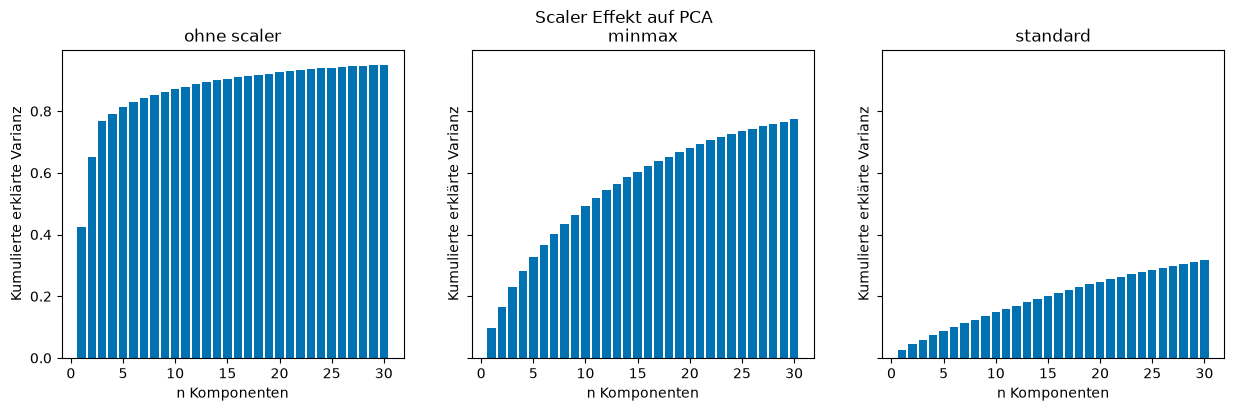

In [313]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (name, p) in zip(axes, pca_vergleich.items()):
    ax.bar(range(1,31), p.explained_variance_ratio_.cumsum())
    ax.set_title(name)
    ax.set_xlabel("n Komponenten")
    ax.set_ylabel("Kumulierte erklärte Varianz")

fig.suptitle("Scaler Effekt auf PCA")

## Erklärte Varianz

In [314]:
mm_scaler = MinMaxScaler().fit(x_train_one_hot)

x_train_scale = mm_scaler.transform(x_train_one_hot)
x_val_scale = mm_scaler.transform(x_val_one_hot)

pca_voll = PCA(n_components=None, random_state=RANDOM_STATE).fit(x_train_scale)

erk_var = pca_voll.explained_variance_ratio_
erk_var_cum = erk_var.cumsum()

pd.Series({
    f"{ant} Varianz": int(np.searchsorted(erk_var_cum, ant) + 1) for ant in (0.5, 0.8, 0.9, 0.95, 0.99)
}
|
{
    "Komponenten gesamt": len(erk_var)
})

0.5 Varianz            11
0.8 Varianz            35
0.9 Varianz            62
0.95 Varianz           93
0.99 Varianz          143
Komponenten gesamt    193
dtype: int64

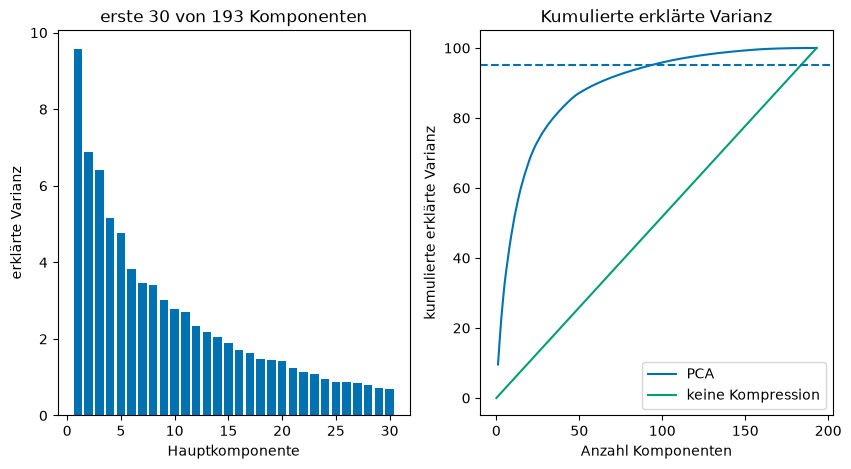

In [315]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].bar(range(1,31), erk_var[:30] * 100)
axes[0].set_xlabel("Hauptkomponente")
axes[0].set_ylabel("erklärte Varianz")
axes[0].set_title(f"erste 30 von {len(erk_var)} Komponenten")

axes[1].plot(range(1, len(erk_var_cum) + 1), erk_var_cum * 100, label="PCA")
axes[1].plot([0, len(erk_var_cum)], [0, 100], label="keine Kompression")
axes[1].axhline(95, linestyle="--")
axes[1].set_xlabel("Anzahl Komponenten")
axes[1].set_ylabel("kumulierte erklärte Varianz")
axes[1].set_title("Kumulierte erklärte Varianz")
axes[1].legend()

## Projektion

In [316]:
rng = np.random.default_rng(RANDOM_STATE)
idx_plot = rng.choice(len(x_train_scale), int(0.1 * len(x_train_scale)), replace=False)

pc = pca_voll.transform(x_train_scale[idx_plot])[:,:2]
y_plot = y_train.to_numpy()[idx_plot]

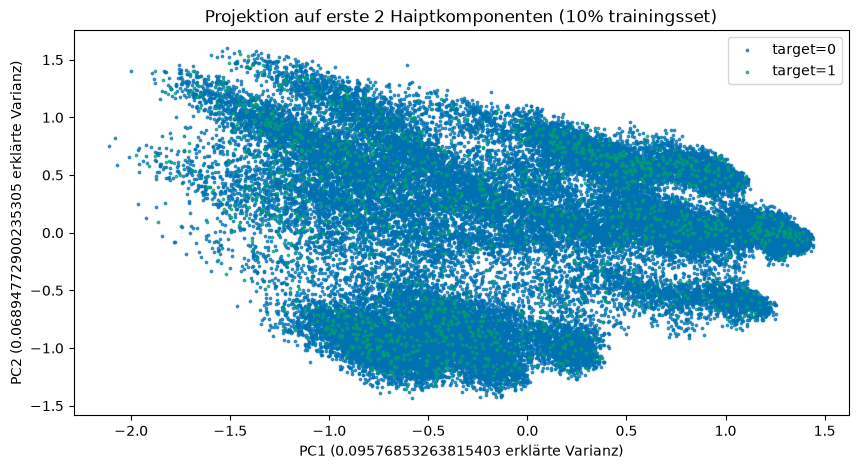

In [317]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(*pc[~y_plot].T, label="target=0", s=3, alpha=0.7)
ax.scatter(*pc[y_plot].T, label="target=1", s=3, alpha=0.7)
ax.set_xlabel(f"PC1 ({erk_var[0]} erklärte Varianz)")
ax.set_ylabel(f"PC2 ({erk_var[1]} erklärte Varianz)")
ax.set_title("Projektion auf erste 2 Haiptkomponenten (10% trainingsset)")
ax.legend()

## Logreg test

In [318]:
scaler_targ = MinMaxScaler().fit(x_train_targ)
x_train_targ_scale = scaler_targ.transform(x_train_targ)
x_val_targ_scale = scaler_targ.transform(x_val_targ)

In [319]:
start = time.time()
L_lr_targ = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
).fit(x_train_targ_scale, y_train)
train_times["L_lr_targ"] = time.time() - start

results.append(
    eval_modell("L_lr_targ", L_lr_targ, x_train_targ_scale, y_train, x_val_targ_scale, y_val, train_times["L_lr_targ"])
)

In [320]:
start = time.time()
L_lr_one_hot = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
).fit(x_train_scale, y_train)
train_times["L_lr_one_hot"] = time.time() - start

results.append(
    eval_modell("L_lr_one_hot", L_lr_one_hot, x_train_scale, y_train, x_val_scale, y_val, train_times["L_lr_one_hot"])
)

In [321]:
pd.DataFrame(results)

,model_idx,auc_train,auc_test,gini,delta_auc,best_iter,trainingszeit
0,L_lr_targ,0.633128,0.616282,0.232564,0.016846,None,2.766404
1,L_lr_one_hot,0.634850,0.614756,0.229512,0.020094,None,3.348317


In [322]:
pca_all = PCA(n_components=None, random_state=RANDOM_STATE)

x_train_pca = pca_all.fit_transform(x_train_scale)
x_val_pca = pca_all.transform(x_val_scale)

x_train_pca.shape

(476168, 193)

In [323]:
m_list = [2, 5, 10, 20, 30, 50, 75, 100, 150]

sweep = []

for m in m_list:
    start = time.time()
    modell = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ).fit(x_train_pca[:, :m], y_train)
    train_time = time.time() - start

    row = eval_modell(f"L_lr_pca_{m}", modell, x_train_pca[:, :m], y_train, x_val_pca[:, :m], y_val, train_time)
    row["m"] = m
    row["erklärte Var"] = pca_all.explained_variance_ratio_.cumsum()[m-1]
    sweep.append(row)

df_sweep = pd.DataFrame(sweep)
df_sweep

,model_idx,auc_train,auc_test,gini,delta_auc,best_iter,trainingszeit,m,erklärte Var
0,L_lr_pca_2,0.580502,0.569519,0.139038,0.010983,None,0.169033,2,0.164716
1,L_lr_pca_5,0.593346,0.580505,0.161009,0.012842,None,0.211757,5,0.327908
2,L_lr_pca_10,0.597185,0.582985,0.165970,0.014199,None,0.235311,10,0.492624
3,L_lr_pca_20,0.610511,0.591724,0.183448,0.018787,None,0.263213,20,0.681291
4,L_lr_pca_30,0.614498,0.599619,0.199238,0.014879,None,0.361236,30,0.773249
5,L_lr_pca_50,0.626356,0.614026,0.228053,0.012330,None,0.700758,50,0.871571
6,L_lr_pca_75,0.628866,0.613571,0.227142,0.015295,None,1.142963,75,0.925437
7,L_lr_pca_100,0.631582,0.615050,0.230099,0.016533,None,1.268167,100,0.958785
8,L_lr_pca_150,0.633869,0.615432,0.230864,0.018437,None,1.715410,150,0.993089


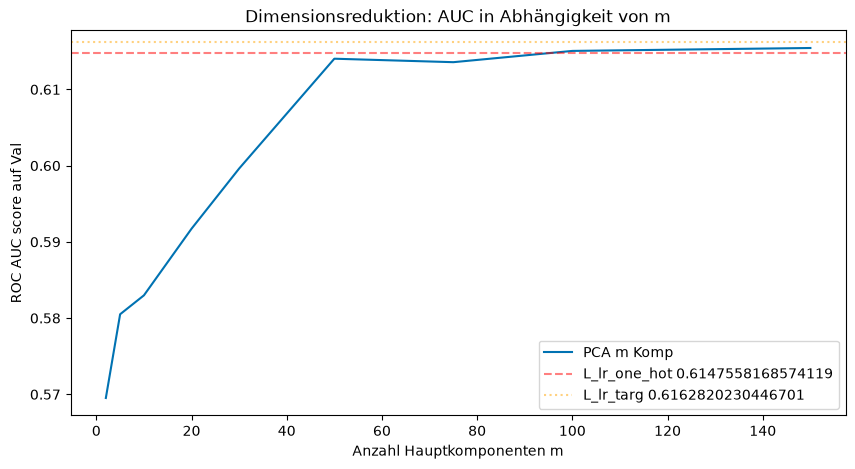

In [324]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sweep["m"], df_sweep["auc_test"], label="PCA m Komp")
ax.axhline(results[1]["auc_test"], linestyle="--", label=f"L_lr_one_hot {results[1]["auc_test"]}", color="red", alpha=0.5)
ax.axhline(results[0]["auc_test"], linestyle=":", label=f"L_lr_targ {results[0]["auc_test"]}", color="orange", alpha=0.5)
ax.set_xlabel("Anzahl Hauptkomponenten m")
ax.set_ylabel("ROC AUC score auf Val")
ax.set_title("Dimensionsreduktion: AUC in Abhängigkeit von m")
ax.legend()

In [325]:
beste = df_sweep.loc[df_sweep["auc_test"].idxmax()]

train_times[beste["model_idx"]] = beste["trainingszeit"]

results.append({
    a: beste[a] for a in ("model_idx", "auc_train", "auc_test", "gini", "delta_auc", "best_iter", "trainingszeit")
})

pd.DataFrame(results).sort_values("auc_test", ascending=False)

,model_idx,auc_train,auc_test,gini,delta_auc,best_iter,trainingszeit
0,L_lr_targ,0.633128,0.616282,0.232564,0.016846,None,2.766404
2,L_lr_pca_150,0.633869,0.615432,0.230864,0.018437,None,1.715410
1,L_lr_one_hot,0.634850,0.614756,0.229512,0.020094,None,3.348317


## Grid Search für LogReg
simplere Grid search aus Zeitgründen, solange ich mir Optuna LogReg anschaue

In [326]:
param_grid = [{
    "C": np.logspace(-3, 2, 11), 
    "penalty": ["l2"],
    "class_weight": [None, "balanced"]
    },
    {
    "penalty": [None],
    "class_weight": [None, "balanced"]
    },
]

In [327]:
# grid = []

# for name, x_tr, x_va in (
#     ("L_lr_targ", x_train_targ_scale, x_val_targ_scale),
#     ("L_lr_one_hot", x_train_scale, x_val_scale),
#     ("L_lr_pca_93", x_train_pca[:, :93], x_val_pca[:, :93]),
# ):
#     for params in ParameterGrid(param_grid):
#         start = time.time()
#         modell = LogisticRegression(
#             **params, 
#             solver="lbfgs", 
#             random_state=RANDOM_STATE, 
#             max_iter=1000
#         ).fit(x_tr, y_train)
#         row = eval_modell(f"{name}_{params}", modell, x_tr, y_train, x_va, y_val, time.time() - start)
#         row["variante"] = name
#         row["C"] = params.get("C", "x")
#         row["penalty"] = params["penalty"]
#         row["class_weight"] = params["class_weight"]
#         grid.append(row)

# df_grid = pd.DataFrame(grid)
# df_grid.sort_values("auc_test", ascending=False).head(10)

## Optuna log reg for pca data

In [328]:
x_tr_opt, x_va_opt = x_train_pca[:, :93], x_val_pca[:, :93]

In [329]:
def objective(trial):
    l1_ratio = trial.suggest_categorical("l1_ratio", [0.0, 0.25, 0.5, 0.75, 1.0])

    params = {
        "l1_ratio": l1_ratio,
        "C": trial.suggest_float("C", 1e-3, 1e2, log=True),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "solver": "lbfgs" if l1_ratio == 0.0 else "saga",
        "max_iter": 1000 if l1_ratio == 0.0 else 5000,
        "random_state": RANDOM_STATE
    }

    modell = LogisticRegression(
        **params
    ).fit(x_tr_opt, y_train)

    return roc_auc_score(y_val, modell.predict_proba(x_va_opt)[:, 1])

In [330]:
# study_pca_logreg = optuna.create_study(
#     study_name="L_lr_pca_opti",
#     storage="sqlite:///lr_pca_opti.db",
#     load_if_exists = True,
#     direction = "maximize",
#     sampler = TPESampler(seed=RANDOM_STATE)
# )

In [331]:
# study_pca_logreg.optimize(
#     objective, 
#     n_trials=50,
#     timeout=3*60*60,
#     catch=(Exception, ),
#     show_progress_bar=True
# )

In [332]:
study_pca_logreg = optuna.load_study(
    study_name = "L_lr_pca_opti",
    storage = "sqlite:///lr_pca_opti.db"
)

In [333]:
pd.Series(study_pca_logreg.best_params | {"auc_val": study_pca_logreg.best_value})

l1_ratio        0.250000
C               0.001707
class_weight         NaN
auc_val         0.598634
dtype: float64

In [334]:
pd.Series([tri.state.name for tri in study_pca_logreg.trials]).value_counts()

COMPLETE    7
Name: count, dtype: int64

In [335]:
best = study_pca_logreg.best_params.copy()
best["solver"] = "lbfgs" if best["l1_ratio"] == 0.0 else "saga"

start = time.time()
L_lr_pca_opt = LogisticRegression(
    **best,
    max_iter=1000,
    random_state=RANDOM_STATE
).fit(x_tr_opt, y_train)
train_times["L_lr_pca_opt"] = time.time() - start

results.append(
    eval_modell("L_lr_pca_opt", L_lr_pca_opt, x_tr_opt, y_train, x_va_opt, y_val, train_times["L_lr_pca_opt"])
)

pd.DataFrame(results).sort_values("auc_test", ascending=False)

,model_idx,auc_train,auc_test,gini,delta_auc,best_iter,trainingszeit
0,L_lr_targ,0.633128,0.616282,0.232564,0.016846,None,2.766404
2,L_lr_pca_150,0.633869,0.615432,0.230864,0.018437,None,1.715410
1,L_lr_one_hot,0.634850,0.614756,0.229512,0.020094,None,3.348317
3,L_lr_pca_opt,0.613576,0.598634,0.197267,0.014942,None,11.544372


# Notebook 17
Quelle: 17_XGBoost_opti_prep.ipynb

In [336]:
def eval_modell(mod_idx, model, x_train, y_train, x_val, y_val, train_time, best_iter=None):
    """AUC auf Train und Val"""
    auc_train = roc_auc_score(y_train, model.predict_proba(x_train)[:, 1])
    auc_val = roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    return {
        "model_idx": mod_idx,
        "auc_train": auc_train,
        "auc_val": auc_val,
        "gini": 2 * auc_val - 1,
        "delta_auc": auc_train - auc_val,
        "best_iter": best_iter,
        "trainingszeit": train_time
    }

In [337]:
x_train_no_calc = x_train[feat_cols_no_calc]
x_val_no_calc = x_val[feat_cols_no_calc]
x_test_no_calc = x_test[feat_cols_no_calc]
x_full_no_calc = x_full[feat_cols_no_calc]

## Optuna Hilfe

## Suchräume

|Parameter|Bereich|
|---|---|
|learning_rate|0.01-0.1 (log)|
|max_depth|3-7|
|min_child_weight|1-200 (log)|
|gamma|1e-3-5 (log)|
|reg_lambda|0.1-100 (log)|
|reg_alpha|1e-3-10 (log)|
|max_delta_step|0-10|
|subsample|0.5-1.0|
|colsample_bynode|0.5-1.0|
|scale_pos_weight|1 / 5 / 27|
|max_cat_to_onehot|2 / 10 / 18 / 105|

In [338]:
fixed_params_xgb = {
    "random_state": RANDOM_STATE,
    "verbosity": 0,
    "device": "cpu",
    "n_jobs": -1,
    "tree_method": "hist",
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "enable_categorical": True,
    "n_estimators": 3000,
    "early_stopping_rounds": 100
}

In [339]:
def suchraum_params(trial):
    """Suchraum definition"""
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 200.0, log=True),
        "gamma": trial.suggest_float("gamma", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 100.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "max_delta_step": trial.suggest_int("max_delta_step", 0, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.5, 1.0),
        "scale_pos_weight": trial.suggest_categorical("scale_pos_weight", [1, 5, 27]),
        "max_cat_to_onehot": trial.suggest_categorical("max_cat_to_onehot", [2, 10, 18, 105]),
    }

    return params

## Mit Calc

In [340]:
def objective_xgb_calc(trial):
    pruning_callback = XGBoostPruningCallback(trial, "validation_0-auc")

    modell = XGBClassifier(
        **fixed_params_xgb,
        **suchraum_params(trial),
        callbacks=[pruning_callback]
    )

    modell.fit(x_train, y_train, eval_set=[(x_val, y_val)], verbose=0)

    return roc_auc_score(y_val, modell.predict_proba(x_val)[:, 1])

In [341]:
# study_xgb_calc = optuna.create_study(
#     study_name = "XGBoost_calc",
#     storage = "sqlite:///xgboost_opti.db",
#     load_if_exists = True,
#     direction = "maximize",
#     sampler = TPESampler(seed=RANDOM_STATE),
#     pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=500)
# )

In [342]:
# study_xgb_calc.optimize(
#     objective_xgb_calc,
#     n_trials = 50,
#     timeout = 4*60*60,
#     catch = (Exception, )
# )

In [343]:
study_xgb_calc = optuna.load_study(
    study_name = "XGBoost_calc",
    storage = "sqlite:///xgboost_opti.db"
)


In [344]:
pd.DataFrame({
    "best auc_val": study_xgb_calc.best_value,
    "best gini": 2 * study_xgb_calc.best_value - 1,
    "trials": len(study_xgb_calc.trials),
    "pruned": len([t for t in study_xgb_calc.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_xgb_calc.trials if t.state.name == "FAIL"]),
    "best params": study_xgb_calc.best_params
})

,best auc_val,best gini,trials,pruned,fail,best params
learning_rate,0.636859,0.273717,50,2,0,0.038768
max_depth,0.636859,0.273717,50,2,0,6.000000
min_child_weight,0.636859,0.273717,50,2,0,167.926688
gamma,0.636859,0.273717,50,2,0,0.033641
reg_lambda,0.636859,0.273717,50,2,0,0.462911
reg_alpha,0.636859,0.273717,50,2,0,9.390737
max_delta_step,0.636859,0.273717,50,2,0,2.000000
subsample,0.636859,0.273717,50,2,0,0.940044
colsample_bynode,0.636859,0.273717,50,2,0,0.799588
scale_pos_weight,0.636859,0.273717,50,2,0,5.000000


In [345]:
study_xgb_calc.best_params

{'learning_rate': 0.03876789506863172,
 'max_depth': 6,
 'min_child_weight': 167.92668780218096,
 'gamma': 0.03364115364527517,
 'reg_lambda': 0.4629111449696439,
 'reg_alpha': 9.390737194189775,
 'max_delta_step': 2,
 'subsample': 0.9400435963951956,
 'colsample_bynode': 0.7995884349413557,
 'scale_pos_weight': 5,
 'max_cat_to_onehot': 105}

## Ohne Calc

In [346]:
def objective_xgb_no_calc(trial):
    pruning_callback = XGBoostPruningCallback(trial, "validation_0-auc")

    modell = XGBClassifier(
        **fixed_params_xgb,
        **suchraum_params(trial),
        callbacks=[pruning_callback]
    )

    modell.fit(x_train_no_calc, y_train, eval_set=[(x_val_no_calc, y_val)], verbose=0)

    return roc_auc_score(y_val, modell.predict_proba(x_val_no_calc)[:, 1])

In [347]:
# study_xgb_no_calc = optuna.create_study(
#     study_name = "XGBoost_no_calc",
#     storage = "sqlite:///xgboost_opti.db",
#     load_if_exists = True,
#     direction = "maximize",
#     sampler = TPESampler(seed=RANDOM_STATE),
#     pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=500)
# )

In [348]:
# study_xgb_no_calc.optimize(
#     objective_xgb_no_calc,
#     n_trials = 50,
#     timeout = 4*60*60,
#     catch = (Exception, )
# )

In [349]:
study_xgb_no_calc = optuna.load_study(
    study_name = "XGBoost_no_calc",
    storage = "sqlite:///xgboost_opti.db"
)

In [350]:
pd.DataFrame({
    "best auc_val": study_xgb_no_calc.best_value,
    "best gini": 2 * study_xgb_no_calc.best_value - 1,
    "trials": len(study_xgb_no_calc.trials),
    "pruned": len([t for t in study_xgb_no_calc.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_xgb_no_calc.trials if t.state.name == "FAIL"]),
    "best params": study_xgb_no_calc.best_params
})

,best auc_val,best gini,trials,pruned,fail,best params
learning_rate,0.639986,0.279972,50,4,0,0.077903
max_depth,0.639986,0.279972,50,4,0,7.000000
min_child_weight,0.639986,0.279972,50,4,0,126.488318
gamma,0.639986,0.279972,50,4,0,0.493110
reg_lambda,0.639986,0.279972,50,4,0,2.245830
reg_alpha,0.639986,0.279972,50,4,0,0.055327
max_delta_step,0.639986,0.279972,50,4,0,7.000000
subsample,0.639986,0.279972,50,4,0,0.800055
colsample_bynode,0.639986,0.279972,50,4,0,0.896860
scale_pos_weight,0.639986,0.279972,50,4,0,1.000000


In [351]:
study_xgb_no_calc.best_params

{'learning_rate': 0.07790268189585514,
 'max_depth': 7,
 'min_child_weight': 126.48831841040663,
 'gamma': 0.49311029649427224,
 'reg_lambda': 2.2458304124422743,
 'reg_alpha': 0.055327262047932445,
 'max_delta_step': 7,
 'subsample': 0.800054663467233,
 'colsample_bynode': 0.8968596357800713,
 'scale_pos_weight': 1,
 'max_cat_to_onehot': 105}

## Load Study

In [352]:
study_xgb_calc_loaded = optuna.load_study(
    study_name = "XGBoost_calc",
    storage = "sqlite:///xgboost_opti.db"
)


In [353]:
study_xgb_no_calc_loaded = optuna.load_study(
    study_name = "XGBoost_no_calc",
    storage = "sqlite:///xgboost_opti.db"
)

## Best Params again

In [354]:
study_xgb_calc_loaded.best_params

{'learning_rate': 0.03876789506863172,
 'max_depth': 6,
 'min_child_weight': 167.92668780218096,
 'gamma': 0.03364115364527517,
 'reg_lambda': 0.4629111449696439,
 'reg_alpha': 9.390737194189775,
 'max_delta_step': 2,
 'subsample': 0.9400435963951956,
 'colsample_bynode': 0.7995884349413557,
 'scale_pos_weight': 5,
 'max_cat_to_onehot': 105}

In [355]:
study_xgb_no_calc_loaded.best_params

{'learning_rate': 0.07790268189585514,
 'max_depth': 7,
 'min_child_weight': 126.48831841040663,
 'gamma': 0.49311029649427224,
 'reg_lambda': 2.2458304124422743,
 'reg_alpha': 0.055327262047932445,
 'max_delta_step': 7,
 'subsample': 0.800054663467233,
 'colsample_bynode': 0.8968596357800713,
 'scale_pos_weight': 1,
 'max_cat_to_onehot': 105}

## 100% Train

In [356]:
results = []
train_times = {}

In [357]:
name = "L_xgb_opt_01"

L_xgb_opt_01 = XGBClassifier(
    **fixed_params_xgb,
    **study_xgb_calc_loaded.best_params
)

start = time.time()
L_xgb_opt_01.fit(
    x_train, y_train, 
    eval_set=[(x_val, y_val)], 
    verbose=250
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_xgb_opt_01, x_train, y_train, x_val, y_val, train_times[name], best_iter=L_xgb_opt_01.best_iteration)
)

[0]	validation_0-auc:0.59868
[250]	validation_0-auc:0.63507
[500]	validation_0-auc:0.63628
[750]	validation_0-auc:0.63670
[829]	validation_0-auc:0.63639


In [358]:
name = "L_xgb_opt_02"

L_xgb_opt_02 = XGBClassifier(
    **fixed_params_xgb,
    **study_xgb_no_calc_loaded.best_params
)

start = time.time()
L_xgb_opt_02.fit(
    x_train_no_calc, y_train, 
    eval_set=[(x_val_no_calc, y_val)], 
    verbose=250
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_xgb_opt_02, x_train_no_calc, y_train, x_val_no_calc, y_val, train_times[name], best_iter=L_xgb_opt_02.best_iteration)
)

[0]	validation_0-auc:0.60092
[239]	validation_0-auc:0.63778


In [359]:
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_xgb_opt_01,0.736660,0.636859,0.273717,0.099802,729,42.033530
1,L_xgb_opt_02,0.680683,0.639986,0.279972,0.040697,139,11.556494


## Save Models

In [360]:
Modelle = [
    (L_xgb_opt_01, "L_xgb_opt_01"),
    (L_xgb_opt_02, "L_xgb_opt_02")
]

# for modell, name in Modelle:
#     modell.save_model(f"{name}.json")

# Notebook 18
Quelle: 18_XGBoost_opti_prep_targenc.ipynb

## Optuna Hilfe

## Suchräume

|Parameter|Bereich|
|---|---|
|learning_rate|0.01-0.1 (log)|
|max_depth|3-7|
|min_child_weight|1-200 (log)|
|gamma|1e-3-5 (log)|
|reg_lambda|0.1-100 (log)|
|reg_alpha|1e-3-10 (log)|
|max_delta_step|0-10|
|subsample|0.5-1.0|
|colsample_bynode|0.5-1.0|
|scale_pos_weight|1 / 5 / 27|
|max_cat_to_onehot|2 / 10 / 18|

In [361]:
def suchraum_params(trial):
    """Suchraum definition"""
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 200.0, log=True),
        "gamma": trial.suggest_float("gamma", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 100.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "max_delta_step": trial.suggest_int("max_delta_step", 0, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.5, 1.0),
        "scale_pos_weight": trial.suggest_categorical("scale_pos_weight", [1, 5, 27]),
        "max_cat_to_onehot": trial.suggest_categorical("max_cat_to_onehot", [2, 10, 18]),
    }

    return params

In [362]:
targ_enc = TargetEncoder(cv=5, random_state=RANDOM_STATE)

x_train_te = x_train.copy()
x_val_te = x_val.copy()
x_test_te = x_test.copy()

x_train_te[high_kard_cols] = targ_enc.fit_transform(x_train[high_kard_cols], y_train)
x_val_te[high_kard_cols] = targ_enc.transform(x_val[high_kard_cols])
x_test_te[high_kard_cols] = targ_enc.transform(x_test[high_kard_cols])

x_train_no_calc_te = x_train_te[feat_cols_no_calc]
x_val_no_calc_te = x_val_te[feat_cols_no_calc]
x_test_no_calc_te = x_test_te[feat_cols_no_calc]

x_train_te[high_kard_cols].describe()

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


,ps_car_11_cat
count,476168.000000
mean,0.036446
std,0.009676
min,0.016329
25%,0.028362
50%,0.034718
75%,0.044178
max,0.078113


## Mit Calc

In [363]:
def objective_xgb_calc_te(trial):
    pruning_callback = XGBoostPruningCallback(trial, "validation_0-auc")

    modell = XGBClassifier(
        **fixed_params_xgb,
        **suchraum_params(trial),
        callbacks=[pruning_callback]
    )

    modell.fit(x_train_te, y_train, eval_set=[(x_val_te, y_val)], verbose=0)

    return roc_auc_score(y_val, modell.predict_proba(x_val_te)[:, 1])

In [364]:
# study_xgb_calc_te = optuna.create_study(
#     study_name = "XGBoost_calc_te",
#     storage = "sqlite:///xgboost_opti.db",
#     load_if_exists = True,
#     direction = "maximize",
#     sampler = TPESampler(seed=RANDOM_STATE),
#     pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=500)
# )

In [365]:
# study_xgb_calc_te.optimize(
#     objective_xgb_calc_te,
#     n_trials = 50,
#     timeout = 4*60*60,
#     catch = (Exception, )
# )

In [366]:
study_xgb_calc_te = optuna.load_study(
    study_name = "XGBoost_calc_te",
    storage = "sqlite:///xgboost_opti.db"
)


In [367]:
pd.DataFrame({
    "best auc_val": study_xgb_calc_te.best_value,
    "best gini": 2 * study_xgb_calc_te.best_value - 1,
    "trials": len(study_xgb_calc_te.trials),
    "pruned": len([t for t in study_xgb_calc_te.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_xgb_calc_te.trials if t.state.name == "FAIL"]),
    "best params": study_xgb_calc_te.best_params
})

,best auc_val,best gini,trials,pruned,fail,best params
learning_rate,0.637973,0.275947,50,8,0,0.018784
max_depth,0.637973,0.275947,50,8,0,6.000000
min_child_weight,0.637973,0.275947,50,8,0,26.805781
gamma,0.637973,0.275947,50,8,0,0.004322
reg_lambda,0.637973,0.275947,50,8,0,42.387085
reg_alpha,0.637973,0.275947,50,8,0,0.124704
max_delta_step,0.637973,0.275947,50,8,0,7.000000
subsample,0.637973,0.275947,50,8,0,0.610842
colsample_bynode,0.637973,0.275947,50,8,0,0.674854
scale_pos_weight,0.637973,0.275947,50,8,0,1.000000


In [368]:
study_xgb_calc_te.best_params

{'learning_rate': 0.01878422273943782,
 'max_depth': 6,
 'min_child_weight': 26.80578055959848,
 'gamma': 0.0043219290644965075,
 'reg_lambda': 42.387084879302726,
 'reg_alpha': 0.12470405254321192,
 'max_delta_step': 7,
 'subsample': 0.6108424214140475,
 'colsample_bynode': 0.6748543547526068,
 'scale_pos_weight': 1,
 'max_cat_to_onehot': 2}

## Ohne Calc

In [369]:
def objective_xgb_no_calc_te(trial):
    pruning_callback = XGBoostPruningCallback(trial, "validation_0-auc")

    modell = XGBClassifier(
        **fixed_params_xgb,
        **suchraum_params(trial),
        callbacks=[pruning_callback]
    )

    modell.fit(x_train_no_calc_te, y_train, eval_set=[(x_val_no_calc_te, y_val)], verbose=0)

    return roc_auc_score(y_val, modell.predict_proba(x_val_no_calc_te)[:, 1])

In [370]:
# study_xgb_no_calc_te = optuna.create_study(
#     study_name = "XGBoost_no_calc_te",
#     storage = "sqlite:///xgboost_opti.db",
#     load_if_exists = True,
#     direction = "maximize",
#     sampler = TPESampler(seed=RANDOM_STATE),
#     pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=500)
# )

In [371]:
# study_xgb_no_calc_te.optimize(
#     objective_xgb_no_calc_te,
#     n_trials = 50,
#     timeout = 4*60*60,
#     catch = (Exception, )
# )

In [372]:
study_xgb_no_calc_te = optuna.load_study(
    study_name = "XGBoost_no_calc_te",
    storage = "sqlite:///xgboost_opti.db"
)

In [373]:
pd.DataFrame({
    "best auc_val": study_xgb_no_calc_te.best_value,
    "best gini": 2 * study_xgb_no_calc_te.best_value - 1,
    "trials": len(study_xgb_no_calc_te.trials),
    "pruned": len([t for t in study_xgb_no_calc_te.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_xgb_no_calc_te.trials if t.state.name == "FAIL"]),
    "best params": study_xgb_no_calc_te.best_params
})

,best auc_val,best gini,trials,pruned,fail,best params
learning_rate,0.64047,0.280939,50,15,0,0.068409
max_depth,0.64047,0.280939,50,15,0,4.000000
min_child_weight,0.64047,0.280939,50,15,0,123.572582
gamma,0.64047,0.280939,50,15,0,1.226278
reg_lambda,0.64047,0.280939,50,15,0,1.262450
reg_alpha,0.64047,0.280939,50,15,0,0.389757
max_delta_step,0.64047,0.280939,50,15,0,4.000000
subsample,0.64047,0.280939,50,15,0,0.871835
colsample_bynode,0.64047,0.280939,50,15,0,0.697225
scale_pos_weight,0.64047,0.280939,50,15,0,1.000000


In [374]:
study_xgb_no_calc_te.best_params

{'learning_rate': 0.06840892817037018,
 'max_depth': 4,
 'min_child_weight': 123.5725817719912,
 'gamma': 1.2262777677477144,
 'reg_lambda': 1.2624495151772979,
 'reg_alpha': 0.3897567030114538,
 'max_delta_step': 4,
 'subsample': 0.8718352321453859,
 'colsample_bynode': 0.6972248821194833,
 'scale_pos_weight': 1,
 'max_cat_to_onehot': 10}

## Load Study

In [375]:
study_xgb_calc_te_loaded = optuna.load_study(
    study_name = "XGBoost_calc_te",
    storage = "sqlite:///xgboost_opti.db"
)


In [376]:
study_xgb_no_calc_te_loaded = optuna.load_study(
    study_name = "XGBoost_no_calc_te",
    storage = "sqlite:///xgboost_opti.db"
)

## Best Params again

In [377]:
study_xgb_calc_te_loaded.best_params

{'learning_rate': 0.01878422273943782,
 'max_depth': 6,
 'min_child_weight': 26.80578055959848,
 'gamma': 0.0043219290644965075,
 'reg_lambda': 42.387084879302726,
 'reg_alpha': 0.12470405254321192,
 'max_delta_step': 7,
 'subsample': 0.6108424214140475,
 'colsample_bynode': 0.6748543547526068,
 'scale_pos_weight': 1,
 'max_cat_to_onehot': 2}

In [378]:
study_xgb_no_calc_te_loaded.best_params

{'learning_rate': 0.06840892817037018,
 'max_depth': 4,
 'min_child_weight': 123.5725817719912,
 'gamma': 1.2262777677477144,
 'reg_lambda': 1.2624495151772979,
 'reg_alpha': 0.3897567030114538,
 'max_delta_step': 4,
 'subsample': 0.8718352321453859,
 'colsample_bynode': 0.6972248821194833,
 'scale_pos_weight': 1,
 'max_cat_to_onehot': 10}

## 100% Train

In [379]:
results = []
train_times = {}

In [380]:
name = "L_xgb_opt_03"

L_xgb_opt_03 = XGBClassifier(
    **fixed_params_xgb,
    **study_xgb_calc_te_loaded.best_params
)

start = time.time()
L_xgb_opt_03.fit(
    x_train_te, y_train, 
    eval_set=[(x_val_te, y_val)], 
    verbose=250
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_xgb_opt_03, x_train_te, y_train, x_val_te, y_val, train_times[name], best_iter=L_xgb_opt_03.best_iteration)
)

[0]	validation_0-auc:0.59660
[250]	validation_0-auc:0.63438
[500]	validation_0-auc:0.63640
[750]	validation_0-auc:0.63777
[882]	validation_0-auc:0.63742


In [381]:
name = "L_xgb_opt_04"

L_xgb_opt_04 = XGBClassifier(
    **fixed_params_xgb,
    **study_xgb_no_calc_te_loaded.best_params
)

start = time.time()
L_xgb_opt_04.fit(
    x_train_no_calc_te, y_train, 
    eval_set=[(x_val_no_calc_te, y_val)], 
    verbose=250
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_xgb_opt_04, x_train_no_calc_te, y_train, x_val_no_calc_te, y_val, train_times[name], best_iter=L_xgb_opt_04.best_iteration)
)

[0]	validation_0-auc:0.58953
[250]	validation_0-auc:0.63782
[500]	validation_0-auc:0.64021
[665]	validation_0-auc:0.64006


In [382]:
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_xgb_opt_03,0.712847,0.637973,0.275947,0.074874,782,56.405991
1,L_xgb_opt_04,0.685711,0.640470,0.280939,0.045242,565,21.131996


## Save Models

In [383]:
Modelle = [
    (L_xgb_opt_03, "L_xgb_opt_03"),
    (L_xgb_opt_04, "L_xgb_opt_04")
]

# for modell, name in Modelle:
#     modell.save_model(f"{name}.json")

# Notebook 20
Quelle: 20_HGB_opti_prep.ipynb

## Preproc nach J_D

In [384]:
targ_enc = TargetEncoder(
    cv=5,
    shuffle=True,
    random_state=RANDOM_STATE,
    smooth=50.0
)

In [385]:
te_train = pd.DataFrame(
    targ_enc.fit_transform(x_train[cat_cols], y_train),
    columns=cat_cols,
    index=x_train.index
)

te_val = pd.DataFrame(
    targ_enc.transform(x_val[cat_cols]),
    columns=cat_cols,
    index=x_val.index
)

te_test = pd.DataFrame(
    targ_enc.transform(x_test[cat_cols]),
    columns=cat_cols,
    index=x_test.index
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [386]:
x_train_hgb = x_train.copy()
x_val_hgb = x_val.copy()
x_test_hgb = x_test.copy()

x_train_hgb[cat_cols] = te_train
x_val_hgb[cat_cols] = te_val
x_test_hgb[cat_cols] = te_test

In [387]:
x_train_hgb_no_calc = x_train_hgb[feat_cols_no_calc]
x_val_hgb_no_calc = x_val_hgb[feat_cols_no_calc]
x_test_hgb_no_calc = x_test_hgb[feat_cols_no_calc]

In [388]:
pd.Series({
    "train": [len(x_train), len(x_train_hgb), len(x_train_hgb_no_calc)],
    "val": [len(x_val), len(x_val_hgb), len(x_val_hgb_no_calc)],
    "test": [len(x_test), len(x_test_hgb), len(x_test_hgb_no_calc)]
})

train    [476168, 476168, 476168]
val         [59522, 59522, 59522]
test        [59522, 59522, 59522]
dtype: object

## Optuna Hilfe

## Suchräume

|Parameter|Bereich|
|---|---|
|learning_rate|0.003-0.3 (log)|
|min_samples_leaf|5-40000 (log)|
|l2_regularization|1e-8 - 1e5 (log)|
|max_features|0.05-0.35|
|max_bins|104-255|
|interaction_cst|None / pairwise / no_interactions|
|validation_fraction|0.01-0.1|
|n_iter_no_change|5-40|
|tol|1e-10 - 1e-5 (log)|

Für händische Versuche entweder:
|Parameter|Bereich|
|---|---|
|max_leaf_nodes|2-63|
|max_depth|1-6|

In [389]:
fixed_params_leaf = {
    "random_state": RANDOM_STATE,
    "verbose": 0,
    "loss": "log_loss",
    "class_weight": None,
    "categorical_features": None,
    "scoring": "loss",
    "max_iter": 5000,
    "early_stopping": True,
    "max_depth": None
}

In [390]:
fixed_params_depth = {
    "random_state": RANDOM_STATE,
    "verbose": 0,
    "loss": "log_loss",
    "class_weight": None,
    "categorical_features": None,
    "scoring": "loss",
    "max_iter": 5000,
    "early_stopping": True,
    "max_leaf_nodes": None
}

In [391]:
def suchraum_params_leaf(trial):
    """Suchraum definition, leaf"""
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.003, 0.3, log=True),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 40000, log=True),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-8, 1e5, log=True),
        "max_features": trial.suggest_float("max_features", 0.05, 0.35),
        "max_bins": trial.suggest_int("max_bins", 104, 255),
        "interaction_cst": trial.suggest_categorical("interaction_cst", [None, "pairwise", "no_interactions"]),
        "validation_fraction": trial.suggest_float("validation_fraction", 0.01, 0.1),
        "n_iter_no_change": trial.suggest_int("n_iter_no_change", 5, 40),
        "tol": trial.suggest_float("tol", 1e-10, 1e-5, log=True),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 2, 63)
    }

    return params

In [392]:
def suchraum_params_depth(trial):
    """Suchraum definition, depth"""
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.003, 0.3, log=True),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 40000, log=True),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-8, 1e5, log=True),
        "max_features": trial.suggest_float("max_features", 0.05, 0.35),
        "max_bins": trial.suggest_int("max_bins", 104, 255),
        "interaction_cst": trial.suggest_categorical("interaction_cst", [None, "pairwise", "no_interactions"]),
        "validation_fraction": trial.suggest_float("validation_fraction", 0.01, 0.1),
        "n_iter_no_change": trial.suggest_int("n_iter_no_change", 5, 40),
        "tol": trial.suggest_float("tol", 1e-10, 1e-5, log=True),
        "max_depth": trial.suggest_int("max_depth", 1, 6)
    }

    return params

## Leaf mit Calc

In [393]:
def objective_leaf_calc(trial):

    modell = HistGradientBoostingClassifier(
        **fixed_params_leaf,
        **suchraum_params_leaf(trial)
    )

    modell.fit(x_train_hgb, y_train)

    return roc_auc_score(y_val, modell.predict_proba(x_val_hgb)[:, 1])

In [394]:
# study_leaf_calc = optuna.create_study(
#     study_name = "HGB_leaf_calc",
#     storage = "sqlite:///HGB_opti.db",
#     load_if_exists = True,
#     direction = "maximize",
#     sampler = TPESampler(seed=RANDOM_STATE),
#     pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=500)
# )

In [395]:
# study_leaf_calc.optimize(
#     objective_leaf_calc,
#     n_trials = 50,
#     timeout = 4*60*60,
#     catch = (Exception, )
# )

In [396]:
study_leaf_calc = optuna.load_study(
    study_name = "HGB_leaf_calc",
    storage = "sqlite:///HGB_opti.db"
)


In [397]:
pd.DataFrame({
    "best auc_val": study_leaf_calc.best_value,
    "best gini": 2 * study_leaf_calc.best_value - 1,
    "trials": len(study_leaf_calc.trials),
    "pruned": len([t for t in study_leaf_calc.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_leaf_calc.trials if t.state.name == "FAIL"]),
    "best params": study_leaf_calc.best_params
})

,best auc_val,best gini,trials,pruned,fail,best params
learning_rate,0.6366,0.273201,50,0,0,1.452174e-02
min_samples_leaf,0.6366,0.273201,50,0,0,5.975000e+03
l2_regularization,0.6366,0.273201,50,0,0,1.026213e+01
max_features,0.6366,0.273201,50,0,0,2.477600e-01
max_bins,0.6366,0.273201,50,0,0,2.310000e+02
interaction_cst,0.6366,0.273201,50,0,0,NaN
validation_fraction,0.6366,0.273201,50,0,0,5.731336e-02
n_iter_no_change,0.6366,0.273201,50,0,0,3.800000e+01
tol,0.6366,0.273201,50,0,0,1.209587e-08
max_leaf_nodes,0.6366,0.273201,50,0,0,3.600000e+01


In [398]:
study_leaf_calc.best_params

{'learning_rate': 0.014521736210156313,
 'min_samples_leaf': 5975,
 'l2_regularization': 10.262130162526471,
 'max_features': 0.24775997297590835,
 'max_bins': 231,
 'interaction_cst': None,
 'validation_fraction': 0.0573133556070173,
 'n_iter_no_change': 38,
 'tol': 1.2095870910048285e-08,
 'max_leaf_nodes': 36}

## Leaf ohne Calc

In [399]:
def objective_leaf_no_calc(trial):

    modell = HistGradientBoostingClassifier(
        **fixed_params_leaf,
        **suchraum_params_leaf(trial)
    )

    modell.fit(x_train_hgb_no_calc, y_train)

    return roc_auc_score(y_val, modell.predict_proba(x_val_hgb_no_calc)[:, 1])

In [400]:
# study_leaf_no_calc = optuna.create_study(
#     study_name = "HGB_leaf_no_calc",
#     storage = "sqlite:///HGB_opti.db",
#     load_if_exists = True,
#     direction = "maximize",
#     sampler = TPESampler(seed=RANDOM_STATE),
#     pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=500)
# )

In [401]:
# study_leaf_no_calc.optimize(
#     objective_leaf_no_calc,
#     n_trials = 50,
#     timeout = 4*60*60,
#     catch = (Exception, )
# )

In [402]:
study_leaf_no_calc = optuna.load_study(
    study_name = "HGB_leaf_no_calc",
    storage = "sqlite:///HGB_opti.db"
)

In [403]:
pd.DataFrame({
    "best auc_val": study_leaf_no_calc.best_value,
    "best gini": 2 * study_leaf_no_calc.best_value - 1,
    "trials": len(study_leaf_no_calc.trials),
    "pruned": len([t for t in study_leaf_no_calc.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_leaf_no_calc.trials if t.state.name == "FAIL"]),
    "best params": study_leaf_no_calc.best_params
})

,best auc_val,best gini,trials,pruned,fail,best params
learning_rate,0.638318,0.276637,50,0,0,0.004109
min_samples_leaf,0.638318,0.276637,50,0,0,6833.000000
l2_regularization,0.638318,0.276637,50,0,0,52.458189
max_features,0.638318,0.276637,50,0,0,0.296687
max_bins,0.638318,0.276637,50,0,0,202.000000
interaction_cst,0.638318,0.276637,50,0,0,NaN
validation_fraction,0.638318,0.276637,50,0,0,0.013916
n_iter_no_change,0.638318,0.276637,50,0,0,40.000000
tol,0.638318,0.276637,50,0,0,0.000001
max_leaf_nodes,0.638318,0.276637,50,0,0,32.000000


In [404]:
study_leaf_no_calc.best_params

{'learning_rate': 0.004108690179427848,
 'min_samples_leaf': 6833,
 'l2_regularization': 52.45818863330329,
 'max_features': 0.2966869253501312,
 'max_bins': 202,
 'interaction_cst': None,
 'validation_fraction': 0.01391561653087682,
 'n_iter_no_change': 40,
 'tol': 1.4783911269827303e-06,
 'max_leaf_nodes': 32}

## Depth mit Calc

In [405]:
def objective_depth_calc(trial):

    modell = HistGradientBoostingClassifier(
        **fixed_params_depth,
        **suchraum_params_depth(trial)
    )

    modell.fit(x_train_hgb, y_train)

    return roc_auc_score(y_val, modell.predict_proba(x_val_hgb)[:, 1])

In [406]:
# study_depth_calc = optuna.create_study(
#     study_name = "HGB_depth_calc",
#     storage = "sqlite:///HGB_opti.db",
#     load_if_exists = True,
#     direction = "maximize",
#     sampler = TPESampler(seed=RANDOM_STATE),
#     pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=500)
# )

In [407]:
# study_depth_calc.optimize(
#     objective_depth_calc,
#     n_trials = 50,
#     timeout = 4*60*60,
#     catch = (Exception, )
# )

In [408]:
study_depth_calc = optuna.load_study(
    study_name = "HGB_depth_calc",
    storage = "sqlite:///HGB_opti.db"
)


In [409]:
pd.DataFrame({
    "best auc_val": study_depth_calc.best_value,
    "best gini": 2 * study_depth_calc.best_value - 1,
    "trials": len(study_depth_calc.trials),
    "pruned": len([t for t in study_depth_calc.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_depth_calc.trials if t.state.name == "FAIL"]),
    "best params": study_depth_calc.best_params
})

,best auc_val,best gini,trials,pruned,fail,best params
learning_rate,0.634704,0.269407,50,0,0,2.158115e-01
min_samples_leaf,0.634704,0.269407,50,0,0,1.850000e+02
l2_regularization,0.634704,0.269407,50,0,0,7.188748e+02
max_features,0.634704,0.269407,50,0,0,2.160953e-01
max_bins,0.634704,0.269407,50,0,0,1.990000e+02
interaction_cst,0.634704,0.269407,50,0,0,NaN
validation_fraction,0.634704,0.269407,50,0,0,9.844242e-02
n_iter_no_change,0.634704,0.269407,50,0,0,1.500000e+01
tol,0.634704,0.269407,50,0,0,2.365868e-10
max_depth,0.634704,0.269407,50,0,0,6.000000e+00


In [410]:
study_depth_calc.best_params

{'learning_rate': 0.2158114975072843,
 'min_samples_leaf': 185,
 'l2_regularization': 718.8748437890337,
 'max_features': 0.2160953488876775,
 'max_bins': 199,
 'interaction_cst': None,
 'validation_fraction': 0.09844241887597069,
 'n_iter_no_change': 15,
 'tol': 2.3658675988459827e-10,
 'max_depth': 6}

## Depth ohne Calc

In [411]:
def objective_depth_no_calc(trial):

    modell = HistGradientBoostingClassifier(
        **fixed_params_depth,
        **suchraum_params_depth(trial)
    )

    modell.fit(x_train_hgb_no_calc, y_train)

    return roc_auc_score(y_val, modell.predict_proba(x_val_hgb_no_calc)[:, 1])

In [412]:
# study_depth_no_calc = optuna.create_study(
#     study_name = "HGB_depth_no_calc",
#     storage = "sqlite:///HGB_opti.db",
#     load_if_exists = True,
#     direction = "maximize",
#     sampler = TPESampler(seed=RANDOM_STATE),
#     pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=500)
# )

In [413]:
# study_depth_no_calc.optimize(
#     objective_depth_no_calc,
#     n_trials = 50,
#     timeout = 4*60*60,
#     catch = (Exception, )
# )

In [414]:
study_depth_no_calc = optuna.load_study(
    study_name = "HGB_depth_no_calc",
    storage = "sqlite:///HGB_opti.db"
)

In [415]:
pd.DataFrame({
    "best auc_val": study_depth_no_calc.best_value,
    "best gini": 2 * study_depth_no_calc.best_value - 1,
    "trials": len(study_depth_no_calc.trials),
    "pruned": len([t for t in study_depth_no_calc.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_depth_no_calc.trials if t.state.name == "FAIL"]),
    "best params": study_depth_no_calc.best_params
})

,best auc_val,best gini,trials,pruned,fail,best params
learning_rate,0.634533,0.269067,50,0,0,2.468715e-02
min_samples_leaf,0.634533,0.269067,50,0,0,1.650000e+02
l2_regularization,0.634533,0.269067,50,0,0,4.711124e-03
max_features,0.634533,0.269067,50,0,0,2.469807e-01
max_bins,0.634533,0.269067,50,0,0,1.440000e+02
interaction_cst,0.634533,0.269067,50,0,0,NaN
validation_fraction,0.634533,0.269067,50,0,0,1.482309e-02
n_iter_no_change,0.634533,0.269067,50,0,0,3.400000e+01
tol,0.634533,0.269067,50,0,0,8.370655e-08
max_depth,0.634533,0.269067,50,0,0,6.000000e+00


In [416]:
study_depth_no_calc.best_params

{'learning_rate': 0.024687148414834312,
 'min_samples_leaf': 165,
 'l2_regularization': 0.004711123505991509,
 'max_features': 0.2469806711366302,
 'max_bins': 144,
 'interaction_cst': None,
 'validation_fraction': 0.014823091721617599,
 'n_iter_no_change': 34,
 'tol': 8.37065478390795e-08,
 'max_depth': 6}

## Load Study

In [417]:
study_leaf_calc_loaded = optuna.load_study(
    study_name = "HGB_leaf_calc",
    storage = "sqlite:///HGB_opti.db"
)


In [418]:
study_leaf_no_calc_loaded = optuna.load_study(
    study_name = "HGB_leaf_no_calc",
    storage = "sqlite:///HGB_opti.db"
)

In [419]:
study_depth_calc_loaded = optuna.load_study(
    study_name = "HGB_depth_calc",
    storage = "sqlite:///HGB_opti.db"
)


In [420]:
study_depth_no_calc_loaded = optuna.load_study(
    study_name = "HGB_depth_no_calc",
    storage = "sqlite:///HGB_opti.db"
)

## Best Params again

In [421]:
study_leaf_calc_loaded.best_params

{'learning_rate': 0.014521736210156313,
 'min_samples_leaf': 5975,
 'l2_regularization': 10.262130162526471,
 'max_features': 0.24775997297590835,
 'max_bins': 231,
 'interaction_cst': None,
 'validation_fraction': 0.0573133556070173,
 'n_iter_no_change': 38,
 'tol': 1.2095870910048285e-08,
 'max_leaf_nodes': 36}

In [422]:
study_leaf_no_calc_loaded.best_params

{'learning_rate': 0.004108690179427848,
 'min_samples_leaf': 6833,
 'l2_regularization': 52.45818863330329,
 'max_features': 0.2966869253501312,
 'max_bins': 202,
 'interaction_cst': None,
 'validation_fraction': 0.01391561653087682,
 'n_iter_no_change': 40,
 'tol': 1.4783911269827303e-06,
 'max_leaf_nodes': 32}

In [423]:
study_depth_calc_loaded.best_params

{'learning_rate': 0.2158114975072843,
 'min_samples_leaf': 185,
 'l2_regularization': 718.8748437890337,
 'max_features': 0.2160953488876775,
 'max_bins': 199,
 'interaction_cst': None,
 'validation_fraction': 0.09844241887597069,
 'n_iter_no_change': 15,
 'tol': 2.3658675988459827e-10,
 'max_depth': 6}

In [424]:
study_depth_no_calc_loaded.best_params

{'learning_rate': 0.024687148414834312,
 'min_samples_leaf': 165,
 'l2_regularization': 0.004711123505991509,
 'max_features': 0.2469806711366302,
 'max_bins': 144,
 'interaction_cst': None,
 'validation_fraction': 0.014823091721617599,
 'n_iter_no_change': 34,
 'tol': 8.37065478390795e-08,
 'max_depth': 6}

## 100% Train

In [425]:
results = []
train_times = {}

In [426]:
name = "L_hgb_opt_01"

L_hgb_opt_01 = HistGradientBoostingClassifier(
    **fixed_params_leaf,
    **study_leaf_calc_loaded.best_params
)

start = time.time()
L_hgb_opt_01.fit(
    x_train_hgb, y_train
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_hgb_opt_01, x_train_hgb, y_train, x_val_hgb, y_val, train_times[name], best_iter=L_hgb_opt_01.n_iter_)
)

In [427]:
name = "L_hgb_opt_02"

L_hgb_opt_02 = HistGradientBoostingClassifier(
    **fixed_params_leaf,
    **study_leaf_no_calc_loaded.best_params
)

start = time.time()
L_hgb_opt_02.fit(
    x_train_hgb_no_calc, y_train
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_hgb_opt_02, x_train_hgb_no_calc, y_train, x_val_hgb_no_calc, y_val, train_times[name], best_iter=L_hgb_opt_02.n_iter_)
)

In [428]:
name = "L_hgb_opt_03"

L_hgb_opt_03 = HistGradientBoostingClassifier(
    **fixed_params_depth,
    **study_depth_calc_loaded.best_params
)

start = time.time()
L_hgb_opt_03.fit(
    x_train_hgb, y_train
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_hgb_opt_03, x_train_hgb, y_train, x_val_hgb, y_val, train_times[name], best_iter=L_hgb_opt_03.n_iter_)
)

In [429]:
name = "L_hgb_opt_04"

L_hgb_opt_04 = HistGradientBoostingClassifier(
    **fixed_params_depth,
    **study_depth_no_calc_loaded.best_params
)

start = time.time()
L_hgb_opt_04.fit(
    x_train_hgb_no_calc, y_train
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_hgb_opt_04, x_train_hgb_no_calc, y_train, x_val_hgb_no_calc, y_val, train_times[name], best_iter=L_hgb_opt_04.n_iter_)
)

In [430]:
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_hgb_opt_01,0.691162,0.636600,0.273201,0.054562,669,35.446215
1,L_hgb_opt_02,0.679824,0.638318,0.276637,0.041506,2469,86.111200
2,L_hgb_opt_03,0.683218,0.634704,0.269407,0.048514,126,5.706756
3,L_hgb_opt_04,0.696819,0.634533,0.269067,0.062285,365,11.708152


## Save Models

In [431]:
Modelle = [
    (L_hgb_opt_01, "L_hgb_opt_01"),
    (L_hgb_opt_02, "L_hgb_opt_02"),
    (L_hgb_opt_03, "L_hgb_opt_03"),
    (L_hgb_opt_04, "L_hgb_opt_04")
]

# for modell, name in Modelle:
#     joblib.dump(modell, f"{name}.joblib")

# Notebook 22
Quelle: 22_logreg_opti_2.ipynb

## Learning Curve Splits

In [432]:
setsizes = [0.1, 0.25, 0.5, 0.75, 1.0]

rng = np.random.default_rng(RANDOM_STATE)
perm = rng.permutation(len(x_train))

idx_lc_10 = perm[:int(len(x_train) * 0.1)]
idx_lc_25 = perm[:int(len(x_train) * 0.25)]
idx_lc_50 = perm[:int(len(x_train) * 0.5)]
idx_lc_75 = perm[:int(len(x_train) * 0.75)]
idx_lc_100 = perm

idx_lc = {
    0.1: idx_lc_10,
    0.25: idx_lc_25,
    0.5: idx_lc_50,
    0.75: idx_lc_75,
    1.0: idx_lc_100
}


In [433]:
pd.DataFrame([
    {
        "anteil": f,
        "train_size": len(idx_lc[f]),
        "n_pos": int(y_train.iloc[idx_lc[f]].sum()),
        "pos_rate": y_train.iloc[idx_lc[f]].mean()
    }
    for f in setsizes
])

,anteil,train_size,n_pos,pos_rate
0,0.10,47616,1725,0.036227
1,0.25,119042,4304,0.036155
2,0.50,238084,8608,0.036155
3,0.75,357126,13035,0.036500
4,1.00,476168,17356,0.036449


## Preproc Logreg

In [434]:
x_train_lr = x_train
x_val_lr = x_val
x_test_lr = x_test
x_full_lr = x_full

pd.Series(
    {
        "train": [len(x_train), len(x_train_lr)],
        "val": [len(x_val), len(x_val_lr)],
        "test": [len(x_test), len(x_test_lr)],
        "full": [len(x_full), len(x_full_lr)]
    }
)

train    [476168, 476168]
val        [59522, 59522]
test       [59522, 59522]
full     [595212, 595212]
dtype: object

In [435]:
prep_calc = make_column_transformer(
    (
    make_pipeline(
        (SimpleImputer(strategy="median", add_indicator=True)),
        (StandardScaler()),
        ), num_cols
    ),
    (
    OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
        drop="first"
        ), low_kard_cols
    ),
    (
        make_pipeline(
            (TargetEncoder(
                cv=5,
                shuffle=True,
                smooth=50.0,
                random_state=RANDOM_STATE
                )
            ),
            (
                StandardScaler()
            )
        ), high_kard_cols
    ),
    (
        "passthrough", bin_cols
    ),
    remainder="drop"
)

In [436]:
prep_no_calc = make_column_transformer(
    (
    make_pipeline(
        (SimpleImputer(strategy="median", add_indicator=True)),
        (StandardScaler()),
        ), num_cols_no_calc
    ),
    (
    OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
        drop="first"
        ), low_kard_cols
    ),
    (
        make_pipeline(
            (TargetEncoder(
                cv=5,
                shuffle=True,
                smooth=50.0,
                random_state=RANDOM_STATE
                )
            ),
            (
                StandardScaler()
            )
        ), high_kard_cols
    ),
    (
        "passthrough", bin_cols_no_calc
    ),
    remainder="drop"
)

In [437]:
prep_check = clone(prep_calc).fit(x_train_lr, y_train)
prep_check_no_calc = clone(prep_no_calc).fit(x_train_lr, y_train)

pd.Series({
    "features_calc": len(prep_check.get_feature_names_out()),
    "features_no_calc": len(prep_check_no_calc.get_feature_names_out())
})

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


features_calc       114
features_no_calc     94
dtype: int64

## Learning Curves

In [438]:
lc_results = []

for trainset in setsizes:
    idx_sub = idx_lc[trainset]
    x_sub, y_sub = x_train_lr.iloc[idx_sub], y_train.iloc[idx_sub]

    model = Pipeline([
        ("prep", clone(prep_no_calc)),
        ("clf", LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=2000,
            tol=1e-4,
            penalty="l2",
            C=1.0,
            solver="lbfgs",
            class_weight=None
        ))
    ])

    start = time.time()
    model.fit(x_sub, y_sub)
    fit_time = time.time() - start

    lc_results.append({
        "train_size": len(idx_sub),
        "anteil": trainset,
        "n_iter": model["clf"].n_iter_[0],
        "auc_train": roc_auc_score(y_sub, model.predict_proba(x_sub)[:, 1]),
        "auc_val": roc_auc_score(y_val, model.predict_proba(x_val_lr)[:, 1]),
        "fit_time": fit_time
    })

df_lc_results = pd.DataFrame(lc_results)
df_lc_results

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` ar

,train_size,anteil,n_iter,auc_train,auc_val,fit_time
0,47616,0.10,51,0.653224,0.605296,0.413831
1,119042,0.25,49,0.632941,0.612846,1.125946
2,238084,0.50,44,0.632122,0.616081,2.111702
3,357126,0.75,43,0.633373,0.617314,3.065735
4,476168,1.00,49,0.634837,0.618211,4.284597


Text(0.5, 1.0, 'LogReg Learning Curve (l2, C=1.0, ohne Calc)')

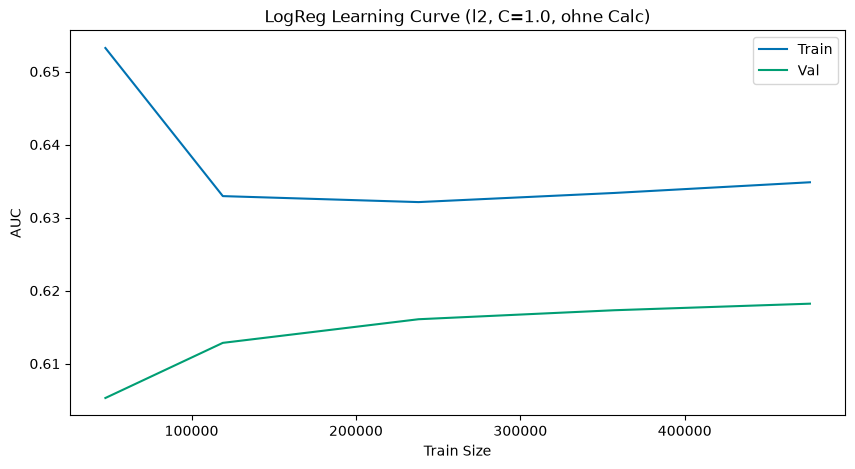

In [439]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_lc_results["train_size"], df_lc_results["auc_train"], label="Train")
ax.plot(df_lc_results["train_size"], df_lc_results["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("LogReg Learning Curve (l2, C=1.0, ohne Calc)")

Text(0.5, 1.0, 'Trainingszeit per Datenmenge (l2, C=1.0, ohne Calc)')

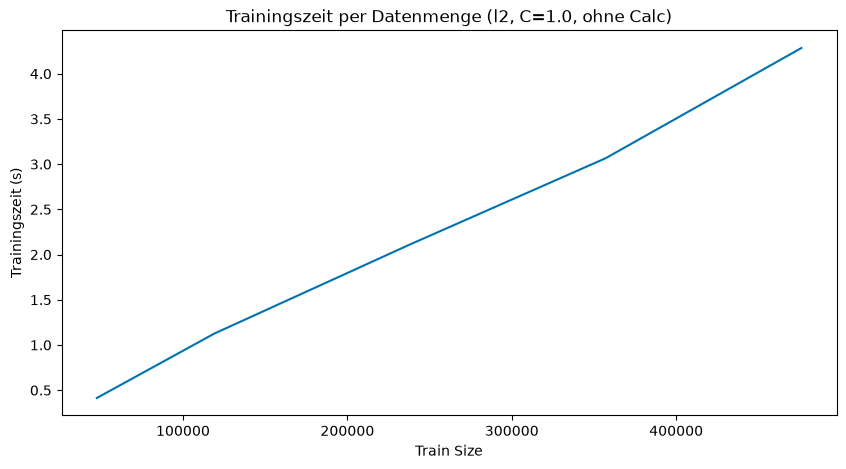

In [440]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_lc_results["train_size"], df_lc_results["fit_time"])
ax.set_xlabel("Train Size")
ax.set_ylabel("Trainingszeit (s)")
ax.set_title("Trainingszeit per Datenmenge (l2, C=1.0, ohne Calc)")

## Optuna Hilfe

Suchräume:

|Parameter|Bereich|
|---|---|
|C|1e-4 bis 1e6 (log)|
|solver|lbfgs / saga|
|l1_ratio|0.0 - 0.1|
|class_weight|None / Balanced|

In [441]:
fixed_params_lr = {
    "random_state": RANDOM_STATE,
    "max_iter": 500,
    "tol": 1e-4,
    "fit_intercept": True
}

In [442]:
def suchraum_params(trial):
    """Suchraum definition"""
    params = {
        "C": trial.suggest_float("C", 1e-4, 1e6, log=True),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0, step=0.1),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"])
    }

    if params["l1_ratio"] == 0.0:
        params["solver"] = "lbfgs"
    else:
        params["solver"] = "saga"

    return params

In [443]:
def params_aus_study(best_params):
    """best_params der Study für Konstruktr"""
    params = dict(best_params)

    if params["l1_ratio"] == 0.0:
        params["solver"] = "lbfgs"
    else:
        params["solver"] = "saga"

    return params

## Mit Calc

In [444]:
def objective_lr_calc(trial):

    modell = make_pipeline(
        (
            clone(prep_calc)
        ),
        (
            LogisticRegression(
                **fixed_params_lr,
                **suchraum_params(trial)
            )
        )
    )

    modell.fit(x_train_lr, y_train)

    return roc_auc_score(y_val, modell.predict_proba(x_val_lr)[:, 1])

In [445]:
# study_lr_calc = optuna.create_study(
#     study_name="logreg_calc",
#     storage="sqlite:///logreg_opti.db",
#     load_if_exists=True,
#     direction="maximize",
#     sampler=TPESampler(seed=RANDOM_STATE),
#     pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=50)
# )

In [446]:
# study_lr_calc.optimize(
#     objective_lr_calc,
#     n_trials=50,
#     timeout= 4*60*60,
#     catch=(Exception, )
# )

In [447]:
study_lr_calc = optuna.load_study(
    study_name = "logreg_calc",
    storage = "sqlite:///logreg_opti.db"
)

In [448]:
pd.Series({
    "best auc val": study_lr_calc.best_value,
    "best gini": 2 * study_lr_calc.best_value - 1,
    "trials": len(study_lr_calc.trials),
    "pruned": len([t for t in study_lr_calc.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_lr_calc.trials if t.state.name == "FAIL"]),
    "best params": study_lr_calc.best_params
})

best auc val                                             0.618268
best gini                                                0.236536
trials                                                         50
pruned                                                          0
fail                                                            0
best params     {'C': 0.008758757178278604, 'l1_ratio': 0.9, '...
dtype: object

In [449]:
study_lr_calc.best_params

{'C': 0.008758757178278604, 'l1_ratio': 0.9, 'class_weight': 'balanced'}

## Ohne Calc

In [450]:
def objective_lr_no_calc(trial):

    modell = make_pipeline(
        (
            clone(prep_no_calc)
        ),
        (
            LogisticRegression(
                **fixed_params_lr,
                **suchraum_params(trial)
            )
        )
    )

    modell.fit(x_train_lr, y_train)

    return roc_auc_score(y_val, modell.predict_proba(x_val_lr)[:, 1])

In [451]:
# study_lr_no_calc = optuna.create_study(
#     study_name="logreg_no_calc",
#     storage="sqlite:///logreg_opti.db",
#     load_if_exists=True,
#     direction="maximize",
#     sampler=TPESampler(seed=RANDOM_STATE),
#     pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=50)
# )

In [452]:
# study_lr_no_calc.optimize(
#     objective_lr_no_calc,
#     n_trials=50,
#     timeout= 4*60*60,
#     catch=(Exception, )
# )

In [453]:
study_lr_no_calc = optuna.load_study(
    study_name = "logreg_no_calc",
    storage = "sqlite:///logreg_opti.db"
)


In [454]:
pd.Series({
    "best auc val": study_lr_no_calc.best_value,
    "best gini": 2 * study_lr_no_calc.best_value - 1,
    "trials": len(study_lr_no_calc.trials),
    "pruned": len([t for t in study_lr_no_calc.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_lr_no_calc.trials if t.state.name == "FAIL"]),
    "best params": study_lr_no_calc.best_params
})

best auc val                                             0.618582
best gini                                                0.237165
trials                                                         50
pruned                                                          0
fail                                                            0
best params     {'C': 0.007257724617055526, 'l1_ratio': 0.5, '...
dtype: object

In [455]:
study_lr_no_calc.best_params

{'C': 0.007257724617055526, 'l1_ratio': 0.5, 'class_weight': 'balanced'}

## Ohne Calc auf 25%

In [456]:
x_train_sub = x_train_lr.iloc[idx_lc_25]
y_train_sub = y_train.iloc[idx_lc_25]

In [457]:
def objective_lr_no_calc_sub(trial):

    modell = make_pipeline(
        (
            clone(prep_no_calc)
        ),
        (
            LogisticRegression(
                **fixed_params_lr,
                **suchraum_params(trial)
            )
        )
    )

    modell.fit(x_train_sub, y_train_sub)

    return roc_auc_score(y_val, modell.predict_proba(x_val_lr)[:, 1])

In [458]:
# study_lr_no_calc_sub = optuna.create_study(
#     study_name="logreg_no_calc_sub",
#     storage="sqlite:///logreg_opti.db",
#     load_if_exists=True,
#     direction="maximize",
#     sampler=TPESampler(seed=RANDOM_STATE),
#     pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=50)
# )

In [459]:
# study_lr_no_calc_sub.optimize(
#     objective_lr_no_calc_sub,
#     n_trials=50,
#     timeout= 4*60*60,
#     catch=(Exception, )
# )

In [460]:
study_lr_no_calc_sub = optuna.load_study(
    study_name = "logreg_no_calc_sub",
    storage = "sqlite:///logreg_opti.db"
)

In [461]:
pd.Series({
    "best auc val": study_lr_no_calc_sub.best_value,
    "best gini": 2 * study_lr_no_calc_sub.best_value - 1,
    "trials": len(study_lr_no_calc_sub.trials),
    "pruned": len([t for t in study_lr_no_calc_sub.trials if t.state.name == "PRUNED"]),
    "fail": len([t for t in study_lr_no_calc_sub.trials if t.state.name == "FAIL"]),
    "best params": study_lr_no_calc_sub.best_params
})

best auc val                                             0.614304
best gini                                                0.228608
trials                                                         50
pruned                                                          0
fail                                                            0
best params     {'C': 0.029135585913319124, 'l1_ratio': 0.8, '...
dtype: object

In [462]:
study_lr_no_calc_sub.best_params

{'C': 0.029135585913319124, 'l1_ratio': 0.8, 'class_weight': 'balanced'}

## Load Study

In [463]:
study_lr_calc_loaded = optuna.load_study(
    study_name = "logreg_calc",
    storage = "sqlite:///logreg_opti.db"
)

study_lr_no_calc_loaded = optuna.load_study(
    study_name = "logreg_no_calc",
    storage = "sqlite:///logreg_opti.db"
)

study_lr_no_calc_sub_loaded = optuna.load_study(
    study_name = "logreg_no_calc_sub",
    storage = "sqlite:///logreg_opti.db"
)

## Best Params again

In [464]:
study_lr_calc_loaded.best_params

{'C': 0.008758757178278604, 'l1_ratio': 0.9, 'class_weight': 'balanced'}

In [465]:
study_lr_no_calc_loaded.best_params

{'C': 0.007257724617055526, 'l1_ratio': 0.5, 'class_weight': 'balanced'}

In [466]:
study_lr_no_calc_sub_loaded.best_params

{'C': 0.029135585913319124, 'l1_ratio': 0.8, 'class_weight': 'balanced'}

## 100% Train

In [467]:
results = []
train_times = {}

In [468]:
name = "L_lr_opt_01"

L_lr_opt_01 = make_pipeline(
    (
        clone(prep_calc)
    ),
    (
        LogisticRegression(
            **fixed_params_lr,
            **params_aus_study(study_lr_calc_loaded.best_params)
        )
    )
)

start = time.time()
L_lr_opt_01.fit(
    x_train_lr, y_train
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_lr_opt_01, x_train_lr, y_train, x_val_lr, y_val, train_times[name])
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [469]:
name = "L_lr_opt_02"

L_lr_opt_02 = make_pipeline(
    (
        clone(prep_no_calc)
    ),
    (
        LogisticRegression(
            **fixed_params_lr,
            **params_aus_study(study_lr_no_calc_loaded.best_params)
        )
    )
)

start = time.time()
L_lr_opt_02.fit(
    x_train_lr, y_train
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_lr_opt_02, x_train_lr, y_train, x_val_lr, y_val, train_times[name])
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [470]:
name = "L_lr_opt_03"

L_lr_opt_03 = make_pipeline(
    (
        clone(prep_no_calc)
    ),
    (
        LogisticRegression(
            **fixed_params_lr,
            **params_aus_study(study_lr_no_calc_sub_loaded.best_params)
        )
    )
)

start = time.time()
L_lr_opt_03.fit(
    x_train_lr, y_train
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_lr_opt_03, x_train_lr, y_train, x_val_lr, y_val, train_times[name])
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [471]:
name = "L_lr_opt_04"

L_lr_opt_04 = make_pipeline(
    (
        clone(prep_no_calc)
    ),
    (
        LogisticRegression(
            **fixed_params_lr,
            **params_aus_study(study_lr_no_calc_sub_loaded.best_params)
        )
    )
)

start = time.time()
L_lr_opt_04.fit(
    x_train_sub, y_train_sub
)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_lr_opt_04, x_train_sub, y_train_sub, x_val_lr, y_val, train_times[name])
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [472]:
pd.DataFrame(results)

,model_idx,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
0,L_lr_opt_01,0.634603,0.618268,0.236536,0.016335,None,276.107993
1,L_lr_opt_02,0.634689,0.618582,0.237165,0.016107,None,222.723249
2,L_lr_opt_03,0.635121,0.618241,0.236481,0.016880,None,272.957249
3,L_lr_opt_04,0.632634,0.614304,0.228608,0.018330,None,57.339332


## Save Models

In [473]:
Modelle = [
    (L_lr_opt_01, "L_lr_opt_01"),
    (L_lr_opt_02, "L_lr_opt_02"),
    (L_lr_opt_03, "L_lr_opt_03"),
    (L_lr_opt_04, "L_lr_opt_04")
]

# for modell, name in Modelle:
#     joblib.dump(modell, f"{name}.joblib")

# Model Testing Notebooks (13, 15, 19, 21, 23)
Quellen: 13_model_testing.ipynb, 15_model_testing_after_full.ipynb, 19_model_testing_after_xgb.ipynb, 21_model_testing_after_hgb.ipynb, 23_model_testing_after_logreg.ipynb

| Herkunft | Neu in diesem Abschnitt |
|---|---|
| NB13 | LogReg mit den GridSearch-Parametern (neu trainiert), CatBoost _t Modelle |
| NB15 | CatBoost _t_full Modelle, L_xgb_07 |
| NB19 | XGBoost L_xgb_opt_01-04 |
| NB21 | HistGradientBoosting L_hgb_opt_01-04 |
| NB23 | gespeicherte LogReg L_lr_opt_01-04, finale Ergebnistabelle |

In [474]:
results = []
train_times = {}

In [475]:
def eval_modell(mod_idx, model, x_train, y_train, x_val, y_val, train_time, best_iter=None):
    """AUC auf Train und Val"""
    auc_train = roc_auc_score(y_train, model.predict_proba(x_train)[:, 1])
    auc_val = roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    return {
        "model_idx": mod_idx,
        "auc_train": auc_train,
        "auc_test": auc_val,
        "gini": 2 * auc_val - 1,
        "delta_auc": auc_train - auc_val,
        "best_iter": best_iter,
        "trainingszeit": train_time
    }

### Loader

In [476]:
def load_cbm(name):
    """cbm modell laden"""
    modell = CatBoostClassifier()
    modell.load_model(f"{name}.cbm")
    return modell

In [477]:
def load_xgb(name):
    """xgb json laden"""
    modell = XGBClassifier()
    modell.load_model(f"{name}.json")
    return modell

In [478]:
def load_jlib(name):
    """hgb joblib laden"""
    return joblib.load(f"{name}.joblib")

## Logreg (GridSearch)
Nicht gespeichert, deswegen nochmal training mit:

|Parameter|Wert|
|---|---|
|C|0.01|
|class_weight|balanced|
|fit_intercept|False|
|penalty|None|
|solver|newton-cg|
|tol|0.01|

In [479]:
L_logreg_test_t = make_pipeline(
    make_column_transformer(
            (
                make_pipeline(
                    SimpleImputer(strategy="median", add_indicator=True),
                    StandardScaler()
                ),
                num_cols_no_calc
            ),
            (
                OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
                low_kard_cols
            ),
            (
                TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
                high_kard_cols
            ),
            (
                "passthrough",
                bin_cols_no_calc
            )
        ),
    LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        C=0.01,
        class_weight="balanced",
        fit_intercept=False,
        penalty=None,
        solver="newton-cg",
        tol=0.01
        )
)

In [480]:
name = "L_logreg_test_t"

start = time.time()
L_logreg_test_t.fit(x_train, y_train)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_logreg_test_t, x_train, y_train, x_test, y_test, train_times[name], best_iter=None)
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1443: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  wa

In [481]:
L_logreg_test_tv = make_pipeline(
    make_column_transformer(
            (
                make_pipeline(
                    SimpleImputer(strategy="median", add_indicator=True),
                    StandardScaler()
                ),
                num_cols_no_calc
            ),
            (
                OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
                low_kard_cols
            ),
            (
                TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE),
                high_kard_cols
            ),
            (
                "passthrough",
                bin_cols_no_calc
            )
        ),
    LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        C=0.01,
        class_weight="balanced",
        fit_intercept=False,
        penalty=None,
        solver="newton-cg",
        tol=0.01
        )
)

In [482]:
name = "L_logreg_test_tv"

start = time.time()
L_logreg_test_tv.fit(x_train_val, y_train_val)
train_times[name] = time.time()- start

results.append(
    eval_modell(name, L_logreg_test_tv, x_train_val, y_train_val, x_test, y_test, train_times[name], best_iter=None)
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1443: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  wa

## Logreg gespeichert

In [483]:
L_lr_opt_01 = load_jlib("L_lr_opt_01")
L_lr_opt_02 = load_jlib("L_lr_opt_02")
L_lr_opt_03 = load_jlib("L_lr_opt_03")
L_lr_opt_04 = load_jlib("L_lr_opt_04")

In [484]:
results.append(
    eval_modell("L_lr_opt_01", L_lr_opt_01, x_train, y_train, x_test, y_test, None, best_iter=L_lr_opt_01[-1].n_iter_[0])
)
results.append(
    eval_modell("L_lr_opt_02", L_lr_opt_02, x_train, y_train, x_test, y_test, None, best_iter=L_lr_opt_02[-1].n_iter_[0])
)
results.append(
    eval_modell("L_lr_opt_03", L_lr_opt_03, x_train, y_train, x_test, y_test, None, best_iter=L_lr_opt_03[-1].n_iter_[0])
)
results.append(
    eval_modell("L_lr_opt_04", L_lr_opt_04, x_train, y_train, x_test, y_test, None, best_iter=L_lr_opt_04[-1].n_iter_[0])
)

In [485]:
angepasste_params_lr = [
    "C",
    "solver",
    "l1_ratio",
    "class_weight"]

lr_modelle = {
    "L_lr_opt_01": L_lr_opt_01,
    "L_lr_opt_02": L_lr_opt_02,
    "L_lr_opt_03": L_lr_opt_03,
    "L_lr_opt_04": L_lr_opt_04
}

lr_params = {
    name: {param: wert for param, wert in modell[-1].get_params().items() if param in angepasste_params_lr}
    for name, modell in lr_modelle.items()
}

pd.DataFrame(lr_params)

,L_lr_opt_01,L_lr_opt_02,L_lr_opt_03,L_lr_opt_04
C,0.008759,0.007258,0.029136,0.029136
class_weight,balanced,balanced,balanced,balanced
l1_ratio,0.9,0.5,0.8,0.8
solver,saga,saga,saga,saga


## Catboost gespeichert

In [486]:
L_cb_test_01_t = load_cbm("L_cb_opt_01")
L_cb_test_02_t = load_cbm("L_cb_opt_02")
L_cb_test_03_t = load_cbm("L_cb_opt_03")

In [487]:
results.append(
    eval_modell("L_cb_test_01_t", L_cb_test_01_t, x_train_cb, y_train, x_test_cb, y_test, None, best_iter=L_cb_test_01_t.get_best_iteration())
)
results.append(
    eval_modell("L_cb_test_02_t", L_cb_test_02_t, x_train_no_calc_cb, y_train, x_test_no_calc_cb, y_test, None, best_iter=L_cb_test_02_t.get_best_iteration())
)
results.append(
    eval_modell("L_cb_test_03_t", L_cb_test_03_t, x_train_no_calc_cb, y_train, x_test_no_calc_cb, y_test, None, best_iter=L_cb_test_03_t.get_best_iteration())
)

In [488]:
angepasste_params = [
    "learning_rate", 
    "depth", 
    "l2_leaf_reg", 
    "random_strength", 
    "one_hot_max_size", 
    "leaf_estimation_iterations", 
    "auto_class_weights", 
    "bootstrap_type", 
    "bagging_temperature", 
    "subsample"]

In [489]:
{param : wert for param, wert in L_cb_test_01_t.get_all_params().items() if param in angepasste_params}

{'one_hot_max_size': 105,
 'l2_leaf_reg': 8.593733788,
 'random_strength': 0.01142319106,
 'subsample': 0.9178574681,
 'depth': 7,
 'auto_class_weights': 'Balanced',
 'learning_rate': 0.04761112109,
 'leaf_estimation_iterations': 2,
 'bootstrap_type': 'Bernoulli'}

In [490]:
{param : wert for param, wert in L_cb_test_02_t.get_all_params().items() if param in angepasste_params}

{'one_hot_max_size': 10,
 'l2_leaf_reg': 3.914318323,
 'random_strength': 0.5015455484,
 'subsample': 0.7854715586,
 'depth': 4,
 'auto_class_weights': 'None',
 'learning_rate': 0.1759581715,
 'leaf_estimation_iterations': 2,
 'bootstrap_type': 'Bernoulli'}

In [491]:
{param : wert for param, wert in L_cb_test_03_t.get_all_params().items() if param in angepasste_params}

{'one_hot_max_size': 10,
 'l2_leaf_reg': 21.72735786,
 'random_strength': 1.770355582,
 'depth': 9,
 'bagging_temperature': 0.004430230707,
 'auto_class_weights': 'None',
 'learning_rate': 0.07522925735,
 'leaf_estimation_iterations': 3,
 'bootstrap_type': 'Bayesian'}

## Catboost full saved

In [492]:
L_cb_test_01_t_full = load_cbm("L_cb_opt_01_full")
L_cb_test_02_t_full = load_cbm("L_cb_opt_02_full")
L_cb_test_03_t_full = load_cbm("L_cb_opt_03_full")

In [493]:
results.append(
    eval_modell("L_cb_test_01_t_full", L_cb_test_01_t_full, x_train_cb, y_train, x_test_cb, y_test, None, best_iter=L_cb_test_01_t_full.get_best_iteration())
)
results.append(
    eval_modell("L_cb_test_02_t_full", L_cb_test_02_t_full, x_train_no_calc_cb, y_train, x_test_no_calc_cb, y_test, None, best_iter=L_cb_test_02_t_full.get_best_iteration())
)
results.append(
    eval_modell("L_cb_test_03_t_full", L_cb_test_03_t_full, x_train_no_calc_cb, y_train, x_test_no_calc_cb, y_test, None, best_iter=L_cb_test_03_t_full.get_best_iteration())
)

In [494]:
{param : wert for param, wert in L_cb_test_01_t_full.get_all_params().items() if param in angepasste_params}

{'one_hot_max_size': 10,
 'l2_leaf_reg': 2.430516958,
 'random_strength': 0.001188852475,
 'subsample': 0.5657526255,
 'depth': 5,
 'auto_class_weights': 'Balanced',
 'learning_rate': 0.06338750571,
 'leaf_estimation_iterations': 3,
 'bootstrap_type': 'Bernoulli'}

In [495]:
{param : wert for param, wert in L_cb_test_02_t_full.get_all_params().items() if param in angepasste_params}

{'one_hot_max_size': 18,
 'l2_leaf_reg': 7.076480389,
 'random_strength': 0.8387745023,
 'depth': 8,
 'bagging_temperature': 1.815809965,
 'auto_class_weights': 'None',
 'learning_rate': 0.05445057526,
 'leaf_estimation_iterations': 5,
 'bootstrap_type': 'Bayesian'}

In [496]:
{param : wert for param, wert in L_cb_test_03_t_full.get_all_params().items() if param in angepasste_params}

{'one_hot_max_size': 105,
 'l2_leaf_reg': 18.03974724,
 'random_strength': 0.005187373608,
 'subsample': 0.811945498,
 'depth': 7,
 'auto_class_weights': 'None',
 'learning_rate': 0.1062427759,
 'leaf_estimation_iterations': 1,
 'bootstrap_type': 'Bernoulli'}

## L_xgb_07
ging als sehr starkes Modell beim testing hervor:
- target encoding
- calc drop

In [497]:
transf_xgb_07 = make_column_transformer(
    ("drop", calc_cols),
    (TargetEncoder(cv=5, random_state=RANDOM_STATE), high_kard_cols),
    ("passthrough", [c for c in feat_cols_no_calc if c not in high_kard_cols]),
    verbose_feature_names_out=False
).set_output(transform="pandas")

x_train_07 = transf_xgb_07.fit_transform(x_train, y_train)[feat_cols_no_calc]
x_val_07 = transf_xgb_07.transform(x_val)[feat_cols_no_calc]
x_test_07 = transf_xgb_07.transform(x_test)[feat_cols_no_calc]

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [498]:
xgb_07 = XGBClassifier(
    booster="gbtree",
    random_state=RANDOM_STATE,
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True,
    n_estimators=5000,
    learning_rate=0.03,
    early_stopping_rounds=100
)

In [499]:
name = "L_xgb_07"

start = time.time()
xgb_07.fit(
    x_train_07, y_train,
    eval_set=[(x_train_07, y_train), (x_val_07, y_val)],
    verbose=250
)
train_times[name] = time.time() - start

[0]	validation_0-auc:0.62127	validation_1-auc:0.60249
[250]	validation_0-auc:0.70827	validation_1-auc:0.63397
[342]	validation_0-auc:0.72065	validation_1-auc:0.63334


In [500]:
results.append(
    eval_modell(name, xgb_07, x_train_07, y_train, x_test_07, y_test,
                train_times[name], best_iter=xgb_07.best_iteration)
)

## XGB Modelle

In [501]:
L_xgb_opt_01 = load_xgb("L_xgb_opt_01")
L_xgb_opt_02 = load_xgb("L_xgb_opt_02")
L_xgb_opt_03 = load_xgb("L_xgb_opt_03")
L_xgb_opt_04 = load_xgb("L_xgb_opt_04")

In [502]:
results.append(
    eval_modell("L_xgb_opt_01", L_xgb_opt_01, x_train, y_train, x_test, y_test, None, best_iter=L_xgb_opt_01.best_iteration)
)
results.append(
    eval_modell("L_xgb_opt_02", L_xgb_opt_02, x_train_no_calc, y_train, x_test_no_calc, y_test, None, best_iter=L_xgb_opt_02.best_iteration)
)
results.append(
    eval_modell("L_xgb_opt_03", L_xgb_opt_03, x_train_te, y_train, x_test_te, y_test, None, best_iter=L_xgb_opt_03.best_iteration)
)
results.append(
    eval_modell("L_xgb_opt_04", L_xgb_opt_04, x_train_no_calc_te, y_train, x_test_no_calc_te, y_test, None, best_iter=L_xgb_opt_04.best_iteration)
)

In [503]:
study_names = {
    "L_xgb_opt_01": "XGBoost_calc",
    "L_xgb_opt_02": "XGBoost_no_calc",
    "L_xgb_opt_03": "XGBoost_calc_te",
    "L_xgb_opt_04": "XGBoost_no_calc_te"
}

xgb_params = {
    modell: optuna.load_study(study_name=studname, storage="sqlite:///xgboost_opti.db").best_params
    for modell, studname in study_names.items()
}

pd.DataFrame(xgb_params)

,L_xgb_opt_01,L_xgb_opt_02,L_xgb_opt_03,L_xgb_opt_04
learning_rate,0.038768,0.077903,0.018784,0.068409
max_depth,6.000000,7.000000,6.000000,4.000000
min_child_weight,167.926688,126.488318,26.805781,123.572582
gamma,0.033641,0.493110,0.004322,1.226278
reg_lambda,0.462911,2.245830,42.387085,1.262450
reg_alpha,9.390737,0.055327,0.124704,0.389757
max_delta_step,2.000000,7.000000,7.000000,4.000000
subsample,0.940044,0.800055,0.610842,0.871835
colsample_bynode,0.799588,0.896860,0.674854,0.697225
scale_pos_weight,5.000000,1.000000,1.000000,1.000000


## HGB Modelle

In [504]:
L_hgb_opt_01 = load_jlib("L_hgb_opt_01")
L_hgb_opt_02 = load_jlib("L_hgb_opt_02")
L_hgb_opt_03 = load_jlib("L_hgb_opt_03")
L_hgb_opt_04 = load_jlib("L_hgb_opt_04")

In [505]:
results.append(
    eval_modell("L_hgb_opt_01", L_hgb_opt_01, x_train_hgb, y_train, x_test_hgb, y_test, None, best_iter=L_hgb_opt_01.n_iter_)
)
results.append(
    eval_modell("L_hgb_opt_02", L_hgb_opt_02, x_train_hgb_no_calc, y_train, x_test_hgb_no_calc, y_test, None, best_iter=L_hgb_opt_02.n_iter_)
)
results.append(
    eval_modell("L_hgb_opt_03", L_hgb_opt_03, x_train_hgb, y_train, x_test_hgb, y_test, None, best_iter=L_hgb_opt_03.n_iter_)
)
results.append(
    eval_modell("L_hgb_opt_04", L_hgb_opt_04, x_train_hgb_no_calc, y_train, x_test_hgb_no_calc, y_test, None, best_iter=L_hgb_opt_04.n_iter_)
)

In [506]:
angepasste_params_hgb = [
    "learning_rate",
    "min_samples_leaf",
    "l2_regularization",
    "max_features",
    "max_bins",
    "interaction_cst",
    "validation_fraction",
    "n_iter_no_change",
    "tol",
    "max_leaf_nodes",
    "max_depth"]

hgb_modelle = {
    "L_hgb_opt_01": L_hgb_opt_01,
    "L_hgb_opt_02": L_hgb_opt_02,
    "L_hgb_opt_03": L_hgb_opt_03,
    "L_hgb_opt_04": L_hgb_opt_04
}

hgb_params = {
    name: {param: wert for param, wert in modell.get_params().items() if param in angepasste_params_hgb}
    for name, modell in hgb_modelle.items()
}

pd.DataFrame(hgb_params)

,L_hgb_opt_01,L_hgb_opt_02,L_hgb_opt_03,L_hgb_opt_04
interaction_cst,NaN,NaN,NaN,NaN
l2_regularization,1.026213e+01,52.458189,7.188748e+02,4.711124e-03
learning_rate,1.452174e-02,0.004109,2.158115e-01,2.468715e-02
max_bins,2.310000e+02,202.000000,1.990000e+02,1.440000e+02
max_depth,NaN,NaN,6.000000e+00,6.000000e+00
max_features,2.477600e-01,0.296687,2.160953e-01,2.469807e-01
max_leaf_nodes,3.600000e+01,32.000000,NaN,NaN
min_samples_leaf,5.975000e+03,6833.000000,1.850000e+02,1.650000e+02
n_iter_no_change,3.800000e+01,40.000000,1.500000e+01,3.400000e+01
tol,1.209587e-08,0.000001,2.365868e-10,8.370655e-08


## Evaluation

In [507]:
df_results = pd.DataFrame(results).sort_values("auc_test", ascending=False)
df_results

,model_idx,auc_train,auc_test,gini,delta_auc,best_iter,trainingszeit
16,L_xgb_opt_04,0.685711,0.649561,0.299121,0.036151,565.0,NaN
14,L_xgb_opt_02,0.680683,0.649495,0.298989,0.031189,139.0,NaN
18,L_hgb_opt_02,0.679824,0.649377,0.298754,0.030447,2469.0,NaN
13,L_xgb_opt_01,0.736660,0.648169,0.296337,0.088492,729.0,NaN
17,L_hgb_opt_01,0.691162,0.647739,0.295479,0.043423,669.0,NaN
15,L_xgb_opt_03,0.712847,0.647583,0.295166,0.065264,782.0,NaN
11,L_cb_test_03_t_full,0.685571,0.647561,0.295121,0.038010,789.0,NaN
20,L_hgb_opt_04,0.696819,0.647474,0.294947,0.049345,365.0,NaN
10,L_cb_test_02_t_full,0.692775,0.647385,0.294769,0.045390,558.0,NaN
7,L_cb_test_02_t,0.664717,0.647273,0.294546,0.017444,518.0,NaN


In [508]:
train_times_nb23 = {
    "L_cb_test_01_t": 24.047395,
    "L_cb_test_02_t": 52.476140,
    "L_cb_test_03_t": 192.045585,
    "L_cb_test_01_t_full": 88.705495,
    "L_cb_test_02_t_full": 116.162328,
    "L_cb_test_03_t_full": 124.465556,
    "L_xgb_opt_01": 47.402708,
    "L_xgb_opt_02": 12.787595,
    "L_xgb_opt_03": 62.368462,
    "L_xgb_opt_04": 25.698286,
    "L_hgb_opt_01": 32.303958,
    "L_hgb_opt_02": 85.016068,
    "L_hgb_opt_03": 5.613486,
    "L_hgb_opt_04": 11.549956,
    "L_lr_opt_01": 282.010512,
    "L_lr_opt_02": 230.930150,
    "L_lr_opt_03": 281.836698,
    "L_lr_opt_04": 58.583413,
}

for modell,tt in train_times_nb23.items():
    df_results.loc[df_results["model_idx"] == modell, "trainingszeit"] = tt

df_results

,model_idx,auc_train,auc_test,gini,delta_auc,best_iter,trainingszeit
16,L_xgb_opt_04,0.685711,0.649561,0.299121,0.036151,565.0,25.698286
14,L_xgb_opt_02,0.680683,0.649495,0.298989,0.031189,139.0,12.787595
18,L_hgb_opt_02,0.679824,0.649377,0.298754,0.030447,2469.0,85.016068
13,L_xgb_opt_01,0.736660,0.648169,0.296337,0.088492,729.0,47.402708
17,L_hgb_opt_01,0.691162,0.647739,0.295479,0.043423,669.0,32.303958
15,L_xgb_opt_03,0.712847,0.647583,0.295166,0.065264,782.0,62.368462
11,L_cb_test_03_t_full,0.685571,0.647561,0.295121,0.038010,789.0,124.465556
20,L_hgb_opt_04,0.696819,0.647474,0.294947,0.049345,365.0,11.549956
10,L_cb_test_02_t_full,0.692775,0.647385,0.294769,0.045390,558.0,116.162328
7,L_cb_test_02_t,0.664717,0.647273,0.294546,0.017444,518.0,52.476140


# Notizen

Gesammelte Notizen der Eval Notebooks

## Notizen 01

Aus der Aufgabenstellung:
Ziel des Projektes ist die Entwicklung eines Machine Learning Modells für den Datensatz der "Porto Seguro’s Safe Driver Prediction". Dabei handelt es sich um Daten eines Autoversicherers aus Brasilien. Basierend auf den gegebenen Daten soll (die Wahrscheinlichkeit) vorhergesagt werden, ob Kundinnen des Versicherers gegenüber diesem Ansprüche wegen einer Schadensregulierung erheben werden.

Infos zusammengefassst:
- 58 cols
- 595212 rows
- Missing Values: 846458
- Cols mit Missing Values: 13

|Col|MVs|
|---|---:|
|ps_ind_02_cat|216
|ps_ind_04_cat|83
|ps_ind_05_cat|5809
|ps_reg_03|107772
|ps_car_01_cat|107
|ps_car_02_cat|5
|ps_car_03_cat|411231
|ps_car_05_cat|266551
|ps_car_07_cat|11489
|ps_car_09_cat|569
|ps_car_11|5
|ps_car_12|1
|ps_car_14|42620

- Rows mit Missing Values: 470281
- Kaggle erwähnt -1 noch als indikator einer Missing Values, aber diese Werte wurden für OpenML scheinbar schon als na kodiert.
- postfixe der feats für dtypes:

|postfix|dtype|
|---|---|
|"bin"|binary|
|"cat"|categorical|
|none|cont or ord|

- suffixe der feats für ähnliche Gruppen

|suffix|Gruppe|
|---|---|
|"ind"||
|"reg"||
|"car"||
|"calc"||

- target : wether or not a claim was filed

- Allem Anschein nach handelt es sich bei dem OpenML df um das train dataset von Kaggle.

## Notizen 04

### Verteilung der target Klasse 
|target value|Prozentualer Anteil|
|---|---|
|0|96.36 %|
|1|3.64%|

- Sehr ungleiche Verteilung der target Klasse, könnte für Modelltraining wichtig werden.

### Sanity Check Missing Values
- Alle Missing Values sind als solche geladen worden, nicht wie in Kaggle als -1

### Missing Values pro Feature
- ps_car_03_cat(69.09% MV) und ps_car_05_cat(44.78% MV) sind stark von fehlenden Werten betroffen
- Alle anderen spalten verorten sich bei unter 20% Missing Values

### Missing als Prädiktor erwägbar
- Schwache unterschiede bei dem Vergleich der MV rows und vorhandenen Rows der 4 features mit den meisten Missing Values

### Sanity Check Missing Value Anteile der Splits
- Abweichung in Missing Value Anteilen der Splits ist vernachlässigbar klein. Splits sollte somit verwendet werden können.

### Kardinalität der cat Features
- Viele features mit 2 klassenausprägungen, die meisten features im Bereich unter 20 klassen, ps_car_11_cat hat 104 klassen
- ps_car_11_cat hat mindestens 1000 Einträge pro Klasse, aber es gibt vereinzelt sehr große klassen (größte klasse: 104 mit 85083 ; zweit größte Klasse: 103 mit 24262 Klassen)
- Niedrige Kardinalität wahrscheinlich gut für one hot
- hoch kardinal eventuell target encoding?

### Verteilung der bin features
- Die meisten bin features scheinen sehr unbalanciert, ps_ind_[10, 11, 12, 13]_bin haben 1 Anteil von unter 1% 
- 6/7, 16/17 und 16/18 weisen recht starke negative korrelation auf

### Verteilung cont features


### IQR Analyse
- Wahrscheinlich unwichtig weil Versicherungsdaten ausreißer meist true sein sollten.
- Robuste modelle für mv wahrscheinlich besser

###  Korr mit target
- wenig lineare zusammenhänge mit target

### Interkorr von num features
- reg_03/reg_02 weisen starke korrelation auf

### ps_calc_
- Ich hatte in einer beispielarbeit gelesen, dass auf calc verzichtet wurde, linear sind kaum interkorr order targetkorr zu erkennen
- betrachtung des modells ohne calc und betrachtung nicht linearer zusammenhänge könnte interessant sein

### Sanity check Duplikate
- Keine Duplikate

### Gruppenbetrachtung
- ps_ind_16/17/18 könnten redundant sein?

## Notizen 05

- add indicator um mv spalten anzuhängen
- simpleimpute mit median, weniger anfällig für ausreißer (vllt KNNimputer versuchen, aber bei vielen MV eventuell ungenau)
- hilfreich für später?: https://scikit-learn.org/stable/auto_examples/compose/plot_digits_pipe.html
- da transformer array ausgibt muss später feature mit prepro.get_feature_names_out() und koeffizient mit model.coef_[0] angesehen werden (also als df verknüpfen) ; in zukunft aber eh in einer pipeline


## Notizen 06

- Gini ist nur eine lineare transformation der AUC. Also können wir eigentlich beides wählen. Wenn wir uns möglichst an die Kaggle Competition halten wollen, benutzen wir Gini. Dennoch unterscheidet es sich leicht von der normalized Gini von Kaggle, da hier durch einen bestmöglichen Gini geteilt wird. 
- Wenn die Zeit bleibt schaue ich mal, ob AUC oder Gini einen unterschiedlichen einfluss auf Hyperparameter haben.


- Zunächst nur Baseline also ertsmal einfach ganz simples Preprocessing, Modell training pipeline. To beexpanded upon. Lernkurven etc im späteren verlauf.


- Ich nehme 01 als komplette baseline also keinerlei modellanpassungen. Classweights, Sampling etc später.

## Notizen 07

Punkte aus der EDA, die ich hier behandeln möchte:
|Gedanke|Umsetzung|
|---|---|
|One Hot encodings kolinearität|drop=first im encoding|
|ps_ind_[06,07,08,09]_bin scheinen wie one hots zu funktionieren|eine spalte droppen (andere liefern info zu dieser Spalte)|
|ps_ind_[16,17 bzw 16,18]_bin korrelieren stark negativ|könnte reduziert werden|
|ps_ind_12_bin, ps_ind_14 korrelieren stark|mögliche Redundanz, könnte reduziert werden|
|ps_reg_[02,03] korrelieren stark|mögliche Redundanz, könnte reduziert werden|
|ps_calc_* zeigt kaum signal (in jeder EDA befunden)|könnte gedroppt werden (kaum interkorrelation)|
|Starke Klassenimbalance von target|class_weight="balanced" könnten helfen|


Punkte aus der Aufgabenstellung, die ich hier behandeln möchte:
- Learning Curve vor Modelltraining

Modelle im Notebook:
|Modell Index|Spezifikation
|---|---|
|L_lr_01|Simple aus 06 als Bezugspunkt|
|L_lr_02|class_weight="balanced"|
|L_lr_03|Drop first in onehot|
|L_lr_04|Drop first in onehot und ps_ind_06_bin drop|
|L_lr_05|Umgang mit korrelationen prüfen|
|L_lr_06|calc droppen|
|L_lr_07|Alles Zusammen nicht nötig, bis jetzt 06 am besten|

Bei allen an 02 class_weight="balanced"

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

## Notizen 08

Punkte aus der EDA, die ich hier behandeln möchte:
|Gedanke|Umsetzung|
|---|---|
|||


Punkte aus der Aufgabenstellung, die ich hier behandeln möchte:
- Learning Curve vor Modelltraining

Modelle im Notebook:
|Modell Index|Spezifikation
|---|---|
|L_xgb_01|Simple aus 06 als Bezugspunkt|
|L_xgb_02|nativ verarbeiten mit mehr kapazität|
|L_xgb_03|enable categorical unterschied? + calc drop learning curves|
|L_xgb_04|klassenimbalance über scale_pos_weights|
|L_xgb_05|real no calc weil vorin fehler gemacht|
|L_xgb_06|beste kombi mit target encoding|
|L_xgb_07|06 ohne calc|


- https://xgboost.readthedocs.io/en/stable/
- https://mljourney.com/xgboost-feature-importance-comprehensive-guide/
- https://xgboost.readthedocs.io/en/latest/r_docs/R-package/docs/reference/xgb.importance.html
- https://stackoverflow.com/questions/37627923/how-to-get-feature-importance-in-xgboost


## Notizen 09

Punkte aus der EDA, die ich hier behandeln möchte:
|Gedanke|Umsetzung|
|---|---|
|One Hot Kolineartät|drop first und möglicherweise ps_ind_06_bin|
|ps_calc_* mkaum signal|drop möglich|
|Klassenimbalance|calss weight balanced|

Punkte aus der Aufgabenstellung, die ich hier behandeln möchte:
- Learning Curve vor Modelltraining

Modelle im Notebook:
|Modell Index|Spezifikation
|---|---|
|L_svm_01|Simple aus 06 als Bezugspunkt|
|L_svm_02|Mit besserer Kapazität(C, dual)|
|L_svm_03|class weight balanced|
|L_svm_04|drop first in bis jetzt bestes (mk 2 mit drop ps_ind_06_bin wie in 07)|
|L_svm_05|scaler auf allem laufen lassen --> weniger hochvarianz|
|L_svm_06|calc drop auf bisher bestem|


- SVC hat kein predict_proba
- also decision function in eval


- Hsu, C. W., Chang, C. C., & Lin, C. J. (2003). A practical guide to support vector classification.


## Notizen 10

Da die logistische Regression bei den anderen bis jetzt besser gelaufen ist, werde ich wahrscheinlich mehr Zeit in CatBoost stecken. Deshalb versuche ich für LogReg zunächst die Optimierung über GridSearch.

Frage die ich mir Stelle: wenn ich für cv in gridsearch die idx der train und val datasets angebe, verschlechtert das die Leistung der search im gegenzug zu einem kfold?


Ressourcen [Aufrufdatum: 10.08.2026]:
- https://www.geeksforgeeks.org/machine-learning/how-to-optimize-logistic-regression-performance/
- https://uva-applied-ml.readthedocs.io/en/latest/notebooks/5_log_reg_gs.html
- https://sklearner.com/scikit-learn-grid-search-logisticregression/
- https://stackoverflow.com/questions/37689942/grid-search-finding-parameters-for-auc
- https://sklearner.com/sklearn-logisticregression-c-parameter/
- https://sklearner.com/sklearn-logisticregression-tol-parameter/
- https://sklearner.com/sklearn-logisticregression-class_weight-parameter/
- https://sklearner.com/sklearn-logisticregression-fit_intercept-parameter/
- https://sklearner.com/scikit-learn-gridsearchcv-cv-parameter/






## Notizen 11

- Ich habe gelesen, dass CatBoost selbst die Missing Values in numerischen Spalten verwenden kann, aber in kategorischen Spalten Fehler entstehen. Ich versuche es erstmal und schaue was passiert.
- L_cb_01 zeigt error wegen nan in cat features, ich schreibe eine hilfsfunktion um nan zu ersetzen
- col transformer muss df zurück geben wegen cat features von catboost
- Ich habe in 02 versucht wegen der AUfgabernstellung irgendwie eine pipeline zu benutzen, aber ich glaube momentan das macht für catboost wenig sinn. ich muss zum beispiel für das eval set sowieso händisch preprocessen.
- cat boost info wird bei jedem fit überschrieben, ich könnte es für jedes Modell anders speichern, aber ich denke in der experimentierphase wird dies das repo nur zu müllen. ich kümmere mich später via gitignore darum. bei der optimierung könnte ich das einsetzen um alle wichtigen daten zu speichern
- ich bin auf eine sehr alte meldung gestoßen, dass es wohl probleme mit dem panday category dtype gebe. ich überprüfe das mal indem ich dei cat features in objects umwandle
- Der Bug scheint hier keinerlei Einfluss zu nehmen also möglicherweise gefixt.
- kann leider nicht über gpu trainieren (kein cuda kein spaß)
- Plain ist wohl default, ordered führt zu extrem längerer prognostizierter train time.
- ordered scheint hier wenig bis keinen einfluss zu zeigen, aber höhere train times. Ich könnte wenn die Zeit es zulässt noch einmal einen optimierungsvergleichen machen.
- muss dran denken die cb und no calc variablen in df vorbereitung aufzunehmen
- calc drop bringt leichte verschlechterung in dem modell hier, aber die auf diff wird minimiert heißt mittel gegen overfitting potentiell
- catboost hat ein problem mit copy

Entscheidungen für die Hyperparameter Opti:
- Plain Boosting Type mit und ohne calc
- Wenn Zeit bleibt eventuell Ordered ohne calc laufen lassen, aber das wird wahrscheinlich extrem lange dauern
- Subsamplegrößen:

|Modell|Subsample|
|---|---|
|Plain mit Calc|75%|
|Plain ohne Calc|100% oder 75%|
|Ordered ohne Calc|75%|

Modelle:

|Modell IDX|Beschreibung|
|---|---|
|L_cb_01|Natives Modell ohne nan behandlung als Experiment (gescheitert)|
|L_cb_02|Natives Modell mit ersatz für nan in cat features, pipeline (gescheitert)|
|L_cb_03|Natives Modell, händisches Preprocessing, nan ersetzt in cat|
|L_cb_04|03 aber cat als object dtype|
|L_cb_05|early stop, early stopping rounds, logloss setze ich selber, thread_count aus -1 für effizienz, allow writing files auf false um nicht catboost info müll zu erzeugen. Also alle für mich erstmal fixen parameter und sonst default werte (wegen early stop setze ich iterations etwas höher als default 1000)|
|L_cb_06|boosting_type = plain|
|L_cb_07|boosting_type = ordered|
|L_cb_08|ps_calc_* drop|





Ressourcen [Aufrufdatun: 12.08.2026]:
- https://catboost.ai/docs/en/concepts/python-reference_catboostclassifier
- https://catboost.ai/docs/en/references/training-parameters/common
- https://catboost.ai/docs/en/references/eval-metric__supported-metrics
- https://www.geeksforgeeks.org/machine-learning/catboost-parameters-and-hyperparameters/
- https://catboost.ai/docs/en/concepts/parameter-tuning
- https://mljourney.com/catboost-classifier-complete-guide/
- https://www.geeksforgeeks.org/machine-learning/catboost-cross-validation-and-hyperparameter-tuning/
- https://catboost.ai/docs/en/concepts/algorithm-missing-values-processing
- https://www.geeksforgeeks.org/machine-learning/handling-missing-values-with-catboost/
- https://stackoverflow.com/questions/70849918/missing-values-in-categorical-variables-in-catboost-python
- https://catboost.ai/docs/en/references/training-parameters/output
- https://catboost.ai/docs/en/concepts/python-reference_catboost_fit
- https://github.com/catboost/catboost/issues/814
- https://github.com/catboost/catboost/issues/757

## Notizen 12

- Weil ich auf cpu trainiere setze ich border_count fix auf 254. (Soll auf GPU größeren einfluss auf laufzeit haben, als auf cpu)
- Mit log=True den suchraum um den zahlenbereich nicht linear zu halten
- bagging temp oder subsample von bootstrap type abhängig
- storage über den sqlite, kopiere aus quell, erstellt eine db. (eine db für mehrere deshalb nicht study name als name und load if exists) muss ich in die .gitignore einfügen
- direction max weil höhere auc
- TPE sampler für tree based
- medianpruner (scheint mir am meisten straight forward)
- best iters lagen meist über 200 also nehme ich das mal als warmup um den early stop etwas hinaus zu zögern
- n_trials funktioniert etwas wie iterations, ich nehme erstmal 50 wenn ich ein timelimit stelle wird das wohl kaum erreicht.
- time limit setze ich pro versuch mal auf 3 stunden. also stunden * minuten * sekunden : 3 * 60 * 60
- catch um errors zu überspringen
- pc ist im ersten durchlauf abgestürzt ich muss nochmal runnen
- Nächster Schritt: Neues Notebook mit logreg und diesen modellen auf test testen + diese modelle mit den parametern dann nochmal auf train+val trainieren und auif test testen.



## Ressourcen [Aufrufdatun 13.08.2026]:
- https://forecastegy.com/posts/catboost-hyperparameter-tuning-guide-with-optuna/
- https://catboost.ai/docs/en/references/training-parameters/output
- https://www.geeksforgeeks.org/machine-learning/catboost-cross-validation-and-hyperparameter-tuning/
- https://mljourney.com/catboost-classifier-complete-guide/
- https://catboost.ai/docs/en/concepts/parameter-tuning
- https://www.geeksforgeeks.org/machine-learning/catboost-parameters-and-hyperparameters/
- https://catboost.ai/docs/en/references/training-parameters/common
- https://catboost.ai/docs/en/concepts/python-reference_catboostclassifier
- https://github.com/catboost/catboost/blob/master/catboost/tutorials/hyperparameters_tuning/hyperparameters_tuning.ipynb
- https://github.com/optuna/optuna-examples/blob/main/catboost/catboost_pruning.py
- https://optuna-integration.readthedocs.io/en/latest/reference/generated/optuna_integration.CatBoostPruningCallback.html
- https://optuna.readthedocs.io/en/stable/tutorial/20_recipes/001_rdb.html
- https://optuna.readthedocs.io/en/stable/reference/pruners.html
- https://optuna.readthedocs.io/en/stable/reference/generated/optuna.study.Study.html
- https://stackoverflow.com/questions/69446166/a-question-about-the-n-trials-in-optuna




## Notizen 13

- Logreg muss ich neu trainieren (dann auch einmal nur auf train und einmal auf train_val)
- Die catboost Modelle habe ich gespeichert (auf train trainiert), diese trainiere ich zusätslich nochmal auf train_val
- bei catboost hatte ich einen denkfehler, das val ja sowieso im training zur validierung verwendet wird, macht es keinen sinn das modell auch auf train_val zu trainieren ohne overfitting auf test zu erzeugen
- bei gespeicherten Modellen hab ich grad keine zeiten
- ich habe in 10 test aus versehen in full übergeben das modell ist nicht mit einzubeziehen.
- Nächster Schritt:
    - PCA ?
    - Laufzeit war in ordnung, überso wochenende kann ich die opti nochmal auf dem ganzen sample laufen lassen.
    - Target Encoding bei CatBoost nochmal anschauen


Ressourcen [Aufrufdatum: 13.08.2026]:
- https://catboost.ai/docs/en/concepts/python-reference_catboost_load_model


## Notizen 14

- Die Learning Curves zeigten kein definitives Plateau, also optimiere ich hier nochmal anhand des vollen train sets
- ich setze die zeitbegrenzung mal auf 4 stunden zur sicherheit




## Notizen 15

- Ich füge noch mein bestes xgb ein, obwohl ich bei der eval fehler gemacht hatte. etwas umgeschrieben, aber params gleich


## Notizen 16

- Optuna Lauf hier nicht zu verwerten, muss ich fixen, falls Zeit besteht, aber morgen erstmal mit Eric xgb opti



## Notizen 17

- callback in konstruktor nicht in fit wie catboost
- n-warmup etwas erhöht 
- Erics Parameter eingefügt, colsample_bynode verwendet
- max_cat_to_encode mit aufgenommen aus meinen Experimenten zu Catboost


## Ressourcen [Abrufdatum: 18.08.2026]:
- https://optuna.readthedocs.io/en/v3.4.1/reference/generated/optuna.integration.XGBoostPruningCallback.html
- https://optuna-integration.readthedocs.io/en/latest/reference/generated/optuna_integration.XGBoostPruningCallback.html
- https://xgboost.readthedocs.io/en/latest/parameter.html
- https://www.geeksforgeeks.org/machine-learning/xgboost-parameters/
- https://medium.com/optuna/using-optuna-to-optimize-xgboost-hyperparameters-63bfcdfd3407
- https://xgboosting.com/xgboost-hyperparameter-optimization-with-optuna/
- https://www.geeksforgeeks.org/machine-learning/saving-and-loading-xgboost-models/



## Notizen 18

- 105 aus max one hot kann raus weil target encoding 

## Notizen 19

- bei xgb muss ich die params aus optuna holen get params funktioniert hier nicht richtig
- Target Encoding scheint dem xgboost nichts zu bringen (extrem wenig gini diff 02 zu 04)
- Calc drop zeigt sehr positive effekte --> Rechenzeit verbessert und delta auc viel kleiner --> weniger overfitting auf train

## Beste Modelle bis jetzt
Ich würde bis jetzt die Modelle L_xgb_opt_02 , L_cb_test_02_t und L_cb_test_03_t_full bzw L_cb_test_02_t_full als beste Modelle darstellen. (Ein sehr gutes Logreg fehlt noch für eventuell leichtes gewicht in Ensemble)

## Notizen 20

- Ich habe bis jetzt noch nichts zum pruning für HGB gefunden: Mines Verständnisses nach ist die Pruner implementation wie XGBPruner eine Schnittstelle durch die während des trainings gepruned werden kann. Ich setze den Median Pruner trotzdem, aber mMn wird dieser einfach keinen Effekt haben.
- J_D hatte erwähnt entweder max_depth oder max_leaf_nodes zu setzen, ich behandle es wie plain und ordered als händische versuchsreihe
- ich muss über joblib speichern
- da jd etwas anders als ich target encoded speichere ich den target encoder von hier auch mal

## Ressourcen [Abrufdatum: 19.08.2026]:
- https://www.kaggle.com/code/adrienriaux/histgradientboosting-with-optuna
- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html
- https://sklearngeneticopt.rodrigo-arenas.com/versions/latest/tutorials/tune-gradient-boosting
- https://www.cosmiclearn.com/scikitlearn/joblib.php
- https://www.geeksforgeeks.org/machine-learning/saving-a-machine-learning-model/
- https://www.simplified.guide/scikit-learn/model-persist-joblib

## Notizen 21

## Beste Modelle bis jetzt
Ich würde bis jetzt die Modelle L_xgb_opt_02 , L_hgb_opt_04, L_cb_test_02_t und L_cb_test_03_t_full bzw L_cb_test_02_t_full als beste Modelle darstellen. (Ein sehr gutes Logreg fehlt noch für eventuell leichtes gewicht in Ensemble)

## Notizen 22

- Ich richte mich beim target encoder nach J_D
- missing kategorie
- learning curves wegen letzten optimierungsversuchen
- scaler nach target encoder
- bei der trainingsgröße sollte eine normale optuna optimierung gehen. interessant wäre wahrscheinlich 25%, aber ich möchte lieber ertsmal 100% probieren.
- simpleres grid
- trainiere am ende 03 sub modell auf full und 04 sub modell auf sub
- war eine dumme idee n_iter so hoch zu setzen, nicht konvergierte fits dauern extrem lang. Muss die suche nochmal abbrechen und mit 500 starten. der effizienz wegen.

## Notizen 23

Nächster Schritt, vor ensemble call:
- Notebook mit den besten modellen, als komplette pipelines, also nur x_train feeden wäre ideal für training, die modelle dort nicht laden, sondern komplett selbstständig über konstruktor erstellen.


## Beste Modelle bis jetzt
Ich würde bis jetzt die Modelle L_xgb_opt_02 , L_hgb_opt_04, L_cb_test_02_t und L_cb_test_03_t_full bzw L_cb_test_02_t_full und L_lr_opt_03 als beste Modelle darstellen. (Ein sehr gutes Logreg fehlt noch für eventuell leichtes gewicht in Ensemble) <br>

L_xgb_opt_02:
```python
#data no calc
L_xgb_opt_02 = XGBClassifier(
    random_state=42,
    verbosity=0,
    device="cpu",
    n_jobs=-1,
    tree_method="hist",
    objective="binary:logistic",
    eval_metric="auc",
    enable_categorical=True,
    n_estimators=3000,
    early_stopping_rounds=100,
    learning_rate=0.077903,
    max_depth=7,
    min_child_weight=126.488318,
    gamma=0.493110,
    reg_lambda=2.245830,
    reg_alpha=0.055327,
    max_delta_step=7,
    subsample=0.800055,
    colsample_bynode=0.896860,
    scale_pos_weight=1,
    max_cat_to_onehot=105
)

L_xgb_opt_02.fit(
    x_train_no_calc, y_train,
    eval_set=[(x_val_no_calc, y_val)],
    verbose=250
)
```

L_hgb_opt_04
```python
# data no calc, alle cat features target encoded nach J_D (cv=5, random_state=42, shuffle=True, smooth=50.0)
L_hgb_opt_04 = HistGradientBoostingClassifier(
    random_state=42,
    verbose=0,
    loss="log_loss",
    class_weight=None,
    categorical_features=None,
    scoring="loss",
    max_iter=5000,
    early_stopping=True,
    max_leaf_nodes=None,
    learning_rate=0.02468714841,
    min_samples_leaf=165,
    l2_regularization=0.004711123506,
    max_features=0.2469806711,
    max_bins=144,
    interaction_cst=None,
    validation_fraction=0.01482309172,
    n_iter_no_change=34,
    tol=8.370654784e-08,
    max_depth=6
)

L_hgb_opt_04.fit(x_train_hgb_no_calc, y_train)
```

L_cb_test_02_t
```python
# data ohne calc, missing kategorie in cat features statt nan
L_cb_opt_02 = CatBoostClassifier(
    random_seed=42,
    task_type="CPU",
    thread_count=-1,
    eval_metric="AUC",
    loss_function="Logloss",
    allow_writing_files=False,
    cat_features=cat_cols,
    use_best_model=True,
    early_stopping_rounds=100,
    border_count=254,
    verbose=0,
    iterations=5000,
    boosting_type="Plain",
    learning_rate=0.1759581715,
    depth=4,
    l2_leaf_reg=3.914318323,
    random_strength=0.5015455484,
    one_hot_max_size=10,
    leaf_estimation_iterations=2,
    auto_class_weights=None,
    bootstrap_type="Bernoulli",
    subsample=0.7854715586
)

L_cb_opt_02.fit(
    x_train_no_calc_cb, y_train,
    eval_set=(x_val_no_calc_cb, y_val),
    verbose=250
)
```

L_cb_test_03_t_full
```python
# data ohne calc, missing kategorie in cat features statt nan
L_cb_opt_03_full = CatBoostClassifier(
    random_seed=42,
    task_type="CPU",
    thread_count=-1,
    eval_metric="AUC",
    loss_function="Logloss",
    allow_writing_files=False,
    cat_features=cat_cols,
    use_best_model=True,
    early_stopping_rounds=100,
    border_count=254,
    verbose=0,
    iterations=5000,
    boosting_type="Ordered",
    learning_rate=0.1062427759,
    depth=7,
    l2_leaf_reg=18.03974724,
    random_strength=0.005187373608,
    one_hot_max_size=105,
    leaf_estimation_iterations=1,
    auto_class_weights=None,
    bootstrap_type="Bernoulli",
    subsample=0.811945498
)

L_cb_opt_03_full.fit(
    x_train_no_calc_cb, y_train,
    eval_set=(x_val_no_calc_cb, y_val),
    verbose=250
)
```

L_cb_test_02_t_full
```python
# data ohne calc, missing kategorie in cat features statt nan
L_cb_opt_02_full = CatBoostClassifier(
    random_seed=42,
    task_type="CPU",
    thread_count=-1,
    eval_metric="AUC",
    loss_function="Logloss",
    allow_writing_files=False,
    cat_features=cat_cols,
    use_best_model=True,
    early_stopping_rounds=100,
    border_count=254,
    verbose=0,
    iterations=5000,
    boosting_type="Plain",
    learning_rate=0.05445057526,
    depth=8,
    l2_leaf_reg=7.076480389,
    random_strength=0.8387745023,
    one_hot_max_size=18,
    leaf_estimation_iterations=5,
    auto_class_weights=None,
    bootstrap_type="Bayesian",
    bagging_temperature=1.815809965
)

L_cb_opt_02_full.fit(
    x_train_no_calc_cb, y_train,
    eval_set=(x_val_no_calc_cb, y_val),
    verbose=250
)
```

L_lr_opt_03
```python
# data ohne calc, TargetEncoder auf ps_car_11_cat nach J_D (cv=5, shuffle=True, smooth=50.0), median imputation + indicator auf num, one hot auf low kard cat, bin passthrough, kann x_train gefeeded bekommen.
prep_no_calc = make_column_transformer(
    (
        make_pipeline(
            SimpleImputer(strategy="median", add_indicator=True),
            StandardScaler()
        ), num_cols_no_calc
    ),
    (
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            drop="first"
        ), low_kard_cols
    ),
    (
        make_pipeline(
            TargetEncoder(
                cv=5,
                shuffle=True,
                smooth=50.0,
                random_state=42
            ),
            StandardScaler()
        ), high_kard_cols
    ),
    ("passthrough", bin_cols_no_calc),
    remainder="drop"
)

L_lr_opt_03 = make_pipeline(
    prep_no_calc,
    LogisticRegression(
        random_state=42,
        max_iter=500,
        tol=1e-4,
        fit_intercept=True,
        penalty="elasticnet",
        solver="saga",
        C=0.029136,
        l1_ratio=0.8,
        class_weight="balanced"
    )
)

L_lr_opt_03.fit(x_train, y_train)
```

## Notiz vor Standalone

Die notierten Werte waren gerundet durch die Ausgabe, ich muss die nochmal aus der study selbst auslesen und dann in standalone einfügen.

# Notebook 24
Dieses Notebook ist mein finales Notebook in dem für die stärksten Modelle standalone Versionen aufgebaut werden. Es dient als Grundlage für das Models.ipynb Notebook und die weitere Arbeit an Ensembles von Jakob. Mein Notebook 25 werde ich nicht mit einbeziehen, da dieses exakt dem Notebook 24 entspricht und Jakobs erstellten Ensemble Code beinhaltet. Das ist sein Arbeit und ich verweise für die Ensembles auf Jakobs Portfolio, oder das Models.ipynb Notebook

Ich übernehme hier das Notebook 24 komplett (bis auf Import und df_raw laden)

In [509]:
feat_cols = [col for col in df_raw.columns if col not in ("target",)]
cat_cols = [col for col in feat_cols if col.endswith("_cat")]
bin_cols = [col for col in feat_cols if col.endswith("_bin")]
num_cols = [col for col in feat_cols if col not in cat_cols and col not in bin_cols]

for col in cat_cols:
    df_raw[col] = df_raw[col].astype("category")

for col in bin_cols:
    if df_raw[col].isna().sum() == 0:
        df_raw[col] = df_raw[col].astype(int).astype("bool")
    else:
        df_raw[col] = df_raw[col].astype("Int8")

for col in num_cols:
    df_raw[col] = df_raw[col].astype("float32")

df_raw["target"] = df_raw["target"].astype(int).astype("bool")

idx_train = np.load("../../../data/processed/train_idx.npy")
idx_val = np.load("../../../data/processed/val_idx.npy")
idx_test = np.load("../../../data/processed/test_idx.npy")

df_train = df_raw.iloc[idx_train]
df_val = df_raw.iloc[idx_val]
df_test = df_raw.iloc[idx_test]

x_train, y_train = df_train[feat_cols], df_train["target"]
x_val, y_val = df_val[feat_cols], df_val["target"]
x_test, y_test = df_test[feat_cols], df_test["target"]

pd.Series(
    {
        "train": [len(df_train), len(x_train), len(y_train)],
        "val": [len(df_val), len(x_val), len(y_val)],
        "test": [len(df_test), len(x_test), len(y_test)]
    }
)

train    [476168, 476168, 476168]
val         [59522, 59522, 59522]
test        [59522, 59522, 59522]
dtype: object

## Hilfsvariablen

In [510]:
results = []
train_times = {}
modelle = {}

In [511]:
calc_cols = [c for c in feat_cols if c.startswith("ps_calc_")]

num_cols_no_calc = [c for c in num_cols if c not in calc_cols]
bin_cols_no_calc = [c for c in bin_cols if c not in calc_cols]
feat_cols_no_calc = [c for c in feat_cols if c not in calc_cols]

high_kard_cols = ["ps_car_11_cat"]
low_kard_cols = [c for c in cat_cols if c not in high_kard_cols]

## Hilfsfunktionen

In [512]:
def eval_modell(mod_idx, model, x_train, y_train, x_val, y_val, x_test, y_test, train_time, best_iter=None):
    """AUC auf Train und Val"""
    auc_train = roc_auc_score(y_train, model.predict_proba(x_train)[:, 1])
    auc_val = roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    auc_test = roc_auc_score(y_test, model.predict_proba(x_test)[:, 1])
    return {
        "model_idx": mod_idx,
        "auc_train": auc_train,
        "auc_val": auc_val,
        "auc_test": auc_test,
        "gini_val": 2 * auc_val - 1,
        "gini_test": 2 * auc_test - 1,
        "delta_auc_train_val": auc_train - auc_val,
        "delta_auc_train_test": auc_train - auc_test,
        "delta_auc_val_test": auc_val - auc_test,
        "best_iter": best_iter,
        "trainingszeit": train_time
    }

In [513]:
def mv_for_cb(df, fill_var="missing"):
    """df copy mit ersetzten nans"""
    outs = df.copy()
    for col in outs.columns:
        if outs[col].dtype.name == "category":
            if fill_var not in outs[col].cat.categories:
                outs[col] = outs[col].cat.add_categories([fill_var])
            outs[col] = outs[col].fillna(fill_var)
    return outs

## Modelle

### L_hgb_opt_04

In [514]:
name = "L_hgb_opt_04"

L_hgb_opt_04 = Pipeline([
    ("prep", make_pipeline(
        make_column_transformer(
            (
                TargetEncoder(
                    cv=5,
                    shuffle=True,
                    smooth=50.0,
                    random_state=RANDOM_STATE
                ), cat_cols
            ),
            ("passthrough", num_cols_no_calc + bin_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas"),
        make_column_transformer(
            ("passthrough", feat_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas")
    )),
    ("clf", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        verbose=0,
        loss="log_loss",
        class_weight=None,
        categorical_features=None,
        scoring="loss",
        max_iter=5000,
        early_stopping=True,
        max_leaf_nodes=None,
        learning_rate=0.024687148414834312,
        min_samples_leaf=165,
        l2_regularization=0.004711123505991509,
        max_features=0.2469806711366302,
        max_bins=144,
        interaction_cst=None,
        validation_fraction=0.014823091721617599,
        n_iter_no_change=34,
        tol=8.37065478390795e-08,
        max_depth=6
    ))
])

In [515]:
start = time.time()
L_hgb_opt_04.fit(x_train, y_train)
train_times[name] = time.time() - start

modelle[name] = L_hgb_opt_04

results.append(
    eval_modell(name, L_hgb_opt_04, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=L_hgb_opt_04["clf"].n_iter_)
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


## L_xgb_opt_02

In [516]:
name = "L_xgb_opt_02"

L_xgb_opt_02 = Pipeline([
    ("prep", make_column_transformer(
        ("passthrough", feat_cols_no_calc),
        remainder="drop",
        verbose_feature_names_out=False
    ).set_output(transform="pandas")),
    ("clf", XGBClassifier(
        random_state=RANDOM_STATE,
        verbosity=0,
        device="cpu",
        n_jobs=-1,
        tree_method="hist",
        objective="binary:logistic",
        eval_metric="auc",
        enable_categorical=True,
        n_estimators=3000,
        early_stopping_rounds=100,
        learning_rate=0.07790268189585514,
        max_depth=7,
        min_child_weight=126.48831841040663,
        gamma=0.49311029649427224,
        reg_lambda=2.2458304124422743,
        reg_alpha=0.055327262047932445,
        max_delta_step=7,
        subsample=0.800054663467233,
        colsample_bynode=0.8968596357800713,
        scale_pos_weight=1,
        max_cat_to_onehot=105
    ))
])

In [517]:
x_val_xgb = L_xgb_opt_02["prep"].fit_transform(x_val)

In [518]:
start = time.time()
L_xgb_opt_02.fit(x_train, y_train, clf__eval_set=[(x_val_xgb, y_val)])
train_times[name] = time.time() - start

modelle[name] = L_xgb_opt_02

results.append(
    eval_modell(name, L_xgb_opt_02, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=L_xgb_opt_02["clf"].best_iteration)
)

[0]	validation_0-auc:0.60092
[1]	validation_0-auc:0.60441
[2]	validation_0-auc:0.60771
[3]	validation_0-auc:0.61099
[4]	validation_0-auc:0.61163
[5]	validation_0-auc:0.61371
[6]	validation_0-auc:0.61658
[7]	validation_0-auc:0.61757
[8]	validation_0-auc:0.61919
[9]	validation_0-auc:0.62000
[10]	validation_0-auc:0.62109
[11]	validation_0-auc:0.62191
[12]	validation_0-auc:0.62276
[13]	validation_0-auc:0.62309
[14]	validation_0-auc:0.62423
[15]	validation_0-auc:0.62480
[16]	validation_0-auc:0.62536
[17]	validation_0-auc:0.62619
[18]	validation_0-auc:0.62676
[19]	validation_0-auc:0.62711
[20]	validation_0-auc:0.62727
[21]	validation_0-auc:0.62793
[22]	validation_0-auc:0.62767
[23]	validation_0-auc:0.62798
[24]	validation_0-auc:0.62853
[25]	validation_0-auc:0.62895
[26]	validation_0-auc:0.62942
[27]	validation_0-auc:0.63002
[28]	validation_0-auc:0.63027
[29]	validation_0-auc:0.63071
[30]	validation_0-auc:0.63079
[31]	validation_0-auc:0.63106
[32]	validation_0-auc:0.63158
[33]	validation_0-au

### L_cb_test_02_t

In [519]:
name = "L_cb_test_02_t"

L_cb_test_02_t = Pipeline([
    ("prep", make_pipeline(
        make_column_transformer(
            ("passthrough", feat_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas"),
        FunctionTransformer(mv_for_cb, feature_names_out="one-to-one")
    )),
    ("clf", CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        thread_count=-1,
        eval_metric="AUC",
        loss_function="Logloss",
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        border_count=254,
        verbose=0,
        iterations=5000,
        boosting_type="Plain",
        learning_rate=0.17595817710624895,
        depth=4,
        l2_leaf_reg=3.9143184149527266,
        random_strength=0.5015455446392323,
        one_hot_max_size=10,
        leaf_estimation_iterations=2,
        auto_class_weights=None,
        bootstrap_type="Bernoulli",
        subsample=0.7854715288197278
    ))
])

In [520]:
x_val_cb = L_cb_test_02_t["prep"].fit_transform(x_val)

In [521]:
start = time.time()
L_cb_test_02_t.fit(x_train, y_train, clf__eval_set=[(x_val_cb, y_val)])
train_times[name] = time.time() - start

modelle[name] = L_cb_test_02_t

results.append(
    eval_modell(name, L_cb_test_02_t, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=L_cb_test_02_t["clf"].get_best_iteration())
)

### L_cb_test_02_t_full

In [522]:
name = "L_cb_test_02_t_full"

L_cb_test_02_t_full = Pipeline([
    ("prep", make_pipeline(
        make_column_transformer(
            ("passthrough", feat_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas"),
        FunctionTransformer(mv_for_cb, feature_names_out="one-to-one")
    )),
    ("clf", CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        thread_count=-1,
        eval_metric="AUC",
        loss_function="Logloss",
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        border_count=254,
        verbose=0,
        iterations=5000,
        boosting_type="Plain",
        learning_rate=0.05445057683691509,
        depth=8,
        l2_leaf_reg=7.076480471311773,
        random_strength=0.8387744815011882,
        one_hot_max_size=18,
        leaf_estimation_iterations=5,
        auto_class_weights=None,
        bootstrap_type="Bayesian",
        bagging_temperature=1.8158099900059381
    ))
])

In [523]:
x_val_cb = L_cb_test_02_t_full["prep"].fit_transform(x_val)

In [524]:
start = time.time()
L_cb_test_02_t_full.fit(x_train, y_train, clf__eval_set=[(x_val_cb, y_val)])
train_times[name] = time.time() - start

modelle[name] = L_cb_test_02_t_full

results.append(
    eval_modell(name, L_cb_test_02_t_full, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=L_cb_test_02_t_full["clf"].get_best_iteration())
)

### L_cb_test_03_t_full

In [525]:
name = "L_cb_test_03_t_full"

L_cb_test_03_t_full = Pipeline([
    ("prep", make_pipeline(
        make_column_transformer(
            ("passthrough", feat_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas"),
        FunctionTransformer(mv_for_cb, feature_names_out="one-to-one")
    )),
    ("clf", CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        thread_count=-1,
        eval_metric="AUC",
        loss_function="Logloss",
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        border_count=254,
        verbose=0,
        iterations=5000,
        boosting_type="Ordered",
        learning_rate=0.10624277494598432,
        depth=7,
        l2_leaf_reg=18.039747295507677,
        random_strength=0.005187373722068937,
        one_hot_max_size=105,
        leaf_estimation_iterations=1,
        auto_class_weights=None,
        bootstrap_type="Bernoulli",
        subsample=0.8119454704358904
    ))
])

In [526]:
x_val_cb = L_cb_test_03_t_full["prep"].fit_transform(x_val)

In [527]:
start = time.time()
L_cb_test_03_t_full.fit(x_train, y_train, clf__eval_set=[(x_val_cb, y_val)])
train_times[name] = time.time() - start

modelle[name] = L_cb_test_03_t_full

results.append(
    eval_modell(name, L_cb_test_03_t_full, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=L_cb_test_03_t_full["clf"].get_best_iteration())
)

### L_lr_opt_03

In [528]:
name = "L_lr_opt_03"

L_lr_opt_03 = Pipeline([
    ("prep", make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ), num_cols_no_calc
        ),
        (
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                drop="first"
            ), low_kard_cols
        ),
        (
            make_pipeline(
                TargetEncoder(
                    cv=5,
                    shuffle=True,
                    smooth=50.0,
                    random_state=RANDOM_STATE
                ),
                StandardScaler()
            ), high_kard_cols
        ),
        ("passthrough", bin_cols_no_calc),
        remainder="drop"
    )),
    ("clf", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=500,
        tol=1e-4,
        fit_intercept=True,
        penalty="elasticnet",
        solver="saga",
        C=0.029135585913319124,
        l1_ratio=0.8,
        class_weight="balanced"
    ))
])

In [529]:
start = time.time()
L_lr_opt_03.fit(x_train, y_train)
train_times[name] = time.time() - start

modelle[name] = L_lr_opt_03

results.append(
    eval_modell(name, L_lr_opt_03, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=L_lr_opt_03["clf"].n_iter_[0])
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

## Evaluation

In [530]:
df_results = pd.DataFrame(results).sort_values("auc_test", ascending=False)
df_results

,model_idx,auc_train,auc_val,auc_test,gini_val,gini_test,delta_auc_train_val,delta_auc_train_test,delta_auc_val_test,best_iter,trainingszeit
1,L_xgb_opt_02,0.680683,0.639986,0.649495,0.279972,0.298989,0.040697,0.031189,-0.009508,139,12.362239
4,L_cb_test_03_t_full,0.685571,0.635504,0.647561,0.271008,0.295121,0.050067,0.038010,-0.012057,789,115.402799
0,L_hgb_opt_04,0.683650,0.634533,0.647474,0.269067,0.294947,0.049116,0.036176,-0.012940,365,13.149014
3,L_cb_test_02_t_full,0.692775,0.636402,0.647385,0.272804,0.294769,0.056373,0.045390,-0.010983,558,101.340836
2,L_cb_test_02_t,0.664717,0.633687,0.647273,0.267374,0.294546,0.031030,0.017444,-0.013586,518,54.370657
5,L_lr_opt_03,0.635121,0.618241,0.637237,0.236481,0.274475,0.016880,-0.002117,-0.018997,500,272.920496


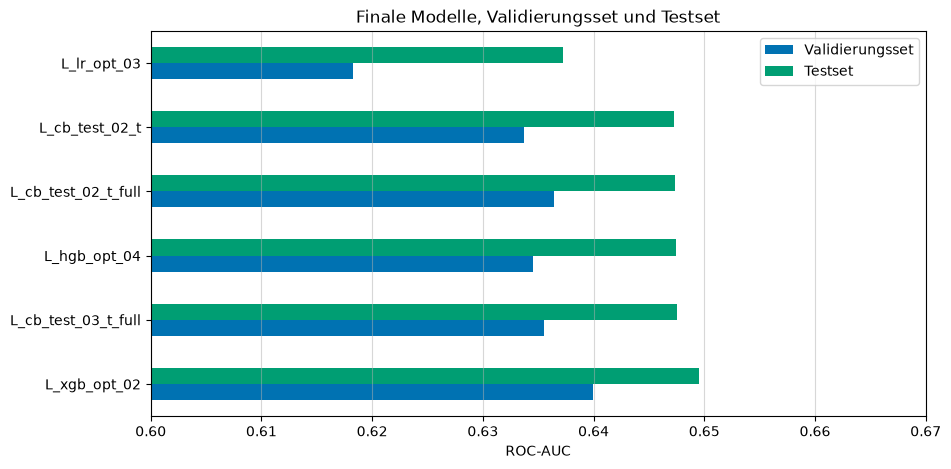

In [531]:
fig, ax = plt.subplots(figsize=(10, 5))

(
    df_results
    .set_index("model_idx")[["auc_val", "auc_test"]]
    .rename(columns={
        "auc_val": "Validierungsset", 
        "auc_test": "Testset"
    })
    .plot.barh(
        ax=ax
    )
)

ax.set_xlim(0.60, 0.67)
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("")
ax.set_title("Finale Modelle, Validierungsset und Testset")
ax.legend()
ax.grid(axis="x", alpha=0.5)

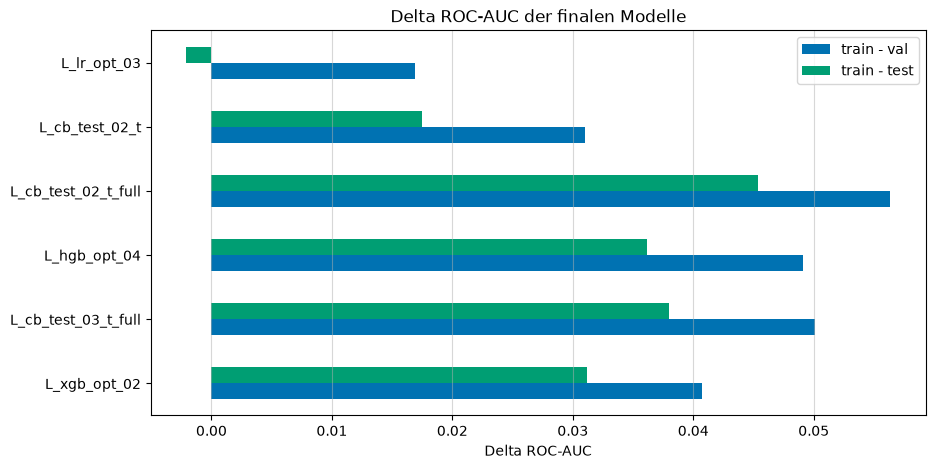

In [532]:
fig, ax = plt.subplots(figsize=(10, 5))

(
    df_results
    .set_index("model_idx")[["delta_auc_train_val", "delta_auc_train_test"]]
    .rename(columns={
        "delta_auc_train_val": "train - val", 
        "delta_auc_train_test": "train - test"
    })
    .plot.barh(
        ax=ax
    )
)

ax.set_xlabel("Delta ROC-AUC")
ax.set_ylabel("")
ax.set_title("Delta ROC-AUC der finalen Modelle")
ax.legend()
ax.grid(axis="x", alpha=0.5)

## Ergebnis Überprüfung an Notebook 23

In [533]:
referenz = {
    "L_xgb_opt_02": {"auc_test": 0.649495, "best_iter": 139},
    "L_hgb_opt_04": {"auc_test": 0.647474, "best_iter": 365},
    "L_cb_test_02_t": {"auc_test": 0.647273, "best_iter": 518},
    "L_cb_test_02_t_full": {"auc_test": 0.647385, "best_iter": 558},
    "L_cb_test_03_t_full": {"auc_test": 0.647561, "best_iter": 789},
    "L_lr_opt_03": {"auc_test": 0.637237, "best_iter": 500}
}

In [534]:
check = []

for name, ref in referenz.items():
    row = df_results.loc[df_results["model_idx"] == name].iloc[0]
    check.append({
         "model_idx": name,
        "auc_test_23": ref["auc_test"],
        "auc_test_neu": row["auc_test"],
        "diff_auc": row["auc_test"] - ref["auc_test"],
        "best_iter_23": ref["best_iter"],
        "best_iter_neu": row["best_iter"],
        "identisch": abs(row["auc_test"] - ref["auc_test"]) < 1e-4 and row["best_iter"] == ref["best_iter"]
    })

pd.DataFrame(check)

,model_idx,auc_test_23,auc_test_neu,diff_auc,best_iter_23,best_iter_neu,identisch
0,L_xgb_opt_02,0.649495,0.649495,-4.720969e-07,139,139,True
1,L_hgb_opt_04,0.647474,0.647474,-4.585453e-07,365,365,True
2,L_cb_test_02_t,0.647273,0.647273,1.855940e-07,518,518,True
3,L_cb_test_02_t_full,0.647385,0.647385,-4.064509e-07,558,558,True
4,L_cb_test_03_t_full,0.647561,0.647561,-2.630702e-07,789,789,True
5,L_lr_opt_03,0.637237,0.637237,4.502403e-07,500,500,True


## Predictions

In [535]:
Pred_L_xgb_opt_02 = L_xgb_opt_02.predict_proba(x_test)[:, 1]
Pred_L_hgb_opt_04 = L_hgb_opt_04.predict_proba(x_test)[:, 1]
Pred_L_cb_test_02_t = L_cb_test_02_t.predict_proba(x_test)[:, 1]
Pred_L_cb_test_02_t_full = L_cb_test_02_t_full.predict_proba(x_test)[:, 1]
Pred_L_cb_test_03_t_full = L_cb_test_03_t_full.predict_proba(x_test)[:, 1]
Pred_L_lr_opt_03 = L_lr_opt_03.predict_proba(x_test)[:, 1]

preds_test = pd.DataFrame({
    "Pred_L_xgb_opt_02": L_xgb_opt_02.predict_proba(x_test)[:, 1],
    "Pred_L_hgb_opt_04": L_hgb_opt_04.predict_proba(x_test)[:, 1],
    "Pred_L_cb_test_02_t": L_cb_test_02_t.predict_proba(x_test)[:, 1],
    "Pred_L_cb_test_02_t_full": L_cb_test_02_t_full.predict_proba(x_test)[:, 1],
    "Pred_L_cb_test_03_t_full": L_cb_test_03_t_full.predict_proba(x_test)[:, 1],
    "Pred_L_lr_opt_03": L_lr_opt_03.predict_proba(x_test)[:, 1]
}, index=x_test.index)

## Modelle Korrelation

In [536]:
pred_korr = preds_test.corr(method="spearman").round(3)
pred_korr

,Pred_L_xgb_opt_02,Pred_L_hgb_opt_04,Pred_L_cb_test_02_t,Pred_L_cb_test_02_t_full,Pred_L_cb_test_03_t_full,Pred_L_lr_opt_03
Pred_L_xgb_opt_02,1.000,0.958,0.945,0.951,0.943,0.877
Pred_L_hgb_opt_04,0.958,1.000,0.952,0.958,0.948,0.898
Pred_L_cb_test_02_t,0.945,0.952,1.000,0.965,0.958,0.897
Pred_L_cb_test_02_t_full,0.951,0.958,0.965,1.000,0.956,0.911
Pred_L_cb_test_03_t_full,0.943,0.948,0.958,0.956,1.000,0.884
Pred_L_lr_opt_03,0.877,0.898,0.897,0.911,0.884,1.000


Text(0.5, 1.0, 'Korrelationen der Predictions (Testset)')

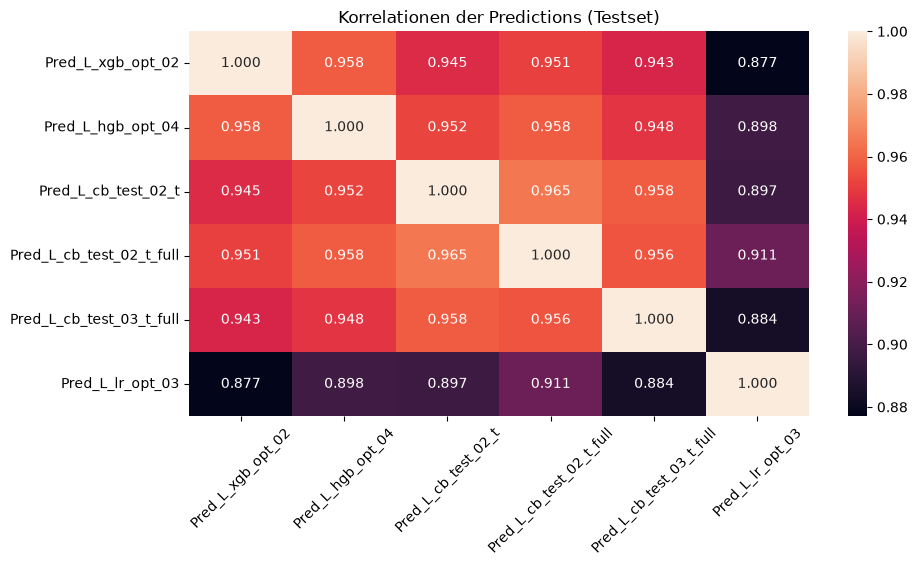

In [537]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    pred_korr,
    ax=ax,
    annot=True,
    fmt=".3f"
)
ax.tick_params(axis="x", rotation=45)
ax.set_title("Korrelationen der Predictions (Testset)")

## Notizen
- Ich versuche hier die Modelle nochmal standalone trainierbar zu machen und die Modelle etwas mehr straightforward zu gestalten. Pipelines etc wo es geht um möglichst wenig händische Vorarbeit zu leisten
- Ich hole die Parameter aus der study selber, im get all params ist scheinbar gerundet, den punkt muss ich eventuell noch in den vorangegangenen notebooks ko´rrigieren, oder ein notebook, das einzig und allein optuna studys anschaut
- Ich passe eval_model an, dann kann ich sowohl auc_val als auch auc_test absehen.
- bei hgb hatte ich x_train_hgb[feat_no_cols] verwendet, was wahrscheinlich eine andere struktur bekommt, wenn ein column transformer splaten droppt. hgb arbeitet durch max_features mit Ziehungen, die anhand des random states eventuell anders abfolgen würden, bei andere struktur.
- Ich benutze jetzt doch wieder etwas pipeline statt wie in der VL mak_pipeline, um die abteile besser callen zu können
- ICh checke nochmal gegen ob die ergebnisse hier denen aus 23 entsprechen